# div26 Systematic Analysis

Systematically identifies which combinations of critical-volume rule (VCV),
growth regulatory dynamic, and angle distributions push simulated *mud* mutant
lineages toward the experimental mudmut phenotype.

This notebook is parallel to `mudmut_systematic_analysis.ipynb` and uses the
`bioparams_div26_sweep` data (σ=26° division distribution, DIV mean variation
μ=0 vs μ=11, apical-axis rotation variation for mudmut only).

**Key differences from the old notebook:**
- WT conditions have no APICAL variation → APICAL sanity check removed
- WT now run at both VCV=0 (sim7x) and VCV=1 (sim6x) → both shown in Section 1
- 2 DIV distributions (D0S26, D11S26) instead of 5
- 6 mudmut conditions in a 2×3 grid: 2 DIV means × 3 APICAL distributions
- Section 4: 4a (DIV mean effect), 4b (APICAL σ effect), 4c (APICAL μ effect), 4d (full grid)

**Notebook structure**
- Section 0 — Setup: load data, define references and helpers
- Section 1 — DIV distribution filter (WT sims, VCV=0 and VCV=1)
- Section 1b — NB roundness filter (mudmut VCV=1 sims)
- Section 2+3 — Regulatory dynamics × VCV (mudmut)
- Section 4 — Angle distribution effects (4a–4d)
- Section 5 — Synthesis

**Chart convention** (Sections 2+3 onward):
Y-axis = log₁₀(value / WT mean). Dotted line at 0 = WT mean.
Solid line = mudmut mean. Shaded band = mudmut ±1 SD.
Section 1 uses WT ±1 SD as the acceptance band instead.

---
## Section 0 — Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [2]:
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'pyproject.toml').exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('Could not find repo root (no pyproject.toml)')
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / 'src'))
from npa.sim_viz import render_geo, load_sim_npz

SIM_METRICS_PATH = REPO_ROOT / 'data/sim/processed_sweep/sim_metrics_last.csv'
SIM_RUN_IDX_PATH = REPO_ROOT / 'data/sim/processed_sweep/sim_run_index.csv'
EXP_SUMMARY_PATH = REPO_ROOT / 'data/exp/processed/exp_summary.csv'
FIGURES_DIR      = REPO_ROOT / 'data/sim/processed_sweep/figures/analysis'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sim = pd.read_csv(SIM_METRICS_PATH)
sim['run_id'] = sim['run_id'].astype(str).str.zfill(4)

run_idx = pd.read_csv(SIM_RUN_IDX_PATH, dtype=str)
run_idx['npz_row'] = run_idx['npz_row'].astype(int)

exp = pd.read_csv(EXP_SUMMARY_PATH)

runs_per = sim.groupby(['condition', 'sim_id']).size().unique().tolist()
print(f'sim_metrics : {len(sim)} rows, {sim["condition"].nunique()} conditions, '
      f'{runs_per} runs per (condition, sim_id)')
print(f'run_index   : {len(run_idx)} rows')
print(f'exp_summary : {len(exp)} rows — genotypes: {list(exp["genotype"])}')
print(f'repo root   : {REPO_ROOT}')

sim_metrics : 4000 rows, 8 conditions, [50] runs per (condition, sim_id)
run_index   : 4000 rows
exp_summary : 3 rows — genotypes: ['mudmut', 'nanobody', 'wt']
repo root   : /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis


In [3]:
METRICS = ['lin_area_vox', 'n_pros', 'n_dpn', 'dpn_area_vox', 'avg_dpn_area_vox']
TOP3    = ['lin_area_vox', 'n_pros', 'n_dpn']

METRIC_LABELS = {
    'lin_area_vox':     'Lineage area (vox)',
    'n_pros':           'Pros count',
    'n_dpn':            'NB count',
    'dpn_area_vox':     'Total NB area (vox)',
    'avg_dpn_area_vox': 'Avg NB area (vox/cell)',
}
METRIC_DIRECTION = {
    'lin_area_vox':     'below WT',
    'n_pros':           'below WT',
    'n_dpn':            'above WT',
    'dpn_area_vox':     'below WT',
    'avg_dpn_area_vox': 'below WT',
}

wt_row = exp[exp['genotype'] == 'wt'].iloc[0]
mm_row = exp[exp['genotype'] == 'mudmut'].iloc[0]

wt_ref = {m: (float(wt_row[f'{m}_mean']), float(wt_row[f'{m}_std'])) for m in METRICS}
mm_ref = {m: (float(mm_row[f'{m}_mean']), float(mm_row[f'{m}_std'])) for m in METRICS}

print(f'  {"Metric":<22} {"WT mean":>10} {"WT std":>9} {"MM mean":>10} {"MM std":>9} {"log10(MM/WT)":>13} {"Target":>10}')
print('  ' + '-' * 88)
for m in METRICS:
    wm, ws = wt_ref[m]
    mm, ms = mm_ref[m]
    lfc = np.log10(mm / wm)
    flag = ' ★' if m in TOP3 else ''
    print(f'  {m:<22} {wm:>10.2f} {ws:>9.2f} {mm:>10.2f} {ms:>9.2f} {lfc:>13.3f} {METRIC_DIRECTION[m]:>10}{flag}')

  Metric                    WT mean    WT std    MM mean    MM std  log10(MM/WT)     Target
  ----------------------------------------------------------------------------------------
  lin_area_vox              5568.45   1397.85    4074.92   1102.36        -0.136   below WT ★
  n_pros                      44.93     21.68      36.93     20.46        -0.085   below WT ★
  n_dpn                        1.00      0.00       1.80      0.86         0.254   above WT ★
  dpn_area_vox               577.05    473.84     320.14    257.46        -0.256   below WT
  avg_dpn_area_vox           577.05    473.84     217.87    217.30        -0.423   below WT


In [4]:
# ── WT conditions (2): DIV mean varies, APICAL fixed at N(0,0) ───────────────
WT_CONDITIONS = [
    {'div_label': 'D0S26',  'condition': 'wt_divMean0Stdev26',  'div_mean': 0,  'div_stdev': 26},
    {'div_label': 'D11S26', 'condition': 'wt_divMean11Stdev26', 'div_mean': 11, 'div_stdev': 26},
]
wt_cond_df = pd.DataFrame(WT_CONDITIONS).set_index('div_label')

# DIV label → WT condition name (used in Section 1)
WT_DIV_GROUPS = {row['div_label']: row['condition'] for row in WT_CONDITIONS}

# ── Mudmut conditions (6): 2×3 grid (DIV mean × APICAL distribution) ─────────
MM_CONDITIONS = [
    {'tag': 'D0S26_R0S0',   'condition': 'mudmut_divMean0Stdev26_rotMean0Stdev0',   'div_mean': 0,  'div_stdev': 26, 'rot_mean': 0,  'rot_stdev': 0},
    {'tag': 'D0S26_R0S30',  'condition': 'mudmut_divMean0Stdev26_rotMean0Stdev30',  'div_mean': 0,  'div_stdev': 26, 'rot_mean': 0,  'rot_stdev': 30},
    {'tag': 'D0S26_R11S30', 'condition': 'mudmut_divMean0Stdev26_rotMean11Stdev30', 'div_mean': 0,  'div_stdev': 26, 'rot_mean': 11, 'rot_stdev': 30},
    {'tag': 'D11S26_R0S0',  'condition': 'mudmut_divMean11Stdev26_rotMean0Stdev0',  'div_mean': 11, 'div_stdev': 26, 'rot_mean': 0,  'rot_stdev': 0},
    {'tag': 'D11S26_R0S30', 'condition': 'mudmut_divMean11Stdev26_rotMean0Stdev30', 'div_mean': 11, 'div_stdev': 26, 'rot_mean': 0,  'rot_stdev': 30},
    {'tag': 'D11S26_R11S30','condition': 'mudmut_divMean11Stdev26_rotMean11Stdev30','div_mean': 11, 'div_stdev': 26, 'rot_mean': 11, 'rot_stdev': 30},
]
mm_cond_df = pd.DataFrame(MM_CONDITIONS).set_index('tag')
ALL_MM_TAGS = list(mm_cond_df.index)

# DIV label → mudmut tags for that DIV distribution (used for Section 1 → accepted_mm_tags)
MM_DIV_GROUPS = {
    'D0S26':  ['D0S26_R0S0',  'D0S26_R0S30',  'D0S26_R11S30'],
    'D11S26': ['D11S26_R0S0', 'D11S26_R0S30', 'D11S26_R11S30'],
}

# Sim-series IDs
WT_VCV1_IDS  = ['vcv1_noreg', 'vcv1_nb_abm', 'vcv1_vol_abm', 'vcv1_nb_pde', 'vcv1_vol_pde']
WT_VCV0_IDS  = ['vcv0_noreg', 'vcv0_nb_abm', 'vcv0_vol_abm', 'vcv0_nb_pde', 'vcv0_vol_pde']
MM_VCV1_IDS  = ['vcv1_noreg', 'vcv1_nb_abm', 'vcv1_vol_abm', 'vcv1_nb_pde', 'vcv1_vol_pde']
MM_VCV0_IDS  = ['vcv0_noreg', 'vcv0_nb_abm', 'vcv0_vol_abm', 'vcv0_nb_pde', 'vcv0_vol_pde']

# ── Availability and run-count check ─────────────────────────────────────────
expected_conds = set(wt_cond_df['condition']) | set(mm_cond_df['condition'])
present_conds  = set(sim['condition'].unique())
missing = expected_conds - present_conds
if missing:
    print(f'WARNING: {len(missing)} condition(s) missing from sim_metrics_last.csv:')
    for c in sorted(missing):
        print(f'  {c}')
else:
    print('All 8 conditions present. ✓')

counts = sim.groupby(['condition', 'sim_id']).size()
lo, hi = counts.min(), counts.max()
if lo != hi:
    print(f'WARNING: run counts vary ({lo}–{hi})')
    print(counts[counts < hi].reset_index(name='n_runs').to_string(index=False))
else:
    print(f'Consistent run count: {lo} runs per (condition, sim_id). ✓')

# ── Print condition tables ────────────────────────────────────────────────────
print()
print('WT conditions (APICAL fixed at N(0,0) for all):')
print(f'  {"Tag":<10} {"Condition":<40} {"DIV distribution"}')
print('  ' + '-' * 70)
for tag, row in wt_cond_df.iterrows():
    print(f'  {tag:<10} {row["condition"]:<40} N({row["div_mean"]},{row["div_stdev"]})')

print()
print('Mudmut conditions (2×3 grid: DIV mean × APICAL distribution):')
print(f'  {"Tag":<18} {"DIV":>12} {"APICAL":>15}')
print('  ' + '-' * 50)
for tag, row in mm_cond_df.iterrows():
    div_str   = f'N({row["div_mean"]},{row["div_stdev"]})'
    apical_str = f'N({row["rot_mean"]},{row["rot_stdev"]})'
    print(f'  {tag:<18} {div_str:>12} {apical_str:>15}')

All 8 conditions present. ✓
Consistent run count: 50 runs per (condition, sim_id). ✓

WT conditions (APICAL fixed at N(0,0) for all):
  Tag        Condition                                DIV distribution
  ----------------------------------------------------------------------
  D0S26      wt_divMean0Stdev26                       N(0,26)
  D11S26     wt_divMean11Stdev26                      N(11,26)

Mudmut conditions (2×3 grid: DIV mean × APICAL distribution):
  Tag                         DIV          APICAL
  --------------------------------------------------
  D0S26_R0S0              N(0,26)          N(0,0)
  D0S26_R0S30             N(0,26)         N(0,30)
  D0S26_R11S30            N(0,26)        N(11,30)
  D11S26_R0S0            N(11,26)          N(0,0)
  D11S26_R0S30           N(11,26)         N(0,30)
  D11S26_R11S30          N(11,26)        N(11,30)


In [5]:
REG_DYN_ORDER  = ['NONE', 'NB-ABM', 'VOL-ABM', 'NB-PDE', 'VOL-PDE']
REG_DYN_COLORS = {
    'NONE':    '#888888',
    'NB-ABM':  '#4e9ed4',
    'VOL-ABM': '#5ab454',
    'NB-PDE':  '#e87b39',
    'VOL-PDE': '#d84444',
}

_COND_PALETTE = [
    '#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628',
]
MM_COND_COLORS = {tag: _COND_PALETTE[i] for i, tag in enumerate(ALL_MM_TAGS)}


def fold_change_log(values, ref_mean):
    return np.log10(np.asarray(values, dtype=float) / ref_mean)


def draw_example_lineage(condition, sim_id, run_id=None, title='', ax=None):
    """
    Render the geo tensor for (condition, sim_id, run_id).
    If run_id is None, selects the run whose lin_area_vox is closest to the
    condition+sim_id mean (median-representative run).
    Works for both WT and mudmut conditions.
    """
    subset = sim[(sim['condition'] == condition) & (sim['sim_id'] == sim_id)]
    if subset.empty:
        raise ValueError(f'No rows for condition={condition}, sim_id={sim_id}')
    if run_id is None:
        mean_val = subset['lin_area_vox'].mean()
        run_id = str(subset.loc[
            (subset['lin_area_vox'] - mean_val).abs().idxmin(), 'run_id'
        ]).zfill(4)
    run_id = str(run_id).zfill(4)
    match = run_idx[
        (run_idx['condition'] == condition) &
        (run_idx['sim_id']    == sim_id) &
        (run_idx['run_id']    == run_id)
    ]
    if match.empty:
        raise ValueError(f'run_index has no entry for condition={condition}, '
                         f'sim_id={sim_id}, run_id={run_id}')
    npz_path = REPO_ROOT / match.iloc[0]['npz_path']
    row = int(match.iloc[0]['npz_row'])
    geo = load_sim_npz(npz_path, row)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    render_geo(geo, ax=ax, title=title or f'{condition} | {sim_id} | run {run_id}')
    ax.axis('off')
    return ax


def nb_circularity(geo_tensor, min_voxels=50):
    """
    Minimum 4π·area/perimeter² across NB connected components in geo_tensor.
    Components smaller than min_voxels are ignored as artifacts.
    Returns NaN if no qualifying components found.
    """
    from skimage.measure import label, regionprops
    nb_mask = (geo_tensor[..., 0] > 0).astype('uint8')
    labeled = label(nb_mask, connectivity=1)
    circularities = [
        (4 * np.pi * p.area) / (p.perimeter ** 2)
        for p in regionprops(labeled)
        if p.area >= min_voxels and p.perimeter > 0
    ]
    return float(np.min(circularities)) if circularities else float('nan')


def heterotypic_contact_fraction(geo):
    """
    Compute het_frac and norm_het_frac from a (H, W, 2) geo tensor.
    Channel 0 = NB (pop1). Channel 1 = non-NB (pop2 + pop3).
    Returns dict: het_frac, norm_het_frac, p_nb, p_nonnb, n_occupied.
    norm_het_frac = het_frac / (2 * p_nb * p_nonnb); NaN if only one type present.
    """
    nb    = geo[..., 0] > 0
    nonnb = geo[..., 1] > 0
    occ   = nb | nonnb

    n_occ = int(occ.sum())
    if n_occ == 0:
        return dict(het_frac=np.nan, norm_het_frac=np.nan,
                    p_nb=np.nan, p_nonnb=np.nan, n_occupied=0)

    p_nb_val    = float(nb[occ].mean())
    p_nonnb_val = float(nonnb[occ].mean())

    both_h = occ[:, :-1] & occ[:, 1:]
    het_h  = both_h & (nb[:, :-1] ^ nb[:, 1:])

    both_v = occ[:-1, :] & occ[1:, :]
    het_v  = both_v & (nb[:-1, :] ^ nb[1:, :])

    total = int(both_h.sum()) + int(both_v.sum())
    het   = int(het_h.sum())  + int(het_v.sum())

    if total == 0:
        return dict(het_frac=np.nan, norm_het_frac=np.nan,
                    p_nb=p_nb_val, p_nonnb=p_nonnb_val, n_occupied=n_occ)

    hf       = het / total
    expected = 2.0 * p_nb_val * p_nonnb_val
    norm_hf  = (hf / expected) if expected > 0 else np.nan

    return dict(het_frac=hf, norm_het_frac=norm_hf,
                p_nb=p_nb_val, p_nonnb=p_nonnb_val, n_occupied=n_occ)


---
## Section 1 — DIV Distribution Filter (WT Simulations)

**Question:** Which DIV distributions keep WT simulations within ±1 SD of the
experimental WT mean on the three primary metrics?

**Changes from old notebook:** no APICAL sanity check (WT conditions do not vary
APICAL). There are only 2 DIV distributions (D0S26, D11S26). Both VCV=0 (sim71–75,
hatched) and VCV=1 (sim61–65, solid) are shown on the same axes.

**Filter criterion:** a DIV distribution is eliminated if the median of any
(VCV, regulatory dynamic) box falls outside the WT ±1 SD band on any of the top 3
metrics (`lin_area_vox`, `n_pros`, `n_dpn`). The VCV dimension is informational;
if only one VCV mode passes, note it.

**Output:** `accepted_div_labels`, `accepted_mm_tags`, `accepted_mm_conditions`.

In [6]:
sim_wt = sim[sim['genotype'] == 'wt']

# ── WT simulation mean table ──────────────────────────────────────────────────
_col_w = 20
_hdr   = f'  {"Condition":<35}' + ''.join(
    f'{METRIC_LABELS[m] + (" ★" if m in TOP3 else ""):>{_col_w}}' for m in METRICS
)
print(_hdr)
print('  ' + '-' * (35 + _col_w * len(METRICS)))
for div_label in WT_DIV_GROUPS:
    wt_cond = WT_DIV_GROUPS[div_label]
    for vcv, sim_ids in [(0, WT_VCV0_IDS), (1, WT_VCV1_IDS)]:
        for reg_dyn in REG_DYN_ORDER:
            runs = sim_wt[
                (sim_wt['condition']          == wt_cond) &
                (sim_wt['sim_id'].isin(sim_ids)) &
                (sim_wt['regulatory_dynamic'] == reg_dyn)
            ]
            if runs.empty:
                continue
            label = f'{div_label} / VCV={vcv} / {reg_dyn}'
            print(f'  {label:<35}' + ''.join(f'{runs[m].mean():>{_col_w}.2f}' for m in METRICS))
    print()  # blank line between DIV groups


def wt_filter_chart(metric, figsize=(16, 5)):
    """
    Grouped box-and-whisker chart for Section 1.
    X-axis: 2 DIV distributions. Within each group: 10 boxes
    (5 regulatory dynamics × 2 VCV modes side by side).
    VCV=1: solid fill; VCV=0: hatched. Color = regulatory dynamic.
    Shaded band = WT ±1 SD acceptance region (symmetric in log space).
    """
    wt_mean, wt_std = wt_ref[metric]
    zero_std = (wt_std == 0)
    if zero_std:
        band_lo, band_hi = -0.05, 0.05
        band_label = 'WT ±1 SD (std=0; band is visual only)'
    else:
        band_hi = np.log10((wt_mean + wt_std) / wt_mean)
        band_lo = -band_hi
        band_label = 'WT ±1 SD (acceptance)'

    div_labels = list(WT_DIV_GROUPS.keys())
    n_boxes    = len(REG_DYN_ORDER) * 2  # 5 dynamics × 2 VCVs = 10
    box_w      = 0.055
    inner_step = 0.075
    group_step = 1.0
    offsets    = np.arange(n_boxes) * inner_step - (n_boxes - 1) * inner_step / 2

    fig, ax = plt.subplots(figsize=figsize)
    ax.axhspan(band_lo, band_hi, alpha=0.15, color='gray', zorder=0, label=band_label)
    ax.axhline(0, color='black', linestyle=':', linewidth=1.5, zorder=1, label='WT mean')

    for gi, div_label in enumerate(div_labels):
        wt_cond      = WT_DIV_GROUPS[div_label]
        group_center = gi * group_step
        bi = 0
        for reg_dyn in REG_DYN_ORDER:
            for vcv, sim_ids in [(0, WT_VCV0_IDS), (1, WT_VCV1_IDS)]:
                runs = sim_wt[
                    (sim_wt['condition']          == wt_cond) &
                    (sim_wt['sim_id'].isin(sim_ids)) &
                    (sim_wt['regulatory_dynamic'] == reg_dyn)
                ][metric]
                if runs.empty:
                    bi += 1
                    continue
                lfc = fold_change_log(runs, wt_mean)
                x   = group_center + offsets[bi]
                bp  = ax.boxplot(
                    [lfc],
                    positions=[x],
                    widths=box_w,
                    patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 1.2},
                    whiskerprops={'linewidth': 0.7},
                    capprops={'linewidth': 0.7},
                    flierprops={'marker': 'o', 'markersize': 1.5, 'linestyle': 'none'},
                    manage_ticks=False,
                    zorder=2,
                )
                bp['boxes'][0].set_facecolor(REG_DYN_COLORS[reg_dyn])
                bp['boxes'][0].set_alpha(0.8)
                if vcv == 0:
                    bp['boxes'][0].set_hatch('///')

                med       = float(np.median(lfc))
                upper_cap = bp['caps'][1].get_ydata()[0]
                lower_cap = bp['caps'][0].get_ydata()[0]
                if med >= 0:
                    ax.text(x, upper_cap + 0.005, f'{med:.2f}',
                            ha='center', va='bottom', fontsize=4.5, rotation=90)
                else:
                    ax.text(x, lower_cap - 0.005, f'{med:.2f}',
                            ha='center', va='top', fontsize=4.5, rotation=90)
                bi += 1

    ax.set_xticks([gi * group_step for gi in range(len(div_labels))])
    ax.set_xticklabels([f'DIV {d}' for d in div_labels], fontsize=10)
    flag = '  ★ filter metric' if metric in TOP3 else ''
    ax.set_title(f'{METRIC_LABELS[metric]} — WT sims vs experimental WT{flag}', fontsize=10)
    ax.set_ylabel('log₁₀(fold change from WT mean)')
    ax.grid(axis='y', alpha=0.3)

    legend_handles = [
        Patch(facecolor='gray', alpha=0.2, label=band_label),
        Line2D([0], [0], color='black', linestyle=':', linewidth=1.5, label='WT mean'),
    ] + [
        Patch(facecolor=REG_DYN_COLORS[d], alpha=0.8, label=f'{d} VCV=1')
        for d in REG_DYN_ORDER
    ] + [
        Patch(facecolor=REG_DYN_COLORS[d], alpha=0.8, hatch='///', label=f'{d} VCV=0')
        for d in REG_DYN_ORDER
    ]
    ax.legend(handles=legend_handles, fontsize=6.5, loc='upper right', ncol=2)
    plt.tight_layout()
    return fig

  Condition                          Lineage area (vox) ★        Pros count ★          NB count ★ Total NB area (vox)Avg NB area (vox/cell)
  ---------------------------------------------------------------------------------------------------------------------------------------
  D0S26 / VCV=0 / NONE                            5891.78               46.12                1.00              722.70              722.70
  D0S26 / VCV=0 / NB-ABM                          5891.78               46.12                1.00              722.70              722.70
  D0S26 / VCV=0 / VOL-ABM                         5451.62               42.50                1.00              694.88              694.88
  D0S26 / VCV=0 / NB-PDE                          5330.22               41.48                1.00              700.64              700.64
  D0S26 / VCV=0 / VOL-PDE                         5693.44               44.42                1.00              703.54              703.54
  D0S26 / VCV=1 / NONE          

=== Filter metrics — drive the accepted_div_labels decision ===


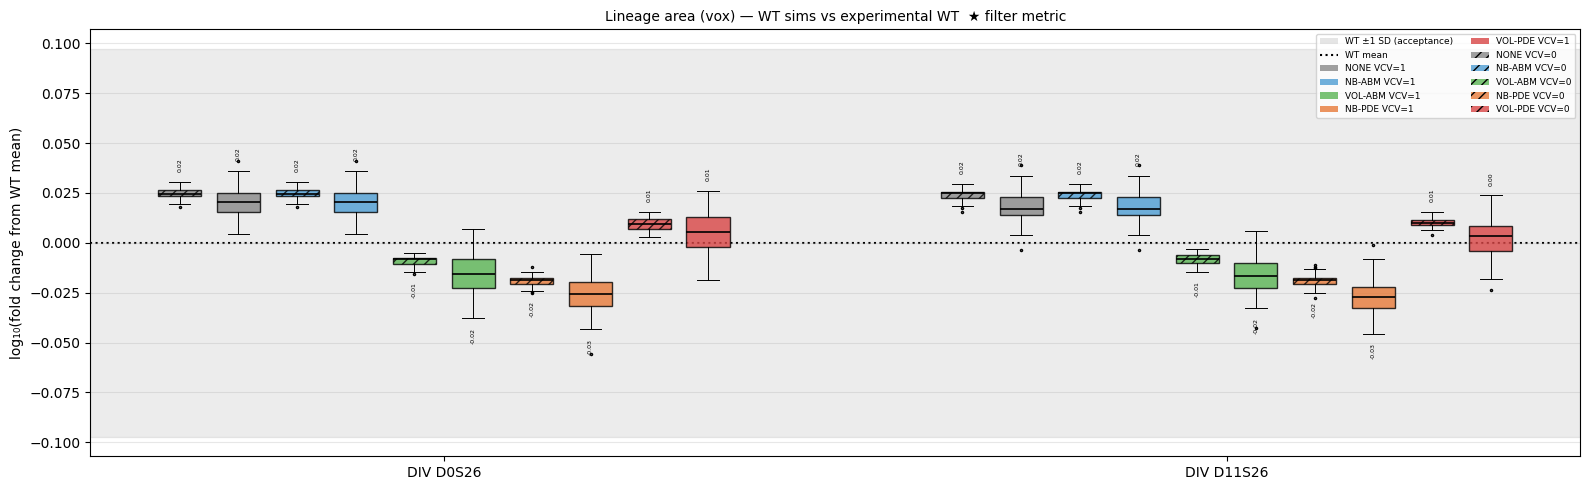

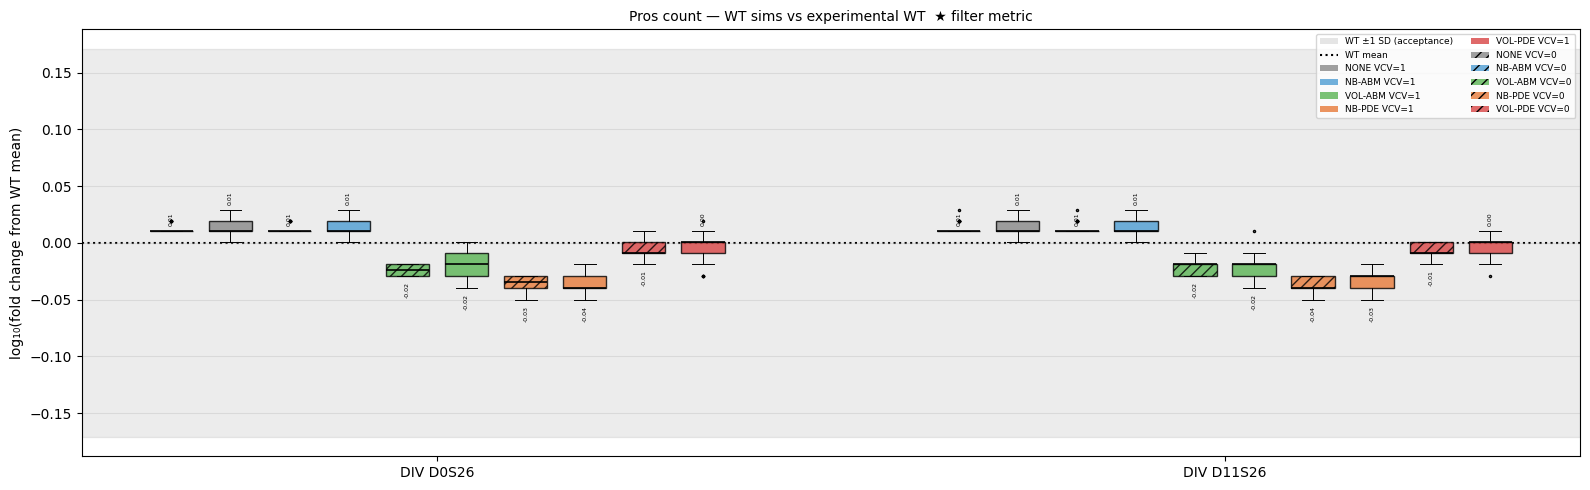

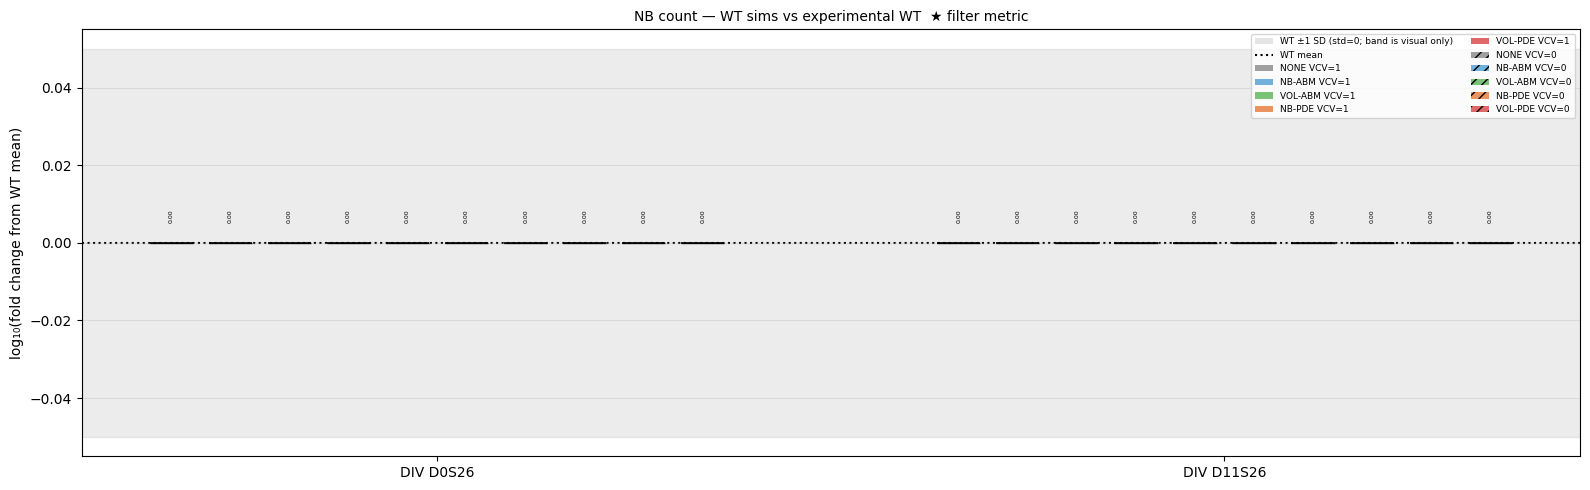

In [7]:
print('=== Filter metrics — drive the accepted_div_labels decision ===')
for metric in TOP3:
    fig = wt_filter_chart(metric)
    fig.savefig(FIGURES_DIR / f'sec1_wt_filter_{metric}.png', dpi=120, bbox_inches='tight')
    plt.show()

=== Reference metrics — shown for completeness, do not drive filter ===


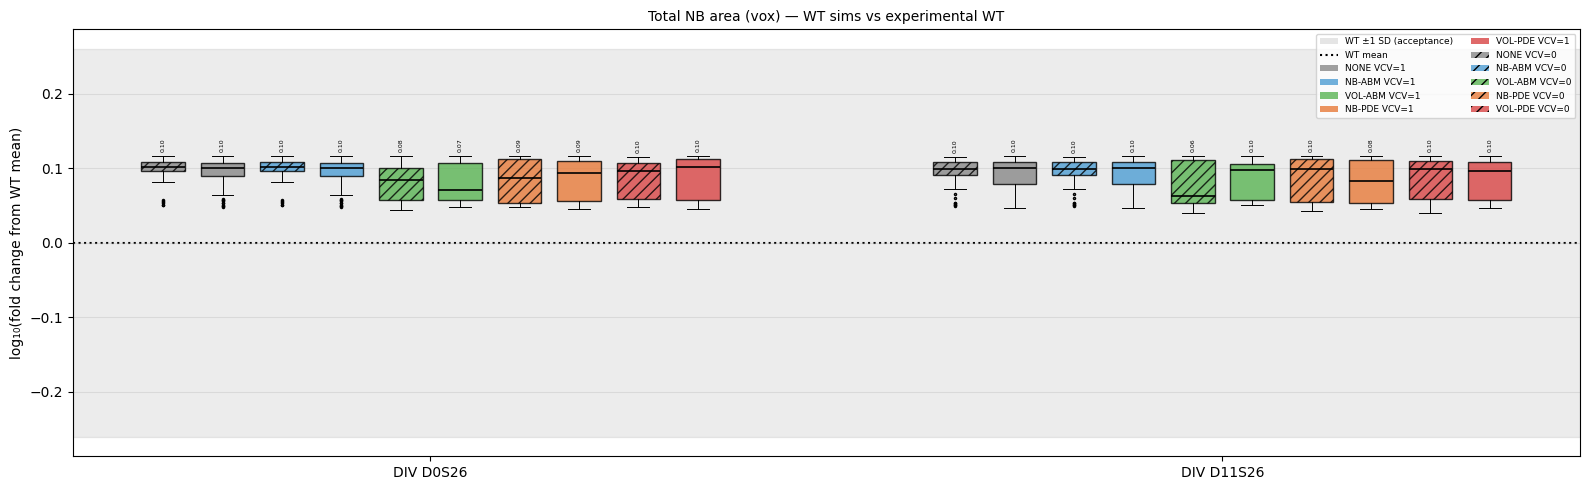

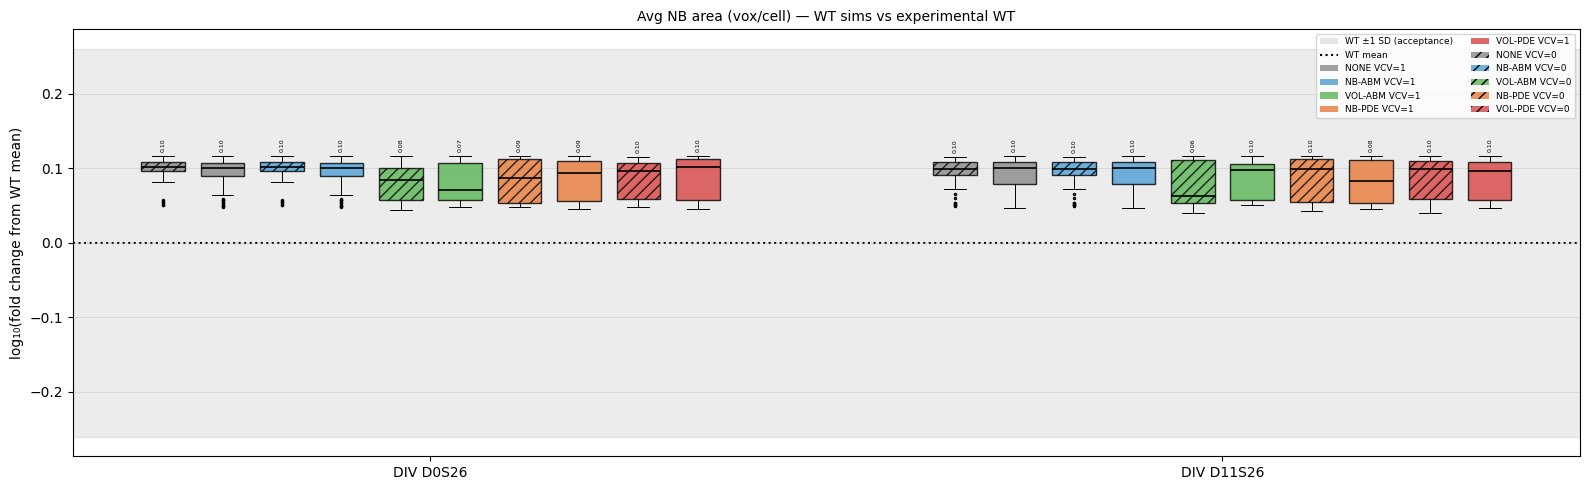

In [8]:
print('=== Reference metrics — shown for completeness, do not drive filter ===')
for metric in [m for m in METRICS if m not in TOP3]:
    fig = wt_filter_chart(metric)
    fig.savefig(FIGURES_DIR / f'sec1_wt_filter_{metric}.png', dpi=120, bbox_inches='tight')
    plt.show()

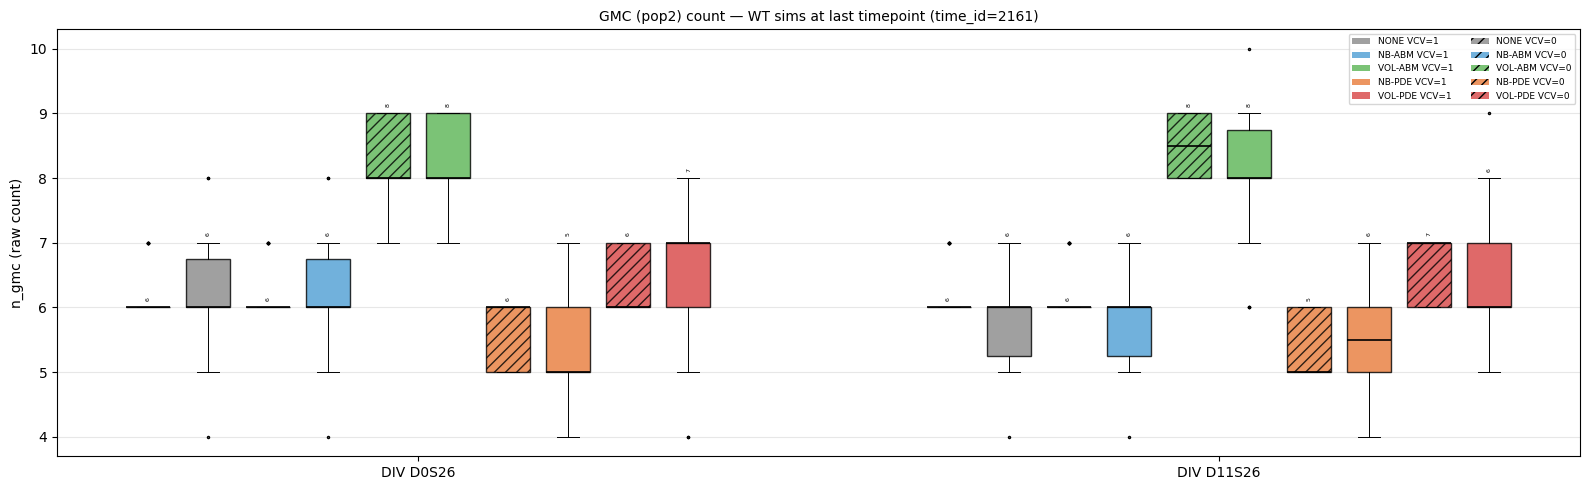

In [9]:
# GMC (pop2) count — WT sims at last timepoint
# regulatory_dynamic joined from sim (sim_metrics_last) via sim_id
_tp = pd.read_csv(REPO_ROOT / 'data/sim/processed_sweep/sim_timepoint_metrics.csv')
_tp_last = _tp[_tp['time_id'] == _tp['time_id'].max()].copy()

_sim_id_to_reg = (
    sim[['sim_id', 'regulatory_dynamic', 'critical_volume_mode']]
    .drop_duplicates('sim_id')
    .set_index('sim_id')
)
_tp_last = _tp_last.join(_sim_id_to_reg, on='sim_id')
_tp_wt = _tp_last[_tp_last['condition'].isin(list(WT_DIV_GROUPS.values()))]

div_labels = list(WT_DIV_GROUPS.keys())
n_boxes    = len(REG_DYN_ORDER) * 2
box_w      = 0.055
inner_step = 0.075
group_step = 1.0
offsets    = np.arange(n_boxes) * inner_step - (n_boxes - 1) * inner_step / 2

fig, ax = plt.subplots(figsize=(16, 5))

for gi, div_label in enumerate(div_labels):
    wt_cond      = WT_DIV_GROUPS[div_label]
    group_center = gi * group_step
    bi = 0
    for reg_dyn in REG_DYN_ORDER:
        for vcv, sim_ids in [(0, WT_VCV0_IDS), (1, WT_VCV1_IDS)]:
            runs = _tp_wt[
                (_tp_wt['condition']          == wt_cond) &
                (_tp_wt['sim_id'].isin(sim_ids)) &
                (_tp_wt['regulatory_dynamic'] == reg_dyn)
            ]['n_gmc']
            if runs.empty:
                bi += 1
                continue
            x  = group_center + offsets[bi]
            bp = ax.boxplot(
                [runs],
                positions=[x],
                widths=box_w,
                patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 1.2},
                whiskerprops={'linewidth': 0.7},
                capprops={'linewidth': 0.7},
                flierprops={'marker': 'o', 'markersize': 1.5, 'linestyle': 'none'},
                manage_ticks=False,
                zorder=2,
            )
            bp['boxes'][0].set_facecolor(REG_DYN_COLORS[reg_dyn])
            bp['boxes'][0].set_alpha(0.8)
            if vcv == 0:
                bp['boxes'][0].set_hatch('///')

            med       = float(np.median(runs))
            upper_cap = bp['caps'][1].get_ydata()[0]
            ax.text(x, upper_cap + 0.1, f'{med:.0f}',
                    ha='center', va='bottom', fontsize=4.5, rotation=90)
            bi += 1

ax.set_xticks([gi * group_step for gi in range(len(div_labels))])
ax.set_xticklabels([f'DIV {d}' for d in div_labels], fontsize=10)
ax.set_title('GMC (pop2) count — WT sims at last timepoint (time_id=2161)', fontsize=10)
ax.set_ylabel('n_gmc (raw count)')
ax.grid(axis='y', alpha=0.3)

legend_handles = [
    Patch(facecolor=REG_DYN_COLORS[d], alpha=0.8, label=f'{d} VCV=1')
    for d in REG_DYN_ORDER
] + [
    Patch(facecolor=REG_DYN_COLORS[d], alpha=0.8, hatch='///', label=f'{d} VCV=0')
    for d in REG_DYN_ORDER
]
ax.legend(handles=legend_handles, fontsize=6.5, loc='upper right', ncol=2)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'sec1_wt_gmc_count.png', dpi=120, bbox_inches='tight')
plt.show()


In [10]:
# ── ANALYST EDIT ─────────────────────────────────────────────────────────────
# Eliminate a DIV label if any (VCV, regulatory_dynamic) bar falls outside the
# WT ±1 SD band on any filter metric (lin_area_vox, n_pros, n_dpn).
# Valid keys: 'D0S26', 'D11S26'

eliminated_div_labels = []

# ── do not edit below ────────────────────────────────────────────────────────
accepted_div_labels      = [d for d in WT_DIV_GROUPS if d not in eliminated_div_labels]
accepted_mm_tags         = [t for d in accepted_div_labels for t in MM_DIV_GROUPS[d]]
accepted_mm_conditions   = mm_cond_df.loc[mm_cond_df.index.isin(accepted_mm_tags), 'condition'].tolist()

print(f'Eliminated  : {eliminated_div_labels or "none"}')
print(f'Accepted DIV labels  ({len(accepted_div_labels)}): {accepted_div_labels}')
print(f'Accepted mudmut tags ({len(accepted_mm_tags):2d}): {accepted_mm_tags}')
print(f'Accepted mudmut conditions ({len(accepted_mm_conditions):2d}): {accepted_mm_conditions}')

Eliminated  : none
Accepted DIV labels  (2): ['D0S26', 'D11S26']
Accepted mudmut tags ( 6): ['D0S26_R0S0', 'D0S26_R0S30', 'D0S26_R11S30', 'D11S26_R0S0', 'D11S26_R0S30', 'D11S26_R11S30']
Accepted mudmut conditions ( 6): ['mudmut_divMean0Stdev26_rotMean0Stdev0', 'mudmut_divMean0Stdev26_rotMean0Stdev30', 'mudmut_divMean0Stdev26_rotMean11Stdev30', 'mudmut_divMean11Stdev26_rotMean0Stdev0', 'mudmut_divMean11Stdev26_rotMean0Stdev30', 'mudmut_divMean11Stdev26_rotMean11Stdev30']


### Section 1 gut-check — Example WT lineages

Visual confirmation that WT lineages look reasonable for each accepted DIV distribution.

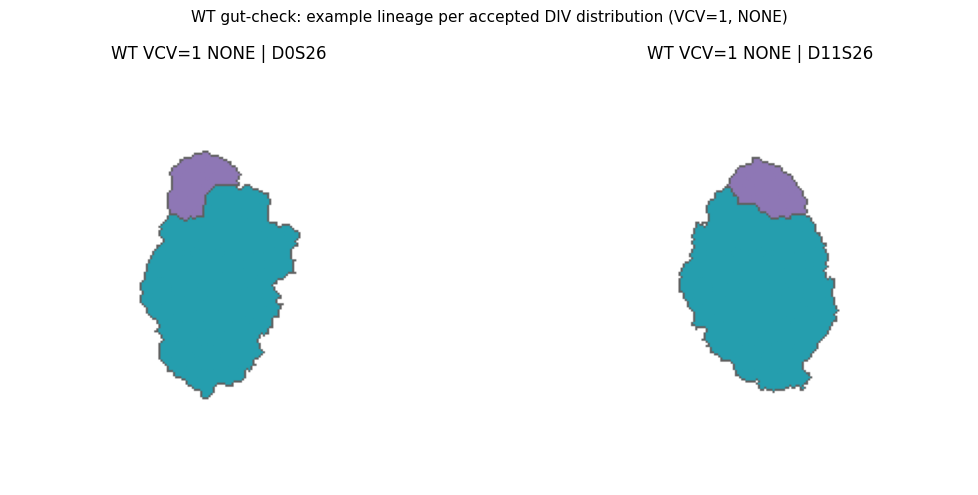

In [11]:
fig, axes = plt.subplots(1, len(accepted_div_labels), figsize=(5.5 * len(accepted_div_labels), 5))
if len(accepted_div_labels) == 1:
    axes = [axes]
for ax, div_label in zip(axes, accepted_div_labels):
    wt_cond = WT_DIV_GROUPS[div_label]
    draw_example_lineage(
        wt_cond, 'vcv1_noreg', ax=ax,
        title=f'WT VCV=1 NONE | {div_label}'
    )
plt.suptitle('WT gut-check: example lineage per accepted DIV distribution (VCV=1, NONE)', fontsize=11)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'sec1_wt_gutcheck.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 1b — NB Roundness Filter

**Question:** Do any accepted angle conditions produce systematically flat or
elongated neuroblasts in mudmut simulations?

**Motivation:** the new APICAL distributions (NORMAL(0,30) and NORMAL(11,30)) may
drive repeated divisions along similar apical axes, flattening the NB. This is
checked here using mudmut VCV=1 sims (sim41–45), since WT does not vary APICAL.

**Metric:** min NB circularity = 4π·area/perimeter² across all NB components.
Circularity = 1 for a perfect circle; near 0 for very elongated shapes.

**Output:** `accepted_mm_tags` and `accepted_mm_conditions` updated.

In [12]:
circ_mask = (
    run_idx['condition'].isin(accepted_mm_conditions) &
    run_idx['sim_id'].isin(MM_VCV1_IDS)
)
circ_run_idx = run_idx[circ_mask].copy()

n_total = len(circ_run_idx)
print(f'Computing NB circularity for {n_total} runs '
      f'({len(accepted_mm_conditions)} conditions × {len(MM_VCV1_IDS)} sim_ids × runs)...')

circ_records = []
for npz_path_str, group in circ_run_idx.groupby('npz_path'):
    npz_path = REPO_ROOT / npz_path_str
    with np.load(npz_path) as data:
        geo_all = data['geo']
    for _, row in group.iterrows():
        geo  = geo_all[int(row['npz_row'])]
        circ = nb_circularity(geo)
        circ_records.append({
            'condition':       row['condition'],
            'sim_id':          row['sim_id'],
            'run_id':          row['run_id'],
            'min_circularity': circ,
        })

circ_df = pd.DataFrame(circ_records)
cond_to_tag = {v: k for k, v in mm_cond_df['condition'].items()}
circ_df['tag'] = circ_df['condition'].map(cond_to_tag)

print(f'Done. Circularity range: [{circ_df["min_circularity"].min():.3f}, '
      f'{circ_df["min_circularity"].max():.3f}]')
print()
print(circ_df.groupby('tag')['min_circularity'].describe().round(3).to_string())

Computing NB circularity for 1500 runs (6 conditions × 5 sim_ids × runs)...
Done. Circularity range: [0.050, 0.777]

               count   mean    std    min    25%    50%    75%    max
tag                                                                  
D0S26_R0S0     250.0  0.378  0.191  0.057  0.204  0.394  0.491  0.777
D0S26_R0S30    250.0  0.385  0.183  0.067  0.237  0.380  0.508  0.760
D0S26_R11S30   250.0  0.399  0.179  0.076  0.270  0.383  0.527  0.760
D11S26_R0S0    250.0  0.380  0.196  0.050  0.198  0.400  0.518  0.770
D11S26_R0S30   250.0  0.398  0.187  0.066  0.222  0.412  0.533  0.770
D11S26_R11S30  250.0  0.402  0.186  0.068  0.241  0.418  0.540  0.770


/var/folders/2c/ggmnjcgs6zv79p4w57qtvtr80000gn/T/ipykernel_18236/194883551.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_tag, labels=tag_order, patch_artist=True,


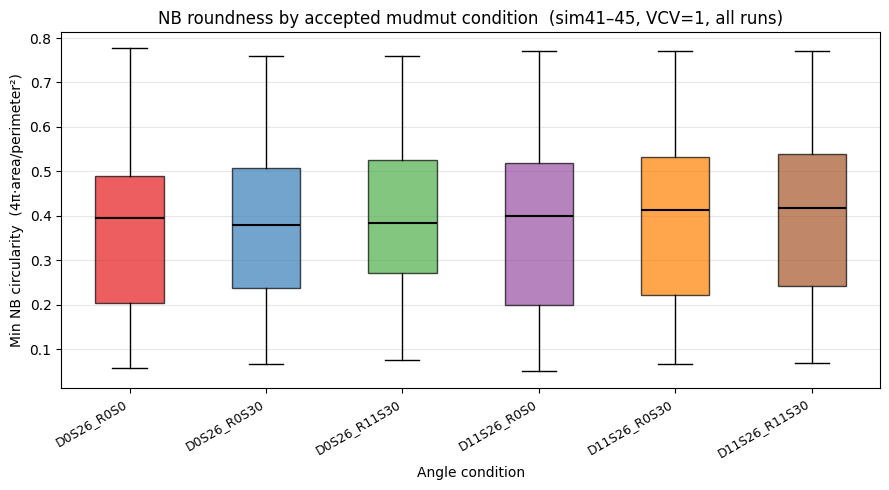

In [13]:
tag_order    = [t for t in accepted_mm_tags if t in circ_df['tag'].values]
data_by_tag  = [circ_df[circ_df['tag'] == t]['min_circularity'].dropna().values
                for t in tag_order]

fig, ax = plt.subplots(figsize=(max(8, len(tag_order) * 1.5), 5))
bp = ax.boxplot(data_by_tag, labels=tag_order, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 1.5})
for patch, tag in zip(bp['boxes'], tag_order):
    patch.set_facecolor(MM_COND_COLORS.get(tag, '#d0d0d0'))
    patch.set_alpha(0.7)

ax.set_xlabel('Angle condition')
ax.set_ylabel('Min NB circularity  (4π·area/perimeter²)')
ax.set_title('NB roundness by accepted mudmut condition  (sim41–45, VCV=1, all runs)')
ax.set_xticklabels(tag_order, rotation=30, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'sec1b_roundness_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()

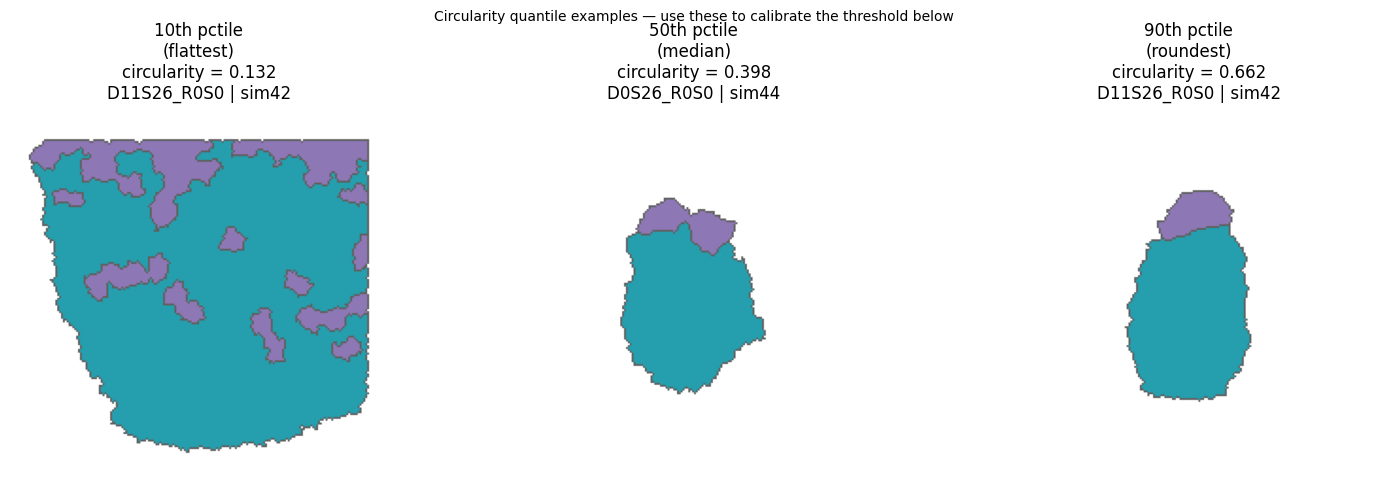

In [14]:
quantiles       = [0.10, 0.50, 0.90]
quantile_labels = ['10th pctile\n(flattest)', '50th pctile\n(median)', '90th pctile\n(roundest)']

all_sorted = (
    circ_df.dropna(subset=['min_circularity'])
           .sort_values('min_circularity')
           .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, q, qlabel in zip(axes, quantiles, quantile_labels):
    idx = int(q * (len(all_sorted) - 1))
    row = all_sorted.iloc[idx]
    draw_example_lineage(
        row['condition'], row['sim_id'], run_id=row['run_id'],
        title=f'{qlabel}\ncircularity = {row["min_circularity"]:.3f}\n{row["tag"]} | {row["sim_id"]}',
        ax=ax,
    )

plt.suptitle('Circularity quantile examples — use these to calibrate the threshold below',
             fontsize=10)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'sec1b_roundness_quantile_examples.png', dpi=120, bbox_inches='tight')
plt.show()

### Threshold calibration

Review the box plots and quantile examples above.

Set `circularity_threshold` in the cell below to the minimum acceptable **median**
min-circularity. Any accepted condition whose median falls below the threshold will
be excluded from Sections 2+3 onward.

- Set to `0` to keep all conditions (skip roundness filtering).
- A value around the 10th-percentile circularity shown above is a reasonable starting point.

In [15]:
# ── ANALYST EDIT ─────────────────────────────────────────────────────────────
circularity_threshold = 0.2

# ── do not edit below ────────────────────────────────────────────────────────
median_circ = circ_df.groupby('condition')['min_circularity'].median()

roundness_excluded_conditions = [
    c for c in accepted_mm_conditions
    if median_circ.get(c, 1.0) < circularity_threshold
]
accepted_mm_conditions = [c for c in accepted_mm_conditions
                           if c not in roundness_excluded_conditions]
accepted_mm_tags = [t for t in accepted_mm_tags
                    if mm_cond_df.loc[t, 'condition'] in accepted_mm_conditions]

if roundness_excluded_conditions:
    excl_tags = [cond_to_tag.get(c, c) for c in roundness_excluded_conditions]
    print(f'Roundness-excluded ({len(roundness_excluded_conditions)}): {excl_tags}')
else:
    print('All accepted conditions passed the roundness filter. ✓')
print(f'Remaining accepted conditions ({len(accepted_mm_conditions)}): {accepted_mm_tags}')

All accepted conditions passed the roundness filter. ✓
Remaining accepted conditions (6): ['D0S26_R0S0', 'D0S26_R0S30', 'D0S26_R11S30', 'D11S26_R0S0', 'D11S26_R0S30', 'D11S26_R11S30']


In [16]:
_HET_CSV = REPO_ROOT / 'data/sim/processed_sweep/het_contact_metrics.csv'

if _HET_CSV.exists():
    het_df = pd.read_csv(_HET_CSV)
    print(f'Loaded cached het_contact_metrics.csv ({len(het_df)} rows)')
else:
    _sim_id_meta = (
        sim[['sim_id', 'regulatory_dynamic', 'critical_volume_mode', 'genotype']]
        .drop_duplicates('sim_id')
        .set_index('sim_id')
    )

    het_records = []
    for npz_path_str, group in run_idx.groupby('npz_path'):
        npz_path = REPO_ROOT / npz_path_str
        with np.load(npz_path) as _data:
            _geo_all = _data['geo']
        for _, row in group.iterrows():
            geo_i  = _geo_all[int(row['npz_row'])]
            result = heterotypic_contact_fraction(geo_i)
            het_records.append({
                'condition': row['condition'],
                'sim_id':    row['sim_id'],
                'run_id':    row['run_id'],
                **result,
            })

    het_df = pd.DataFrame(het_records)
    het_df = het_df.join(_sim_id_meta, on='sim_id')

    _cond_to_tag = {v: k for k, v in mm_cond_df['condition'].items()}
    het_df['tag'] = het_df['condition'].map(_cond_to_tag)

    het_df.to_csv(_HET_CSV, index=False)
    print(f'Computed and saved het_contact_metrics.csv ({len(het_df)} rows)')

_summary = (
    het_df
    .groupby(['genotype', 'tag', 'critical_volume_mode'])['norm_het_frac']
    .agg(['mean', 'std'])
    .round(3)
)
print()
print(_summary.to_string())


Computed and saved het_contact_metrics.csv (4000 rows)

                                              mean    std
genotype tag           critical_volume_mode              
mudmut   D0S26_R0S0    0                     0.024  0.005
                       1                     0.048  0.023
         D0S26_R0S30   0                     0.027  0.007
                       1                     0.051  0.025
         D0S26_R11S30  0                     0.027  0.008
                       1                     0.053  0.025
         D11S26_R0S0   0                     0.024  0.006
                       1                     0.049  0.025
         D11S26_R0S30  0                     0.027  0.007
                       1                     0.052  0.026
         D11S26_R11S30 0                     0.028  0.008
                       1                     0.052  0.027


---
## Section: Heterotypic Contact Fraction

**Question:** Do rotation distributions affect how intermixed NB and non-NB
cells are, independently of lineage size and composition?

**Metric:** `norm_het_frac = het_frac / (2 × p_NB × p_nonNB)`.
Values > 1 = more mixed than random; < 1 = segregated; = 1 = random mixing.
Reference line at y = 1. WT mean shown as dotted reference lines (one per VCV).

Only accepted mudmut conditions are shown. WT conditions appear as reference
lines only (mean across all WT runs, one per VCV mode).


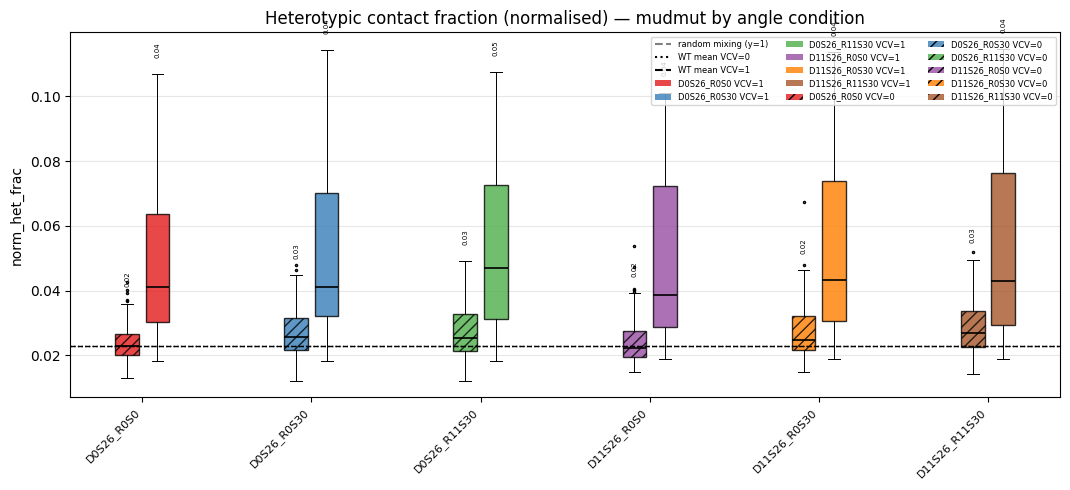

In [17]:
het_mm = het_df[het_df['tag'].isin(accepted_mm_tags)].copy()
het_wt = het_df[het_df['genotype'] == 'wt']

wt_refs = het_wt.groupby('critical_volume_mode')['norm_het_frac'].mean()

tags_ordered = sorted(
    accepted_mm_tags,
    key=lambda t: (mm_cond_df.loc[t, 'div_mean'],
                   mm_cond_df.loc[t, 'rot_stdev'],
                   mm_cond_df.loc[t, 'rot_mean']),
)

n_tags     = len(tags_ordered)
box_w      = 0.14
inner_step = 0.18
offsets    = np.array([-inner_step / 2, inner_step / 2])

fig, ax = plt.subplots(figsize=(max(10, n_tags * 1.8), 5))
#ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.2, zorder=1)

for vcv_idx, (vcv, sim_ids) in enumerate([(0, MM_VCV0_IDS), (1, MM_VCV1_IDS)]):
    for ti, tag in enumerate(tags_ordered):
        runs = het_mm[
            (het_mm['tag'] == tag) &
            (het_mm['critical_volume_mode'] == vcv)
        ]['norm_het_frac'].dropna()
        if runs.empty:
            continue
        x  = ti + offsets[vcv_idx]
        bp = ax.boxplot(
            [runs],
            positions=[x],
            widths=box_w,
            patch_artist=True,
            medianprops={'color': 'black', 'linewidth': 1.2},
            whiskerprops={'linewidth': 0.7},
            capprops={'linewidth': 0.7},
            flierprops={'marker': 'o', 'markersize': 1.5, 'linestyle': 'none'},
            manage_ticks=False,
            zorder=2,
        )
        bp['boxes'][0].set_facecolor(MM_COND_COLORS.get(tag, '#cccccc'))
        bp['boxes'][0].set_alpha(0.8)
        if vcv == 0:
            bp['boxes'][0].set_hatch('///')
        med       = float(np.median(runs))
        upper_cap = bp['caps'][1].get_ydata()[0]
        ax.text(x, upper_cap + 0.005, f'{med:.2f}',
                ha='center', va='bottom', fontsize=5, rotation=90)

for vcv, line_style in [(0, ':'), (1, '--')]:
    if vcv in wt_refs.index:
        ax.axhline(wt_refs[vcv], color='black', linestyle=line_style,
                   linewidth=1, label=f'WT mean VCV={vcv}')

ax.set_xticks(list(range(n_tags)))
ax.set_xticklabels(tags_ordered, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('norm_het_frac')
ax.set_title('Heterotypic contact fraction (normalised) — mudmut by angle condition')
ax.grid(axis='y', alpha=0.3)

legend_handles = [
    Line2D([0], [0], color='gray', linestyle='--', label='random mixing (y=1)'),
    Line2D([0], [0], color='black', linestyle=':', label='WT mean VCV=0'),
    Line2D([0], [0], color='black', linestyle='--', label='WT mean VCV=1'),
] + [
    Patch(facecolor=MM_COND_COLORS.get(t, '#ccc'), alpha=0.8, label=f'{t} VCV=1')
    for t in tags_ordered
] + [
    Patch(facecolor=MM_COND_COLORS.get(t, '#ccc'), alpha=0.8, hatch='///',
          label=f'{t} VCV=0')
    for t in tags_ordered
]
ax.legend(handles=legend_handles, fontsize=6, loc='upper right', ncol=3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'het_contact_by_condition.png', dpi=120, bbox_inches='tight')
plt.show()


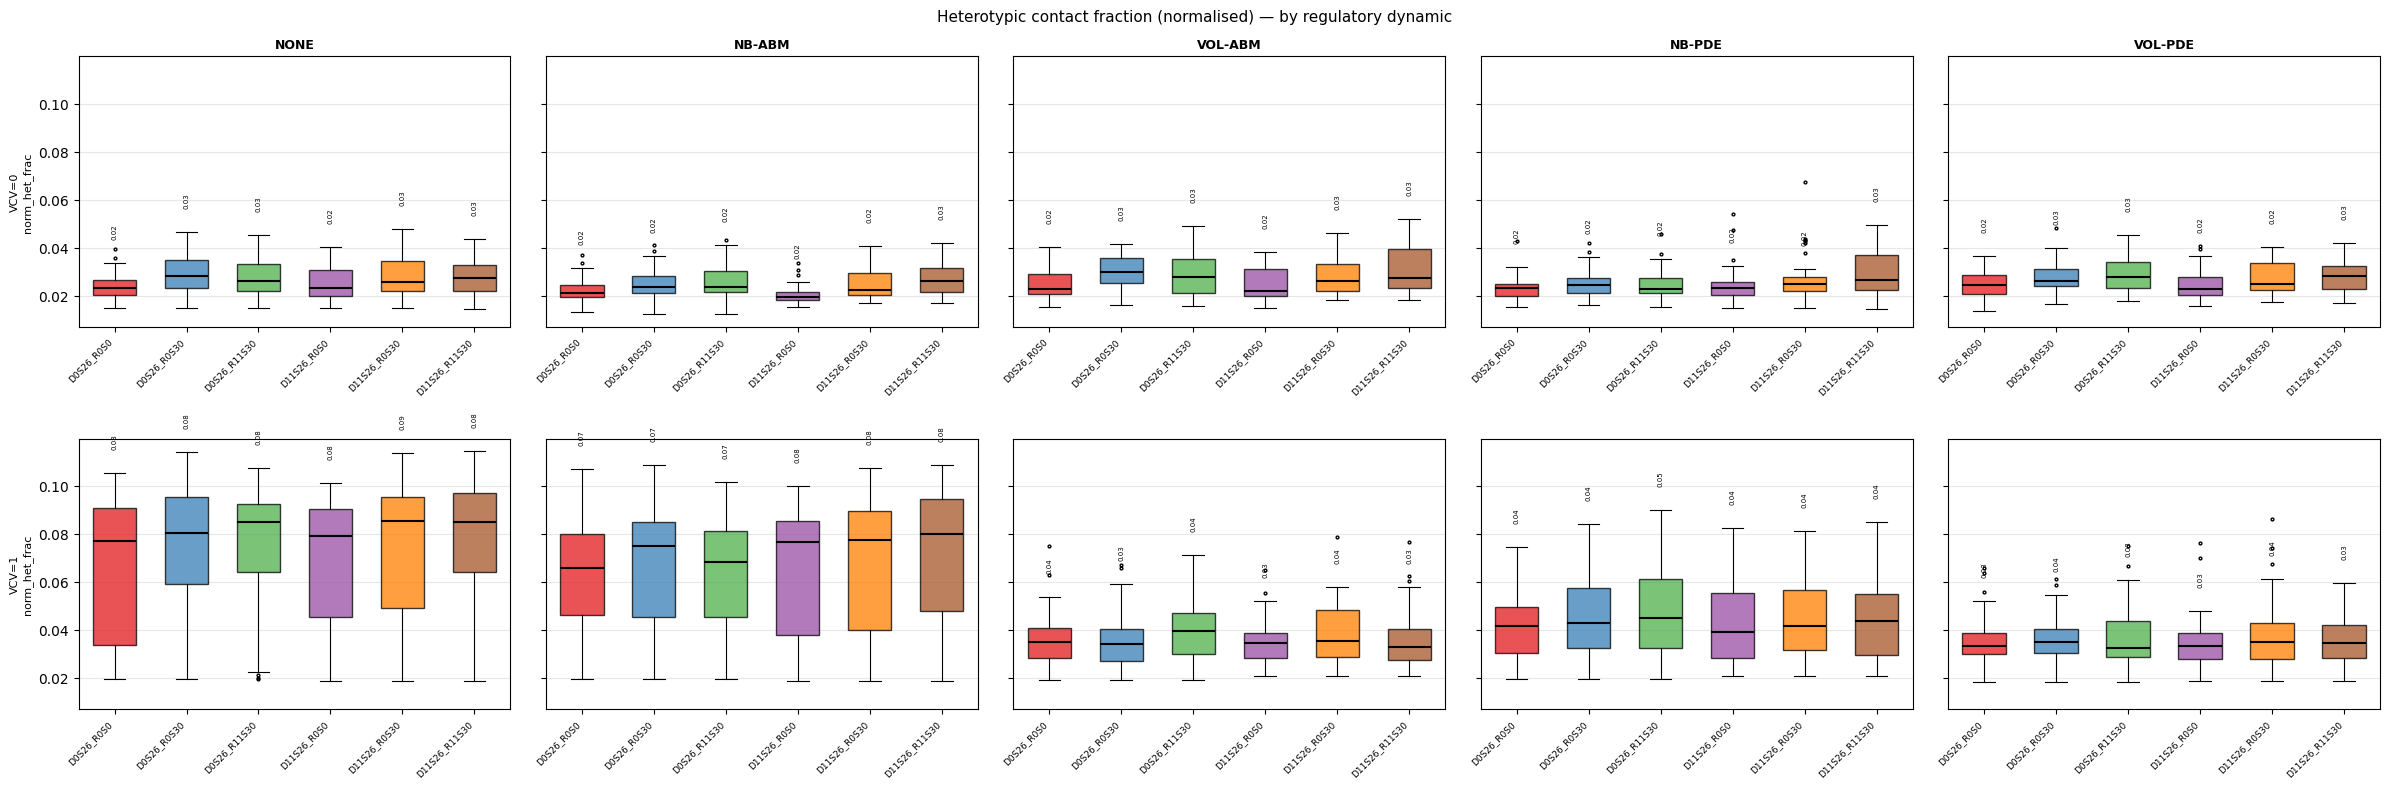

In [18]:
positions = list(range(len(tags_ordered)))

fig, axes = plt.subplots(2, len(REG_DYN_ORDER), figsize=(24, 8), sharey=True)

for ri, vcv in enumerate([0, 1]):
    for ci, reg_dyn in enumerate(REG_DYN_ORDER):
        ax = axes[ri, ci]
        #ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, zorder=1)

        panel = het_mm[
            (het_mm['critical_volume_mode'] == vcv) &
            (het_mm['regulatory_dynamic']   == reg_dyn)
        ]

        data_by_tag = []
        for tag in tags_ordered:
            runs = panel[panel['tag'] == tag]['norm_het_frac'].dropna()
            data_by_tag.append(runs if not runs.empty else np.array([np.nan]))

        if all(np.all(np.isnan(d)) for d in data_by_tag):
            ax.set_visible(False)
            continue

        bp = ax.boxplot(
            data_by_tag,
            positions=positions,
            widths=0.6,
            patch_artist=True,
            medianprops={'color': 'black', 'linewidth': 1.5},
            whiskerprops={'linewidth': 0.8},
            capprops={'linewidth': 0.8},
            flierprops={'marker': 'o', 'markersize': 2, 'linestyle': 'none'},
            zorder=2,
        )
        for patch, tag in zip(bp['boxes'], tags_ordered):
            patch.set_facecolor(MM_COND_COLORS.get(tag, '#cccccc'))
            patch.set_alpha(0.75)

        for xi, (tag, d) in enumerate(zip(tags_ordered, data_by_tag)):
            if np.all(np.isnan(d)):
                continue
            med       = float(np.nanmedian(d))
            upper_cap = bp['caps'][2 * xi + 1].get_ydata()[0]
            ax.text(xi, upper_cap + 0.01, f'{med:.2f}',
                    ha='center', va='bottom', fontsize=5, rotation=90)

        ax.set_xticks(positions)
        ax.set_xticklabels(tags_ordered, rotation=45, ha='right', fontsize=6.5)
        ax.grid(axis='y', alpha=0.3)

        if ri == 0:
            ax.set_title(reg_dyn, fontsize=9, fontweight='bold')
        if ci == 0:
            ax.set_ylabel(f'VCV={vcv}\nnorm_het_frac', fontsize=8)

fig.suptitle('Heterotypic contact fraction (normalised) — by regulatory dynamic',
             fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'het_contact_by_regdyn.png', dpi=120, bbox_inches='tight')
plt.show()


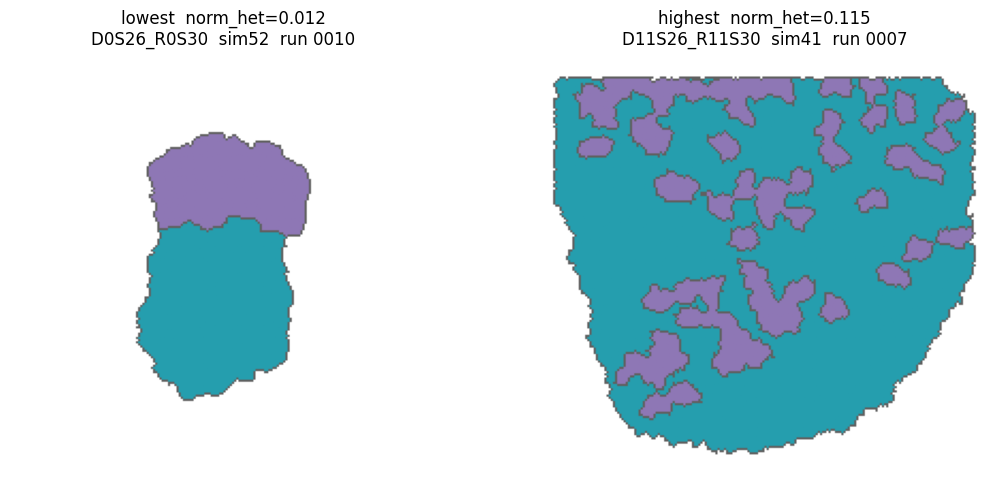

Lowest : D0S26_R0S30  sim52  run 0010  norm_het=0.012  het=0.006  p_nb=0.367
Highest: D11S26_R11S30  sim41  run 0007  norm_het=0.115  het=0.045  p_nb=0.272


In [19]:
# Compare lowest vs highest norm_het_frac lineages
_valid = het_mm.dropna(subset=['norm_het_frac'])
_lo   = _valid.loc[_valid['norm_het_frac'].idxmin()]
_hi   = _valid.loc[_valid['norm_het_frac'].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, row, label in [
    (axes[0], _lo, 'lowest'),
    (axes[1], _hi, 'highest'),
]:
    draw_example_lineage(
        row['condition'], row['sim_id'], run_id=row['run_id'],
        title=(
            f"{label}  norm_het={row['norm_het_frac']:.3f}\n"
            f"{row['tag']}  {row['sim_id']}  run {row['run_id']}"
        ),
        ax=ax,
    )
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'het_contact_gutcheck.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Lowest : {_lo["tag"]}  {_lo["sim_id"]}  run {_lo["run_id"]}  '
      f'norm_het={_lo["norm_het_frac"]:.3f}  het={_lo["het_frac"]:.3f}  '
      f'p_nb={_lo["p_nb"]:.3f}')
print(f'Highest: {_hi["tag"]}  {_hi["sim_id"]}  run {_hi["run_id"]}  '
      f'norm_het={_hi["norm_het_frac"]:.3f}  het={_hi["het_frac"]:.3f}  '
      f'p_nb={_hi["p_nb"]:.3f}')


Lowest  circularity run: D11S26_R0S0 | sim41 | run 0043  (0.050)
Highest circularity run: D0S26_R0S0 | sim42 | run 0014  (0.777)


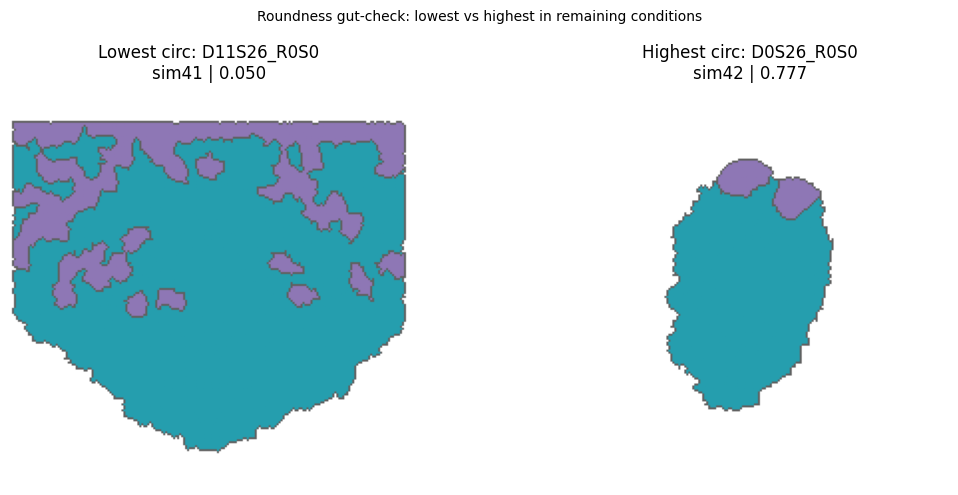

In [20]:
if accepted_mm_conditions:
    remaining_circ = circ_df[circ_df['condition'].isin(accepted_mm_conditions)]
    lo_run = remaining_circ.loc[remaining_circ['min_circularity'].idxmin()]
    hi_run = remaining_circ.loc[remaining_circ['min_circularity'].idxmax()]

    print(f'Lowest  circularity run: {lo_run["tag"]} | {lo_run["sim_id"]} | '
          f'run {lo_run["run_id"]}  ({lo_run["min_circularity"]:.3f})')
    print(f'Highest circularity run: {hi_run["tag"]} | {hi_run["sim_id"]} | '
          f'run {hi_run["run_id"]}  ({hi_run["min_circularity"]:.3f})')

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    draw_example_lineage(
        lo_run['condition'], lo_run['sim_id'], run_id=lo_run['run_id'],
        title=f'Lowest circ: {lo_run["tag"]}\n{lo_run["sim_id"]} | {lo_run["min_circularity"]:.3f}',
        ax=axes[0],
    )
    draw_example_lineage(
        hi_run['condition'], hi_run['sim_id'], run_id=hi_run['run_id'],
        title=f'Highest circ: {hi_run["tag"]}\n{hi_run["sim_id"]} | {hi_run["min_circularity"]:.3f}',
        ax=axes[1],
    )
    plt.suptitle('Roundness gut-check: lowest vs highest in remaining conditions', fontsize=10)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'sec1b_roundness_gutcheck.png', dpi=120, bbox_inches='tight')
    plt.show()

---
## Section 2+3 — Regulatory Dynamics × VCV (mudmut)

**Question:** Which (regulatory dynamic, VCV mode) combinations push simulated mudmut
below experimental WT? Which enter the experimental mudmut ±1 SD band?

**Data:** mudmut VCV=0 (sim51–55) and VCV=1 (sim41–45) across `accepted_mm_conditions`.

**Layout:** one figure per metric. 2-row × 5-column grid.
- Rows: VCV=0 (top) / VCV=1 (bottom)
- Columns: NONE | NB-ABM | VOL-ABM | NB-PDE | VOL-PDE
- X-axis: accepted mudmut angle conditions (up to 6)
- Y-axis: log₁₀(value / experimental WT mean)

In [21]:
sim_mm = sim[sim['genotype'] == 'mudmut']


def mudmut_facet_chart(metric, tags_subset=None, figsize=(24, 10)):
    """
    2-row × 5-column facet chart. Y-axis anchored at experimental WT mean.
    tags_subset: list of mudmut tags to show on x-axis (defaults to accepted_mm_tags).
    """
    if tags_subset is None:
        tags_subset = accepted_mm_tags
    subset_conditions = [mm_cond_df.loc[t, 'condition'] for t in tags_subset]

    wt_mean             = wt_ref[metric][0]
    mm_mean_val, mm_std = mm_ref[metric]
    mm_lfc              = np.log10(mm_mean_val / wt_mean)
    mm_half             = 0.05 if mm_std == 0 else np.log10(1 + mm_std / mm_mean_val)
    mm_lo, mm_hi        = mm_lfc - mm_half, mm_lfc + mm_half

    positions = list(range(len(tags_subset)))

    fig, axes = plt.subplots(2, len(REG_DYN_ORDER), figsize=figsize, sharey=True)

    for ri, vcv in enumerate([0, 1]):
        for ci, reg_dyn in enumerate(REG_DYN_ORDER):
            ax = axes[ri, ci]
            ax.axhspan(mm_lo, mm_hi, alpha=0.15, color='steelblue', zorder=0)
            ax.axhline(mm_lfc, color='steelblue', linewidth=1.2, zorder=1)
            ax.axhline(0, color='black', linestyle=':', linewidth=1, zorder=1)

            panel = sim_mm[
                (sim_mm['critical_volume_mode'] == vcv) &
                (sim_mm['regulatory_dynamic']   == reg_dyn) &
                (sim_mm['condition'].isin(subset_conditions))
            ]

            data_by_tag = []
            for tag in tags_subset:
                cond = mm_cond_df.loc[tag, 'condition']
                runs = panel[panel['condition'] == cond][metric]
                lfc  = fold_change_log(runs, wt_mean) if not runs.empty else np.array([np.nan])
                data_by_tag.append(lfc)

            if not data_by_tag:
                ax.set_visible(False)
                continue

            bp = ax.boxplot(
                data_by_tag,
                positions=positions,
                widths=0.6,
                patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 1.5},
                whiskerprops={'linewidth': 0.8},
                capprops={'linewidth': 0.8},
                flierprops={'marker': 'o', 'markersize': 2, 'linestyle': 'none'},
                zorder=2,
            )
            for patch, tag in zip(bp['boxes'], tags_subset):
                patch.set_facecolor(MM_COND_COLORS.get(tag, '#cccccc'))
                patch.set_alpha(0.75)

            for xi, (tag, d) in enumerate(zip(tags_subset, data_by_tag)):
                if np.all(np.isnan(d)):
                    continue
                med        = float(np.nanmedian(d))
                upper_cap  = bp['caps'][2 * xi + 1].get_ydata()[0]
                lower_cap  = bp['caps'][2 * xi].get_ydata()[0]
                if med >= 0:
                    ax.text(xi, upper_cap + 0.01, f'{med:.2f}',
                            ha='center', va='bottom', fontsize=5, rotation=90)
                else:
                    ax.text(xi, lower_cap - 0.01, f'{med:.2f}',
                            ha='center', va='top', fontsize=5, rotation=90)

            ax.set_xticks(positions)
            ax.set_xticklabels(tags_subset, rotation=45, ha='right', fontsize=6.5)
            ax.grid(axis='y', alpha=0.3)

            if ri == 0:
                ax.set_title(reg_dyn, fontsize=9, fontweight='bold')
            if ci == 0:
                ax.set_ylabel(f'VCV={vcv}\nlog₁₀(FC from WT mean)', fontsize=8)

    direction = '  [n_dpn: mudmut target is ABOVE WT line]' if metric == 'n_dpn' else ''
    fig.suptitle(
        f'{METRIC_LABELS[metric]} — mudmut sims vs experimental references{direction}',
        fontsize=11,
    )

    legend_handles = [
        Line2D([0], [0], color='black', linestyle=':', linewidth=1.2, label='exp WT mean (y=0)'),
        Line2D([0], [0], color='steelblue', linewidth=1.5, label='exp mudmut mean'),
        Patch(facecolor='steelblue', alpha=0.25, label='mudmut ±1 SD'),
    ] + [Patch(facecolor=MM_COND_COLORS.get(t, '#ccc'), label=t) for t in tags_subset]

    fig.tight_layout(rect=[0, 0.08, 1, 0.97])
    fig.legend(handles=legend_handles, fontsize=7, loc='lower center',
               ncol=len(legend_handles), bbox_to_anchor=(0.5, 0.0), framealpha=0.9)
    return fig

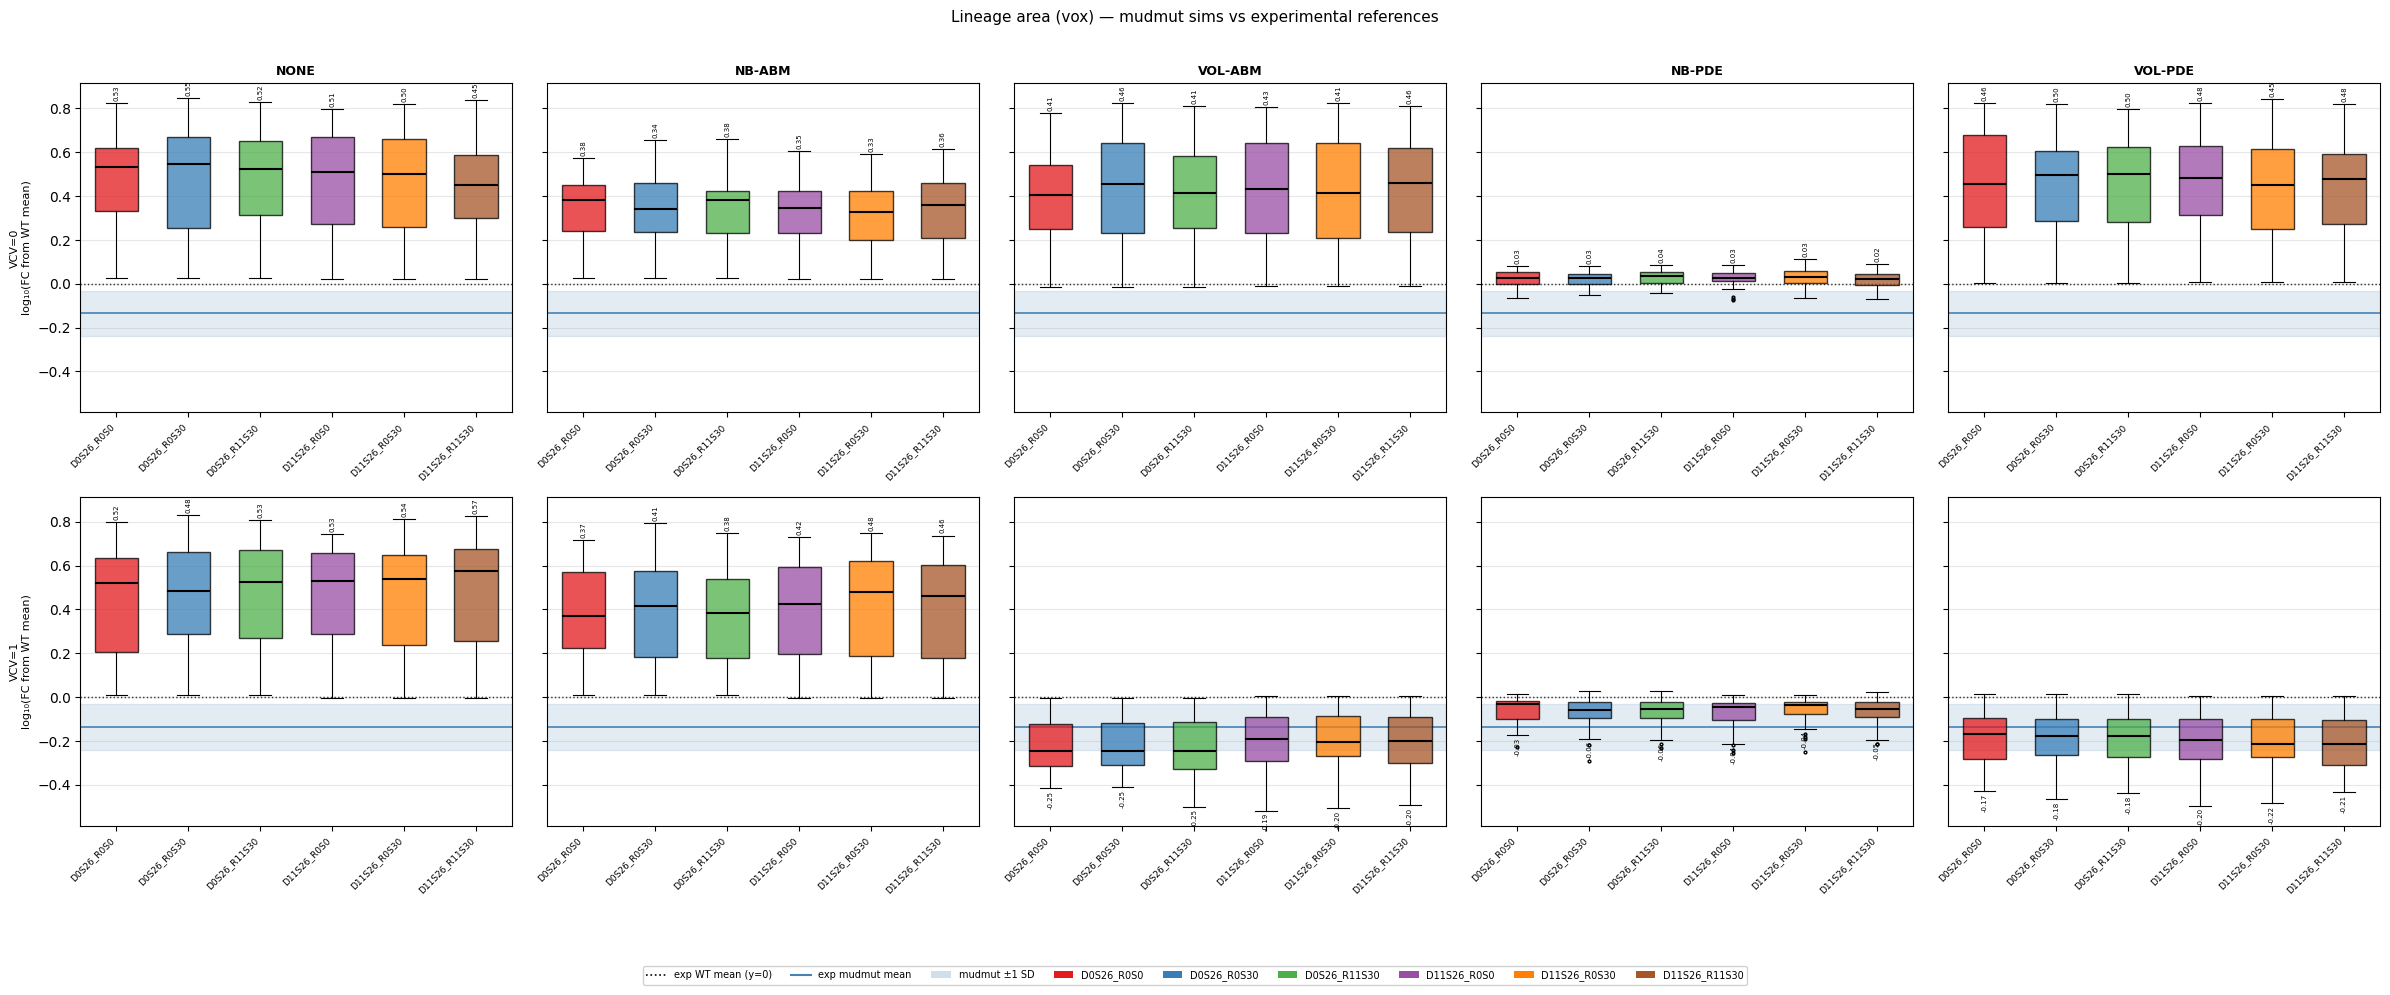

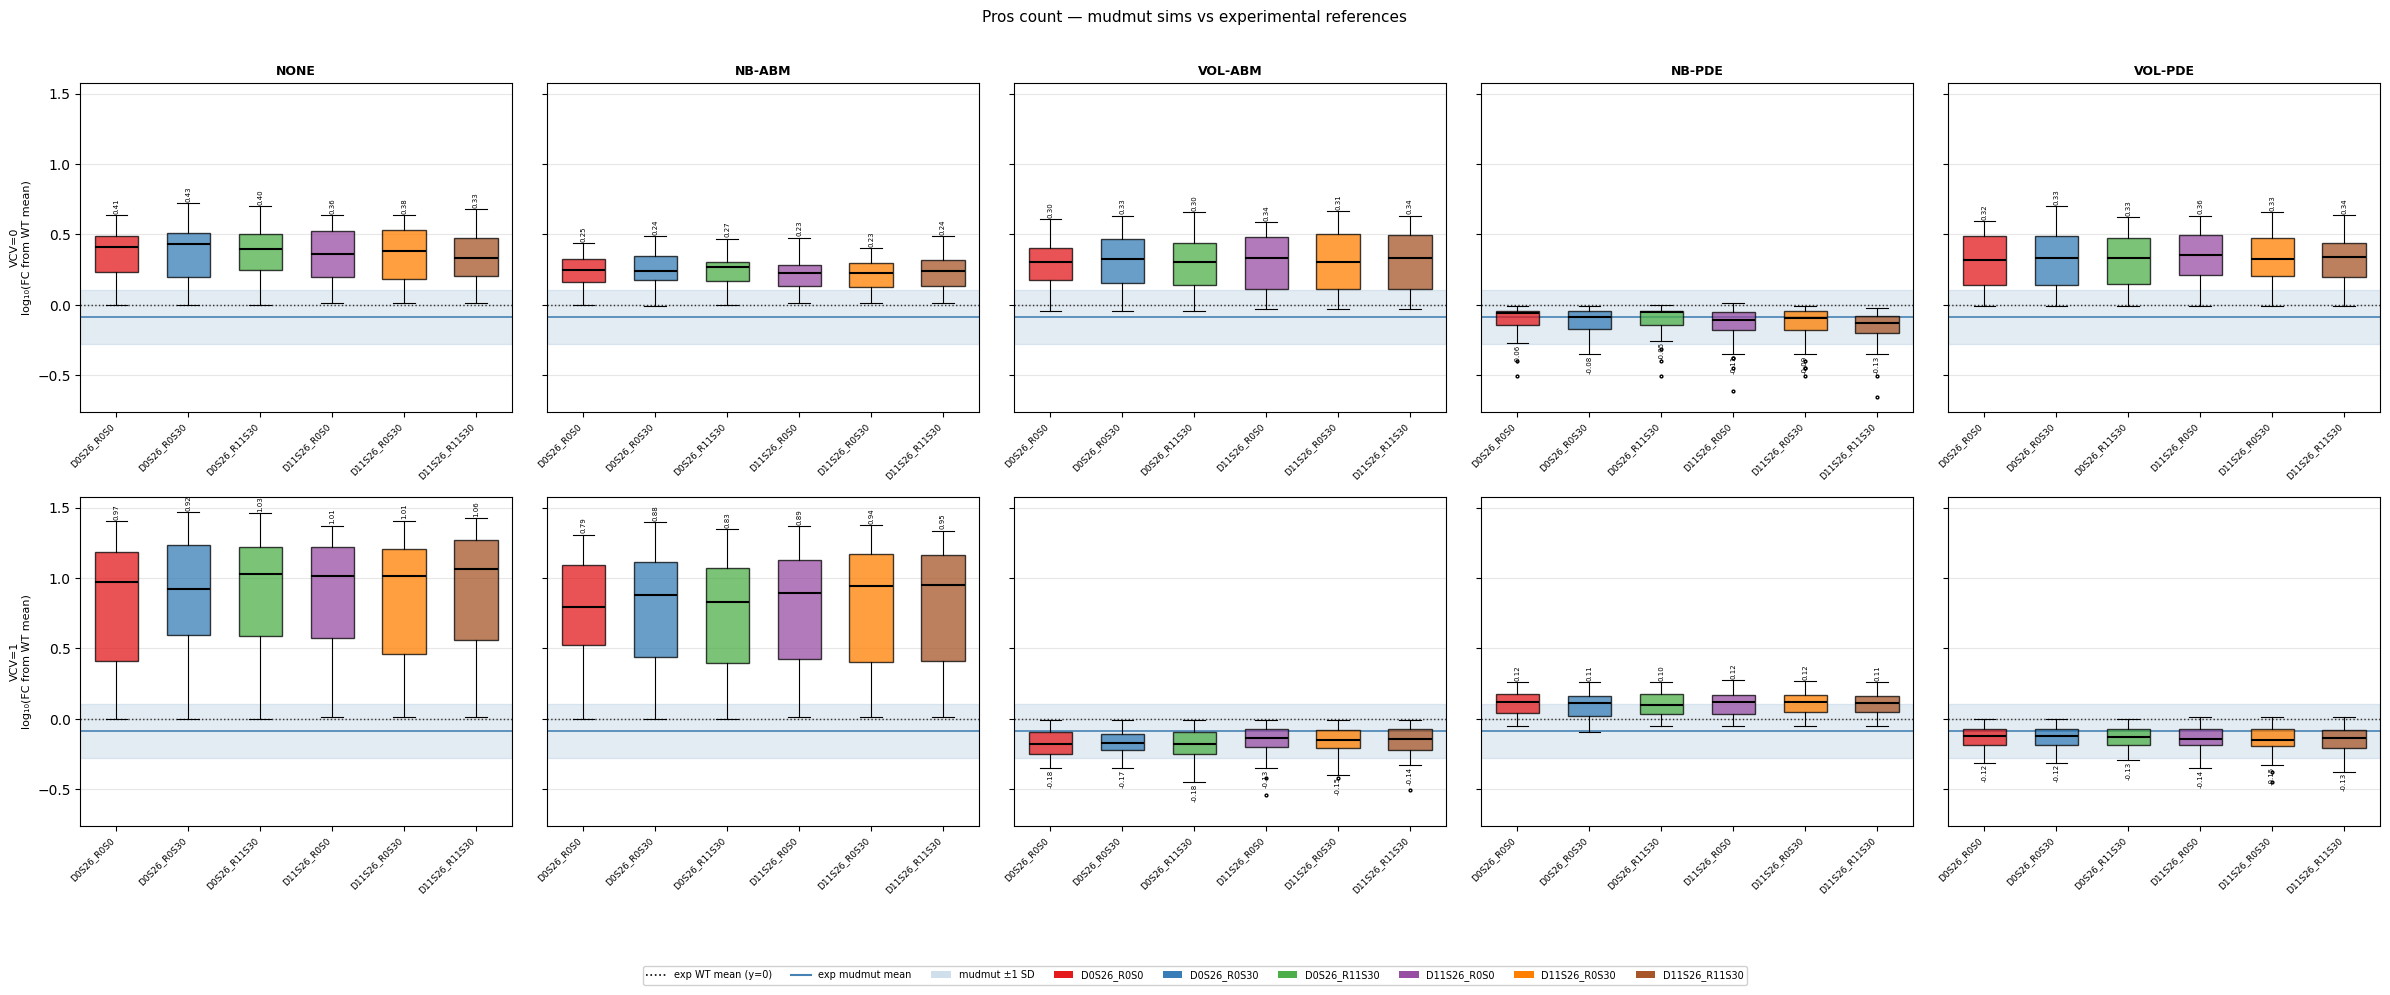

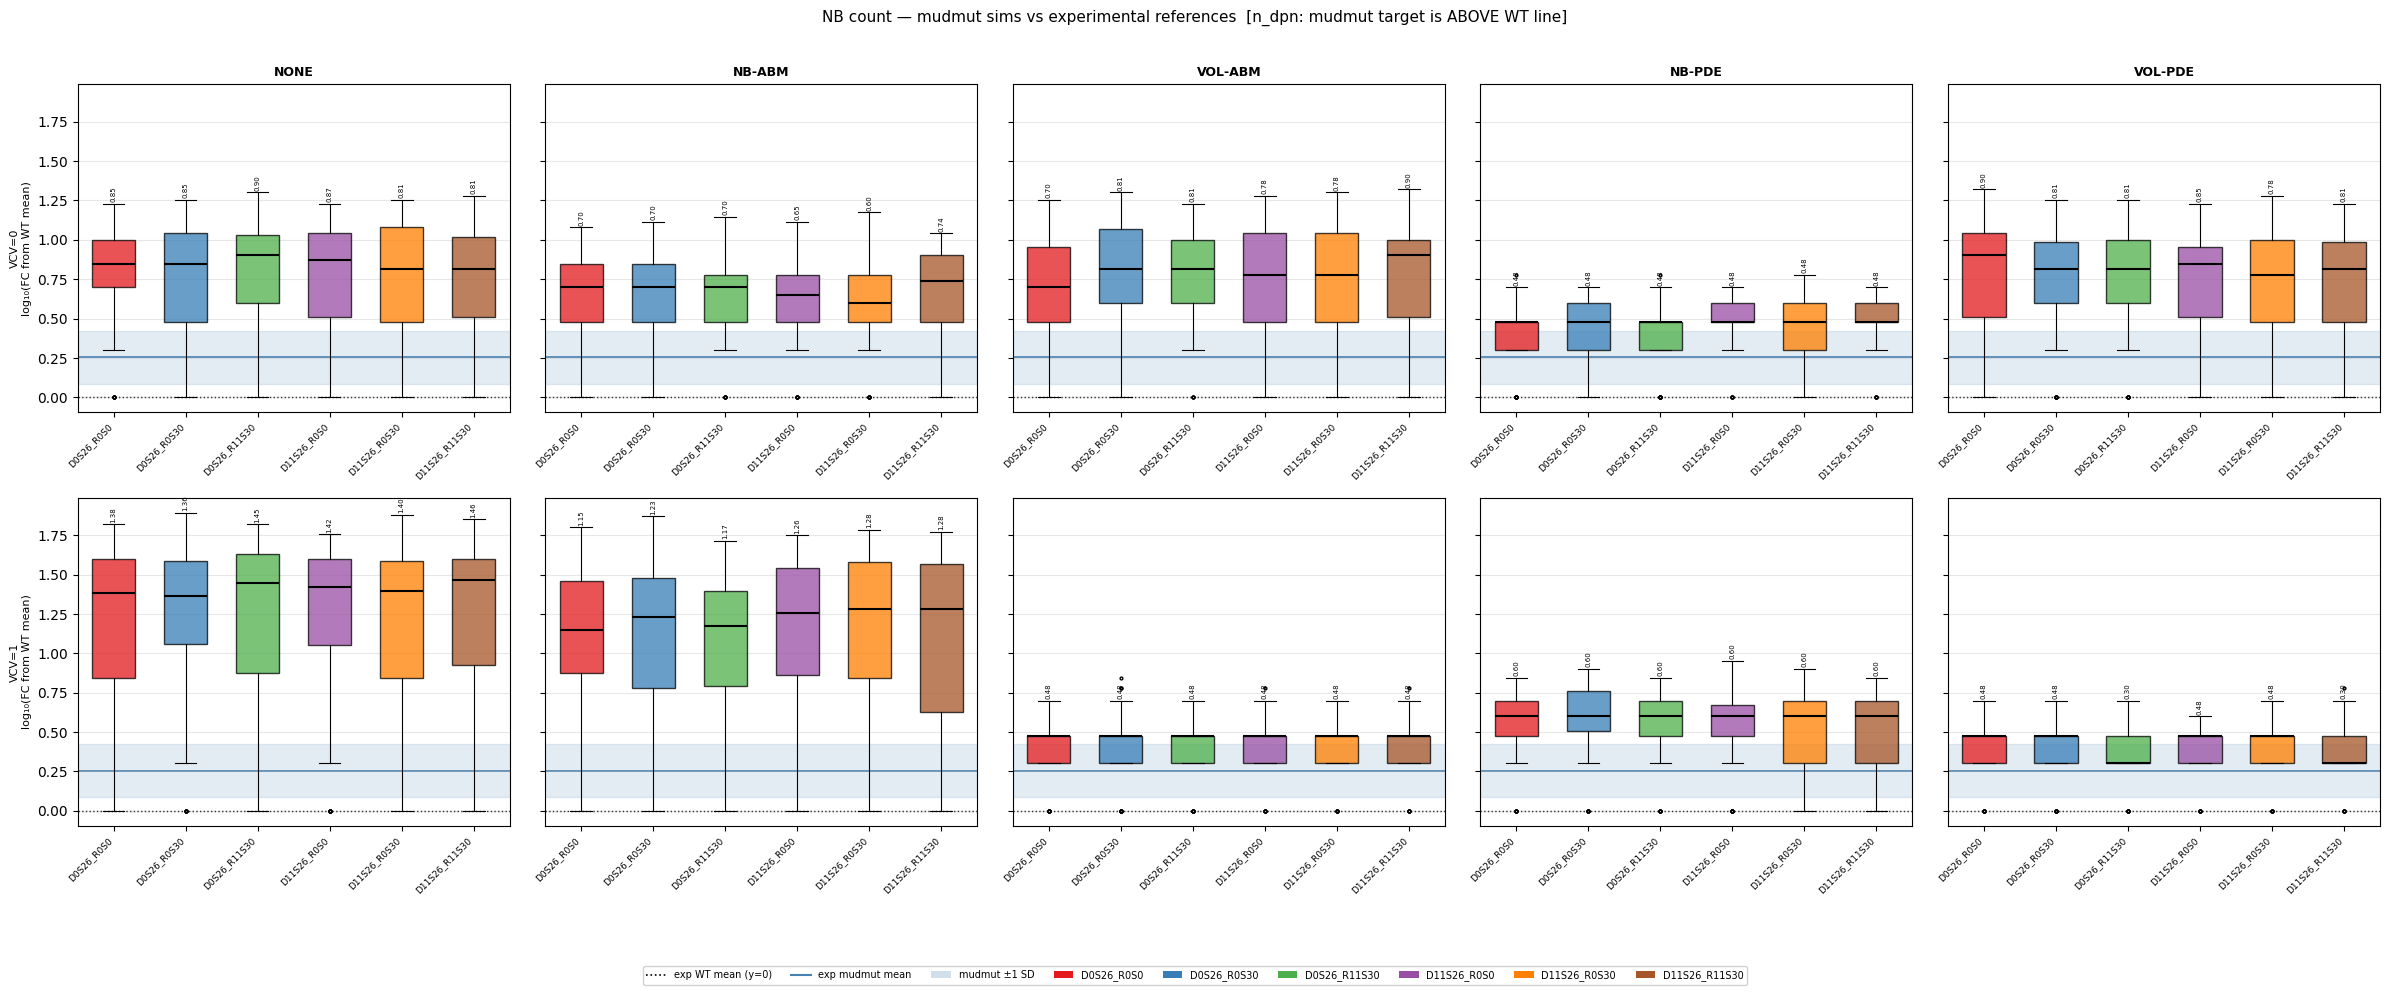

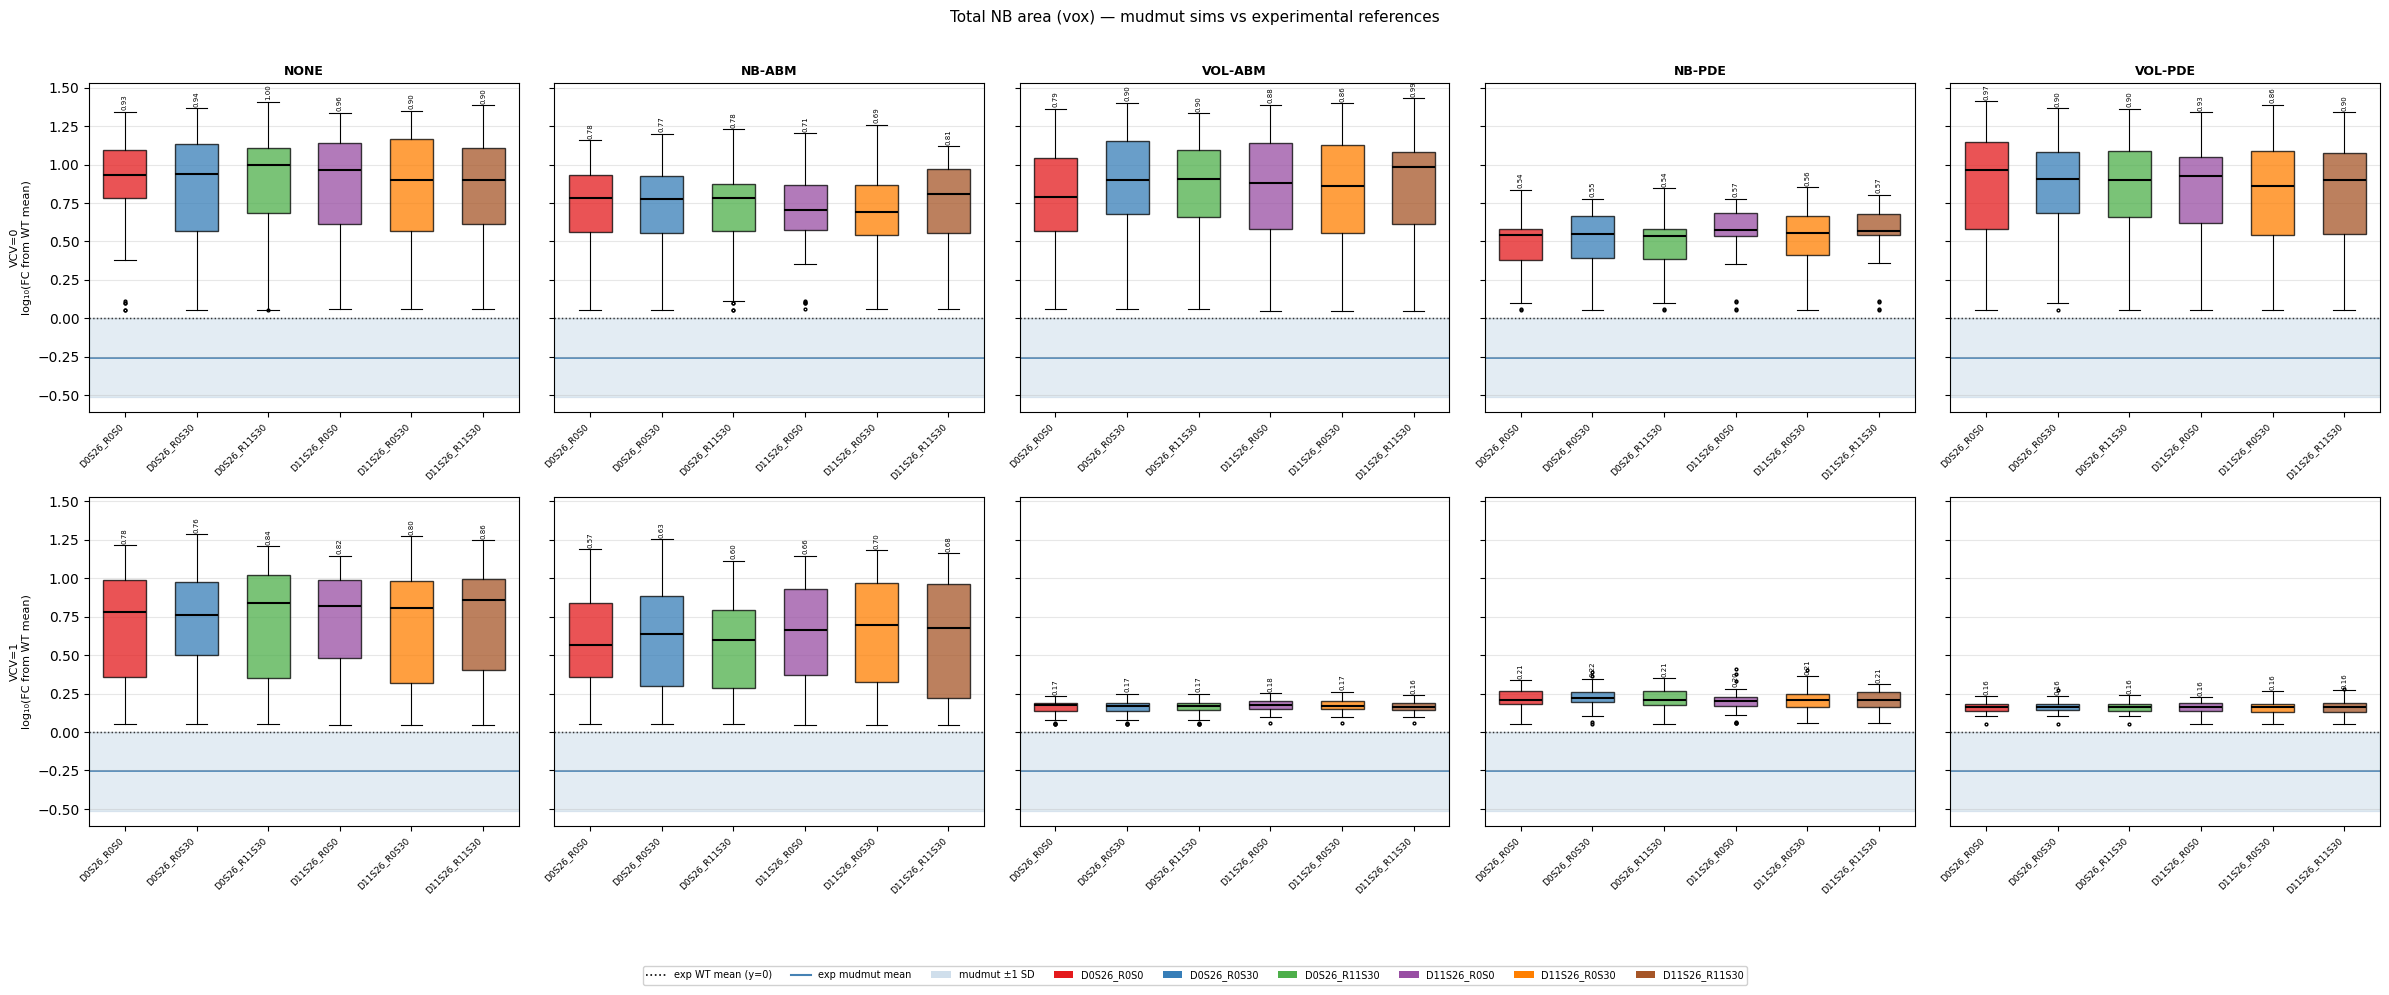

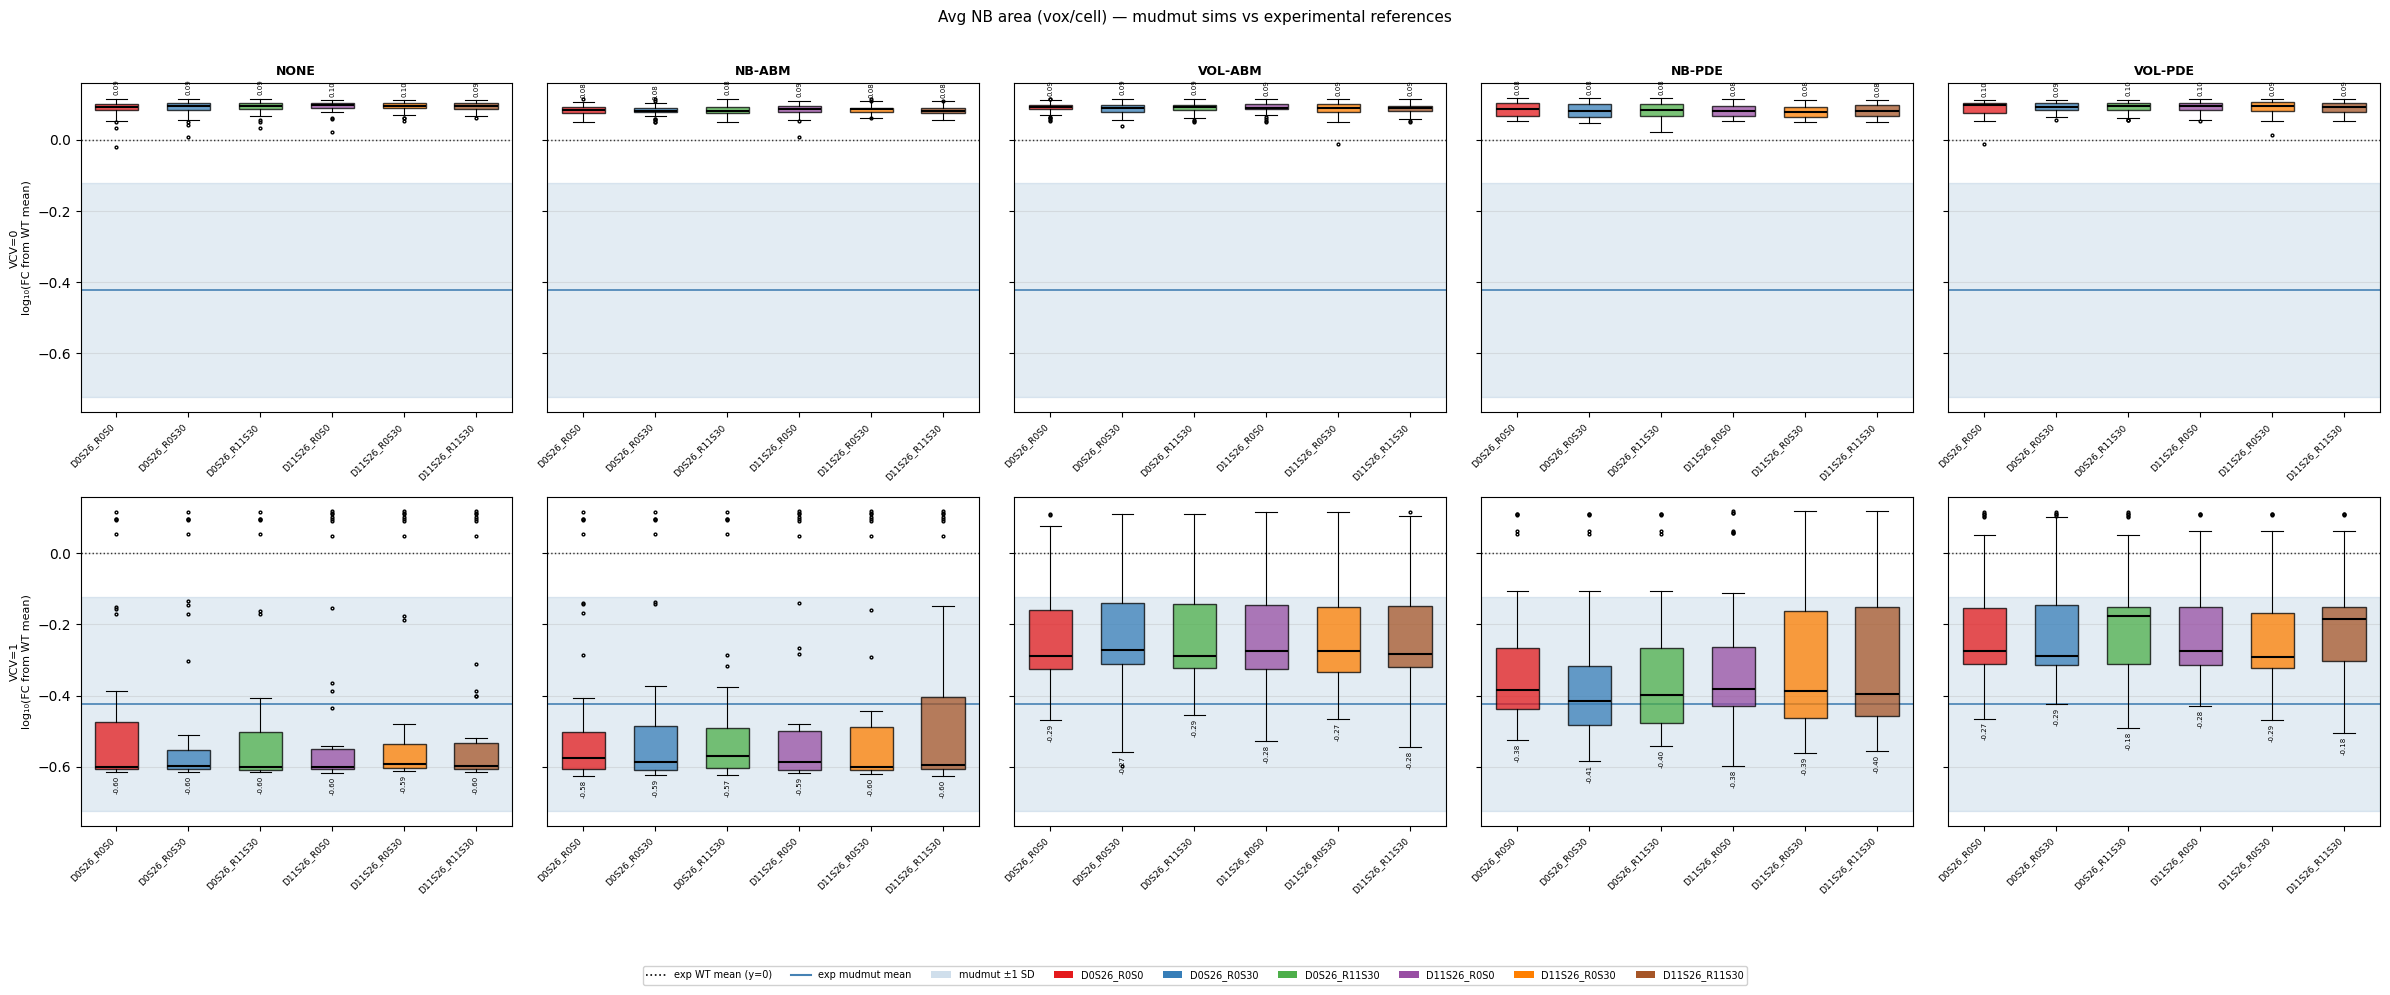

In [22]:
for metric in METRICS:
    fig = mudmut_facet_chart(metric)
    fig.savefig(FIGURES_DIR / f'sec23_{metric}.png', dpi=120, bbox_inches='tight')
    plt.show()

### Section 2+3 — Interpretation

*Record observations here after running the cells above.*

Key questions to address:
- Which VCV=0 panels (if any) cross below the WT line / above it for n_dpn?
- Which VCV=1 panels cross the WT line?
- Which panels enter the mudmut ±1 SD band?
- Does any regulatory dynamic perform consistently better across angle conditions?

---
## Section 4 — Angle Distribution Effects

**Question:** Among accepted conditions, do DIV mean, APICAL sigma, or APICAL mean
systematically affect alignment with the experimental mudmut target?

**Y-axis:** log₁₀(value / experimental mudmut mean). Mudmut mean anchors at y=0
(solid blue line); WT mean appears as a dotted black line.

**Sub-sections:**
- **4a** — DIV mean effect: APICAL=N(0,0) fixed; D0S26_R0S0 vs D11S26_R0S0
- **4b** — APICAL sigma effect: DIV=D0S26 (or D11S26) fixed; R0S0 vs R0S30
- **4c** — APICAL mean effect: DIV=D0S26, APICAL sigma=30 fixed; R0S30 vs R11S30
- **4d** — Full 2×3 grid: all accepted conditions side by side

In [23]:
def mudmut_angle_chart(metric, tags_subset, figsize=(24, 10)):
    """
    2-row × 5-column facet chart with y-axis anchored at experimental mudmut mean.
    Y = log10(value / mm_mean). Mudmut mean at y=0 (solid blue);
    shaded band = mudmut ±1 SD. WT mean shown as dotted black line.
    """
    subset_conditions = [mm_cond_df.loc[t, 'condition'] for t in tags_subset]

    wt_mean             = wt_ref[metric][0]
    mm_mean_val, mm_std = mm_ref[metric]
    wt_lfc_from_mm      = np.log10(wt_mean / mm_mean_val)
    mm_half             = 0.05 if mm_std == 0 else np.log10(1 + mm_std / mm_mean_val)

    fig, axes = plt.subplots(2, len(REG_DYN_ORDER), figsize=figsize, sharey=True)

    for ri, vcv in enumerate([0, 1]):
        for ci, reg_dyn in enumerate(REG_DYN_ORDER):
            ax = axes[ri, ci]
            ax.axhspan(-mm_half, mm_half, alpha=0.15, color='steelblue', zorder=0)
            ax.axhline(0, color='steelblue', linewidth=1.2, zorder=1)
            ax.axhline(wt_lfc_from_mm, color='black', linestyle=':', linewidth=1, zorder=1)

            panel = sim_mm[
                (sim_mm['critical_volume_mode'] == vcv) &
                (sim_mm['regulatory_dynamic']   == reg_dyn) &
                (sim_mm['condition'].isin(subset_conditions))
            ]

            data_by_tag = []
            for tag in tags_subset:
                cond = mm_cond_df.loc[tag, 'condition']
                runs = panel[panel['condition'] == cond][metric]
                lfc  = fold_change_log(runs, mm_mean_val) if not runs.empty else np.array([np.nan])
                data_by_tag.append(lfc)

            bp = ax.boxplot(
                data_by_tag,
                positions=range(len(tags_subset)),
                widths=0.6,
                patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 1.5},
                whiskerprops={'linewidth': 0.8},
                capprops={'linewidth': 0.8},
                flierprops={'marker': 'o', 'markersize': 2, 'linestyle': 'none'},
                zorder=2,
            )
            for patch, tag in zip(bp['boxes'], tags_subset):
                patch.set_facecolor(MM_COND_COLORS.get(tag, '#cccccc'))
                patch.set_alpha(0.75)

            for xi, (tag, d) in enumerate(zip(tags_subset, data_by_tag)):
                if np.all(np.isnan(d)):
                    continue
                med       = float(np.nanmedian(d))
                upper_cap = bp['caps'][2 * xi + 1].get_ydata()[0]
                lower_cap = bp['caps'][2 * xi].get_ydata()[0]
                if med >= 0:
                    ax.text(xi, upper_cap + 0.01, f'{med:.2f}',
                            ha='center', va='bottom', fontsize=5, rotation=90)
                else:
                    ax.text(xi, lower_cap - 0.01, f'{med:.2f}',
                            ha='center', va='top', fontsize=5, rotation=90)

            ax.set_xticks(range(len(tags_subset)))
            ax.set_xticklabels(tags_subset, rotation=45, ha='right', fontsize=6.5)
            ax.grid(axis='y', alpha=0.3)

            if ri == 0:
                ax.set_title(reg_dyn, fontsize=9, fontweight='bold')
            if ci == 0:
                ax.set_ylabel(f'VCV={vcv}\nlog₁₀(FC from mudmut mean)', fontsize=8)

    direction = '  [n_dpn: WT dotted line is below 0]' if metric == 'n_dpn' else ''
    fig.suptitle(
        f'{METRIC_LABELS[metric]} — angle effects  (y=0 = exp mudmut mean){direction}',
        fontsize=11,
    )

    legend_handles = [
        Line2D([0], [0], color='steelblue', linewidth=1.5, label='exp mudmut mean (y=0)'),
        Patch(facecolor='steelblue', alpha=0.25, label='mudmut ±1 SD'),
        Line2D([0], [0], color='black', linestyle=':', linewidth=1.2, label='exp WT mean'),
    ] + [Patch(facecolor=MM_COND_COLORS.get(t, '#ccc'), label=t) for t in tags_subset]

    fig.tight_layout(rect=[0, 0.08, 1, 0.97])
    fig.legend(handles=legend_handles, fontsize=7, loc='lower center',
               ncol=len(legend_handles), bbox_to_anchor=(0.5, 0.0), framealpha=0.9)
    return fig

### Section 4a — DIV mean effect (APICAL fixed at N(0,0))

Restrict to conditions where APICAL = N(0,0): D0S26_R0S0 and D11S26_R0S0.
Isolates the effect of shifting the DIV distribution mean from 0 to 11.

4a tags: ['D0S26_R0S0', 'D11S26_R0S0']


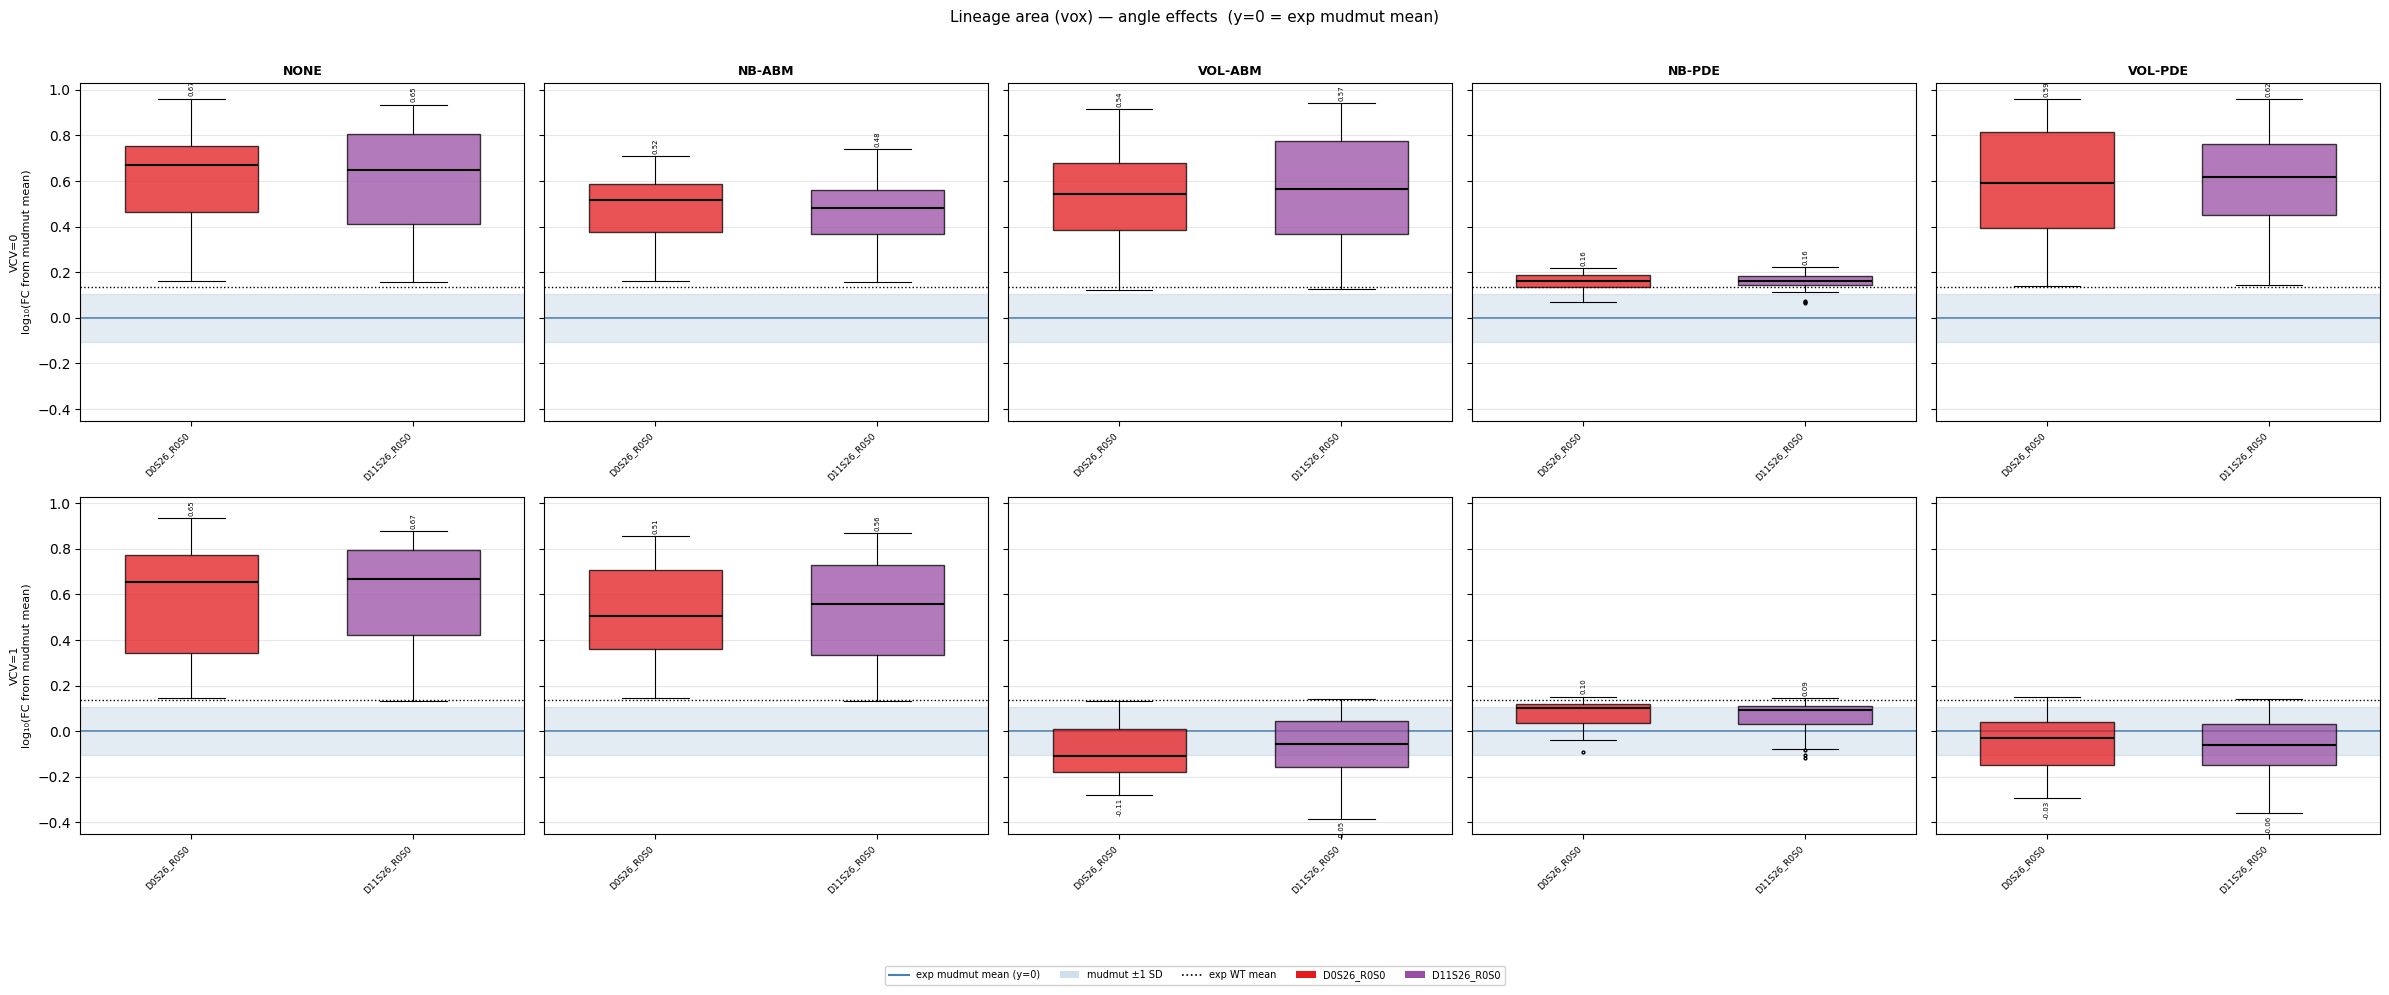

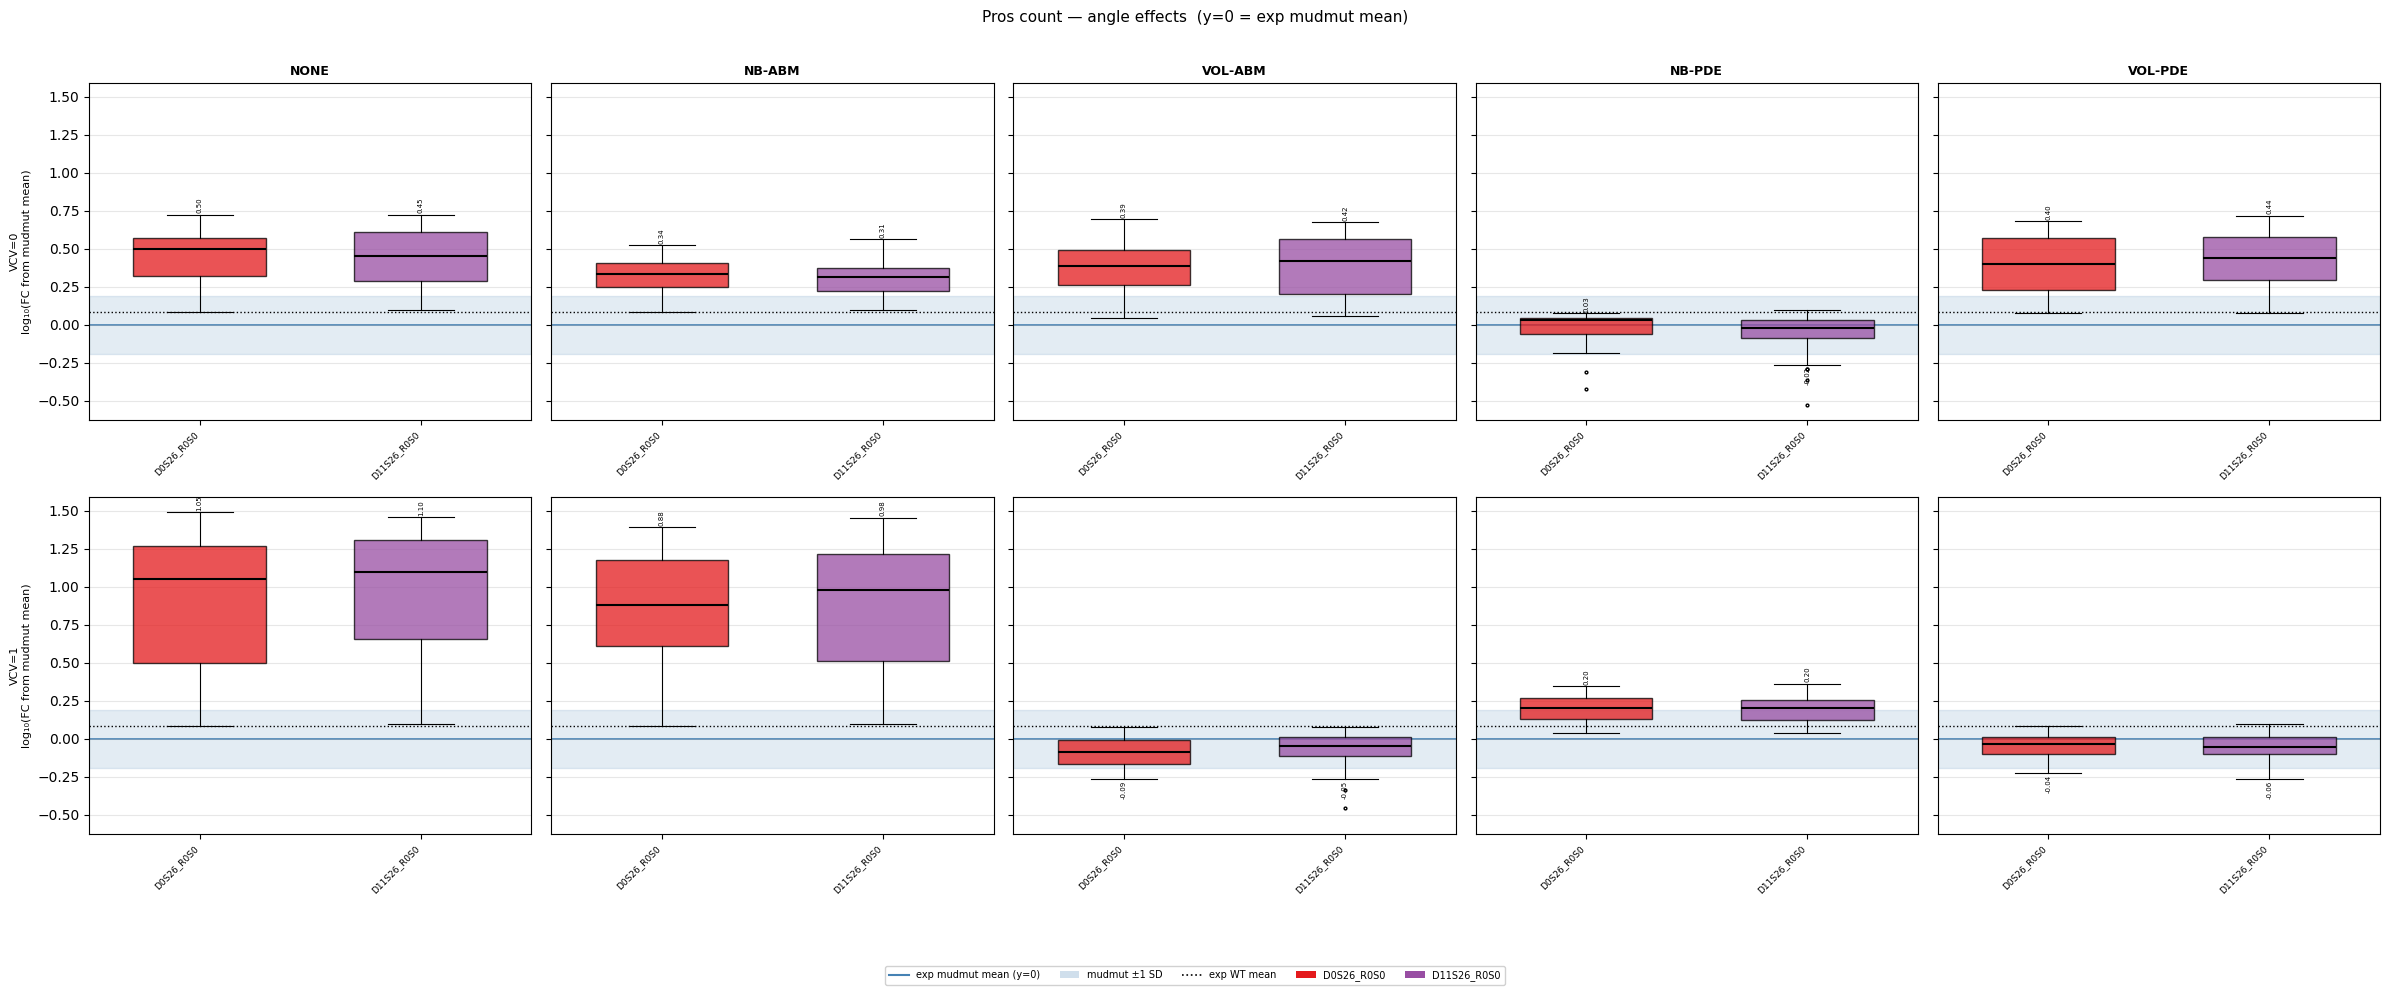

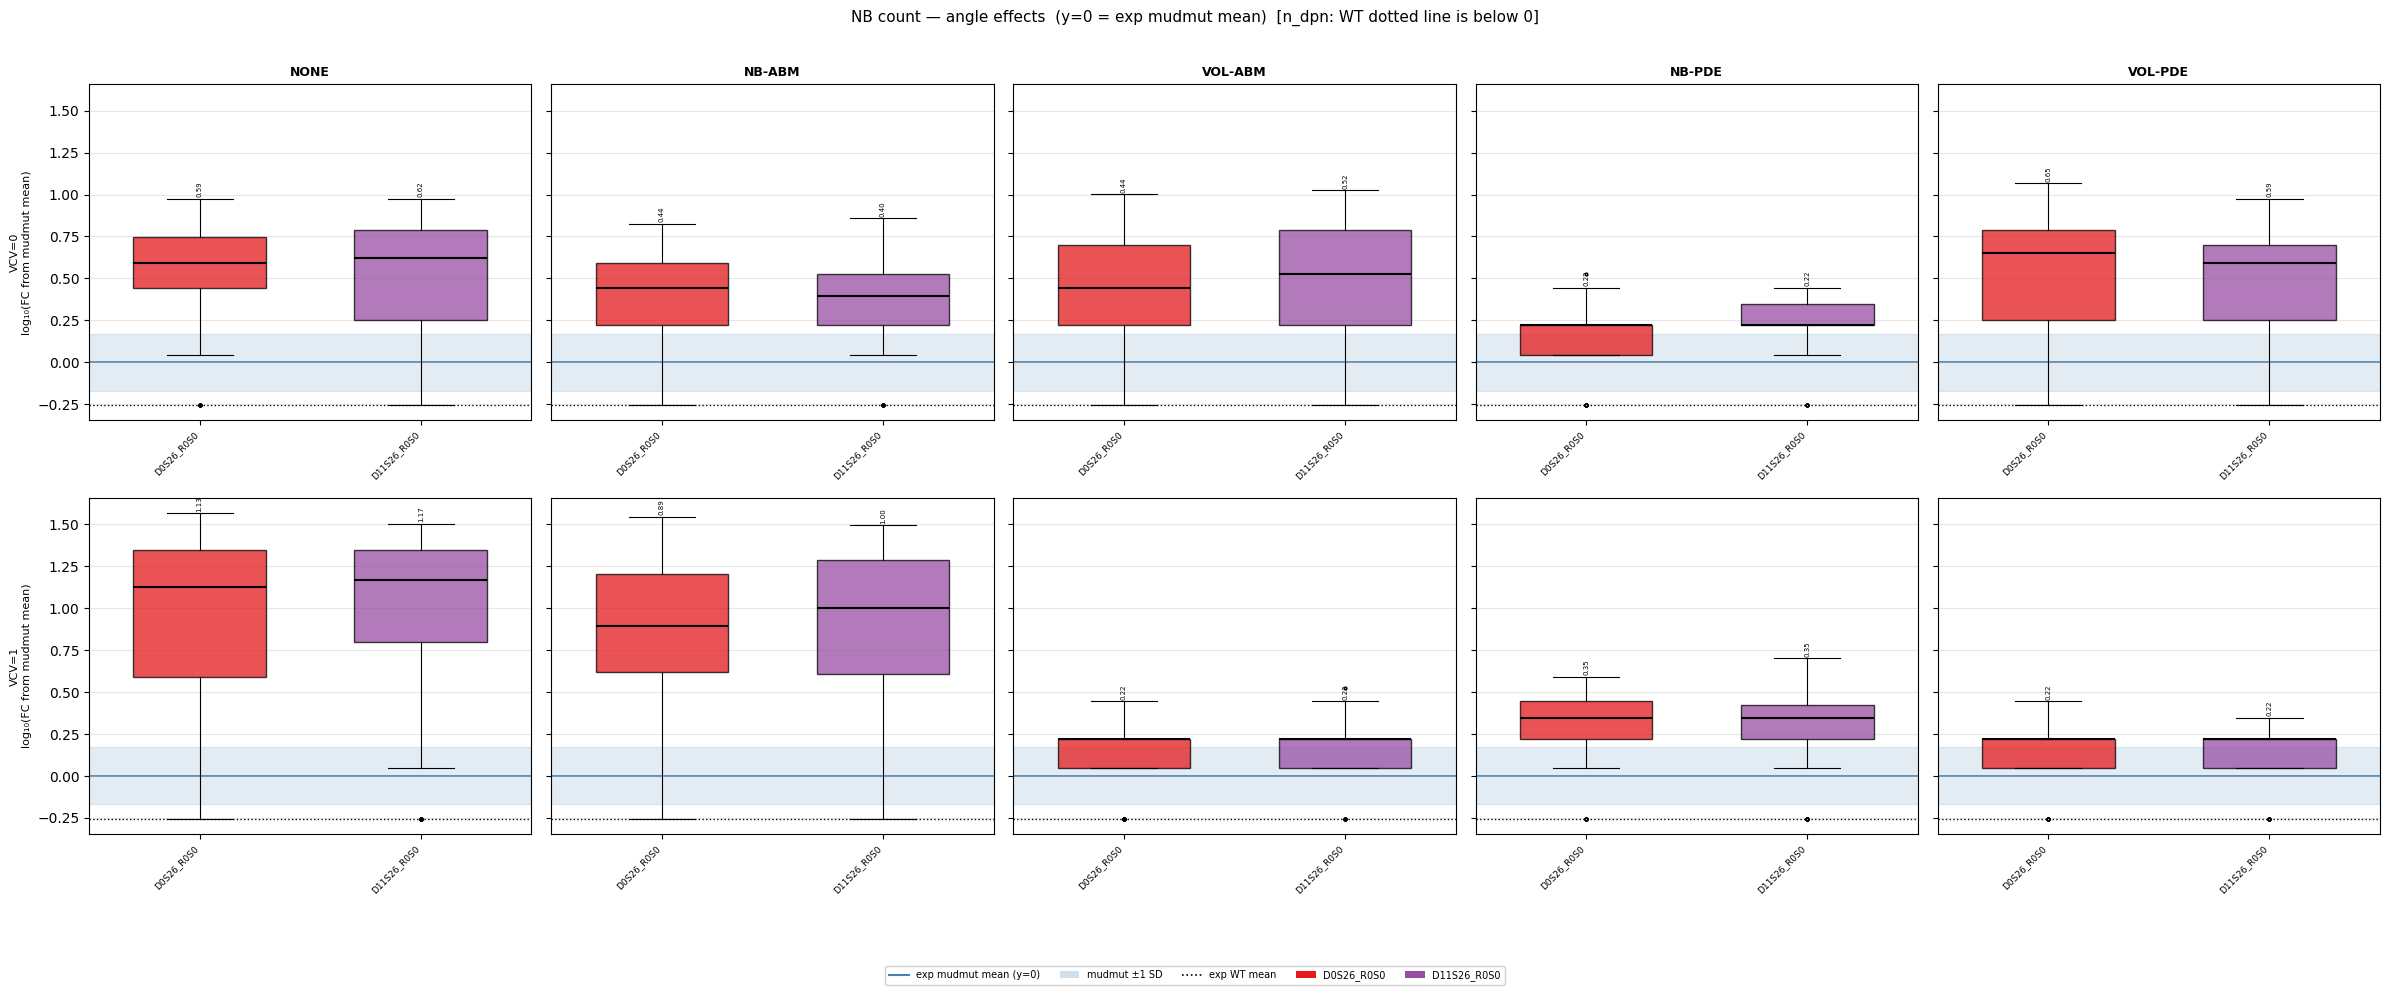

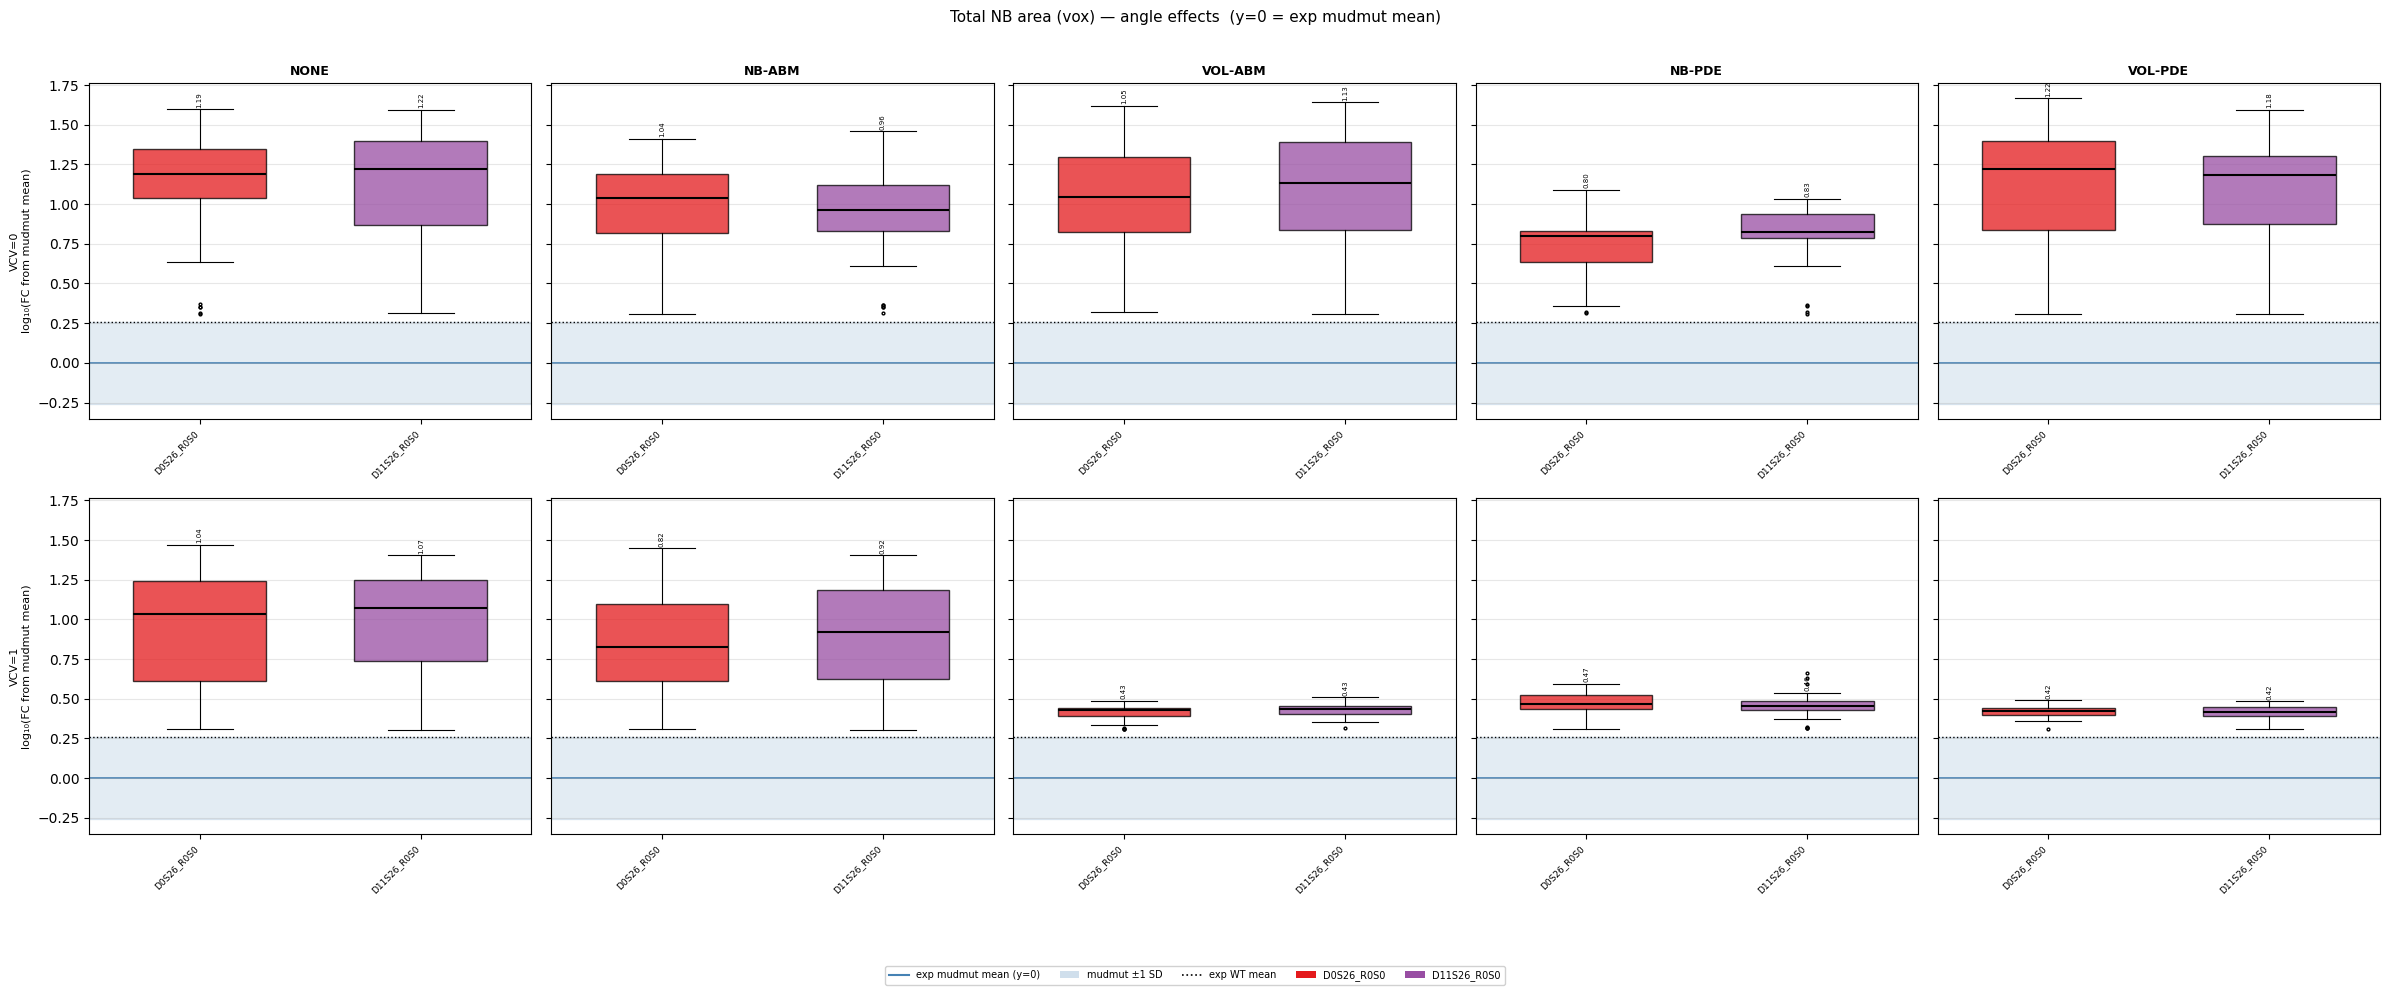

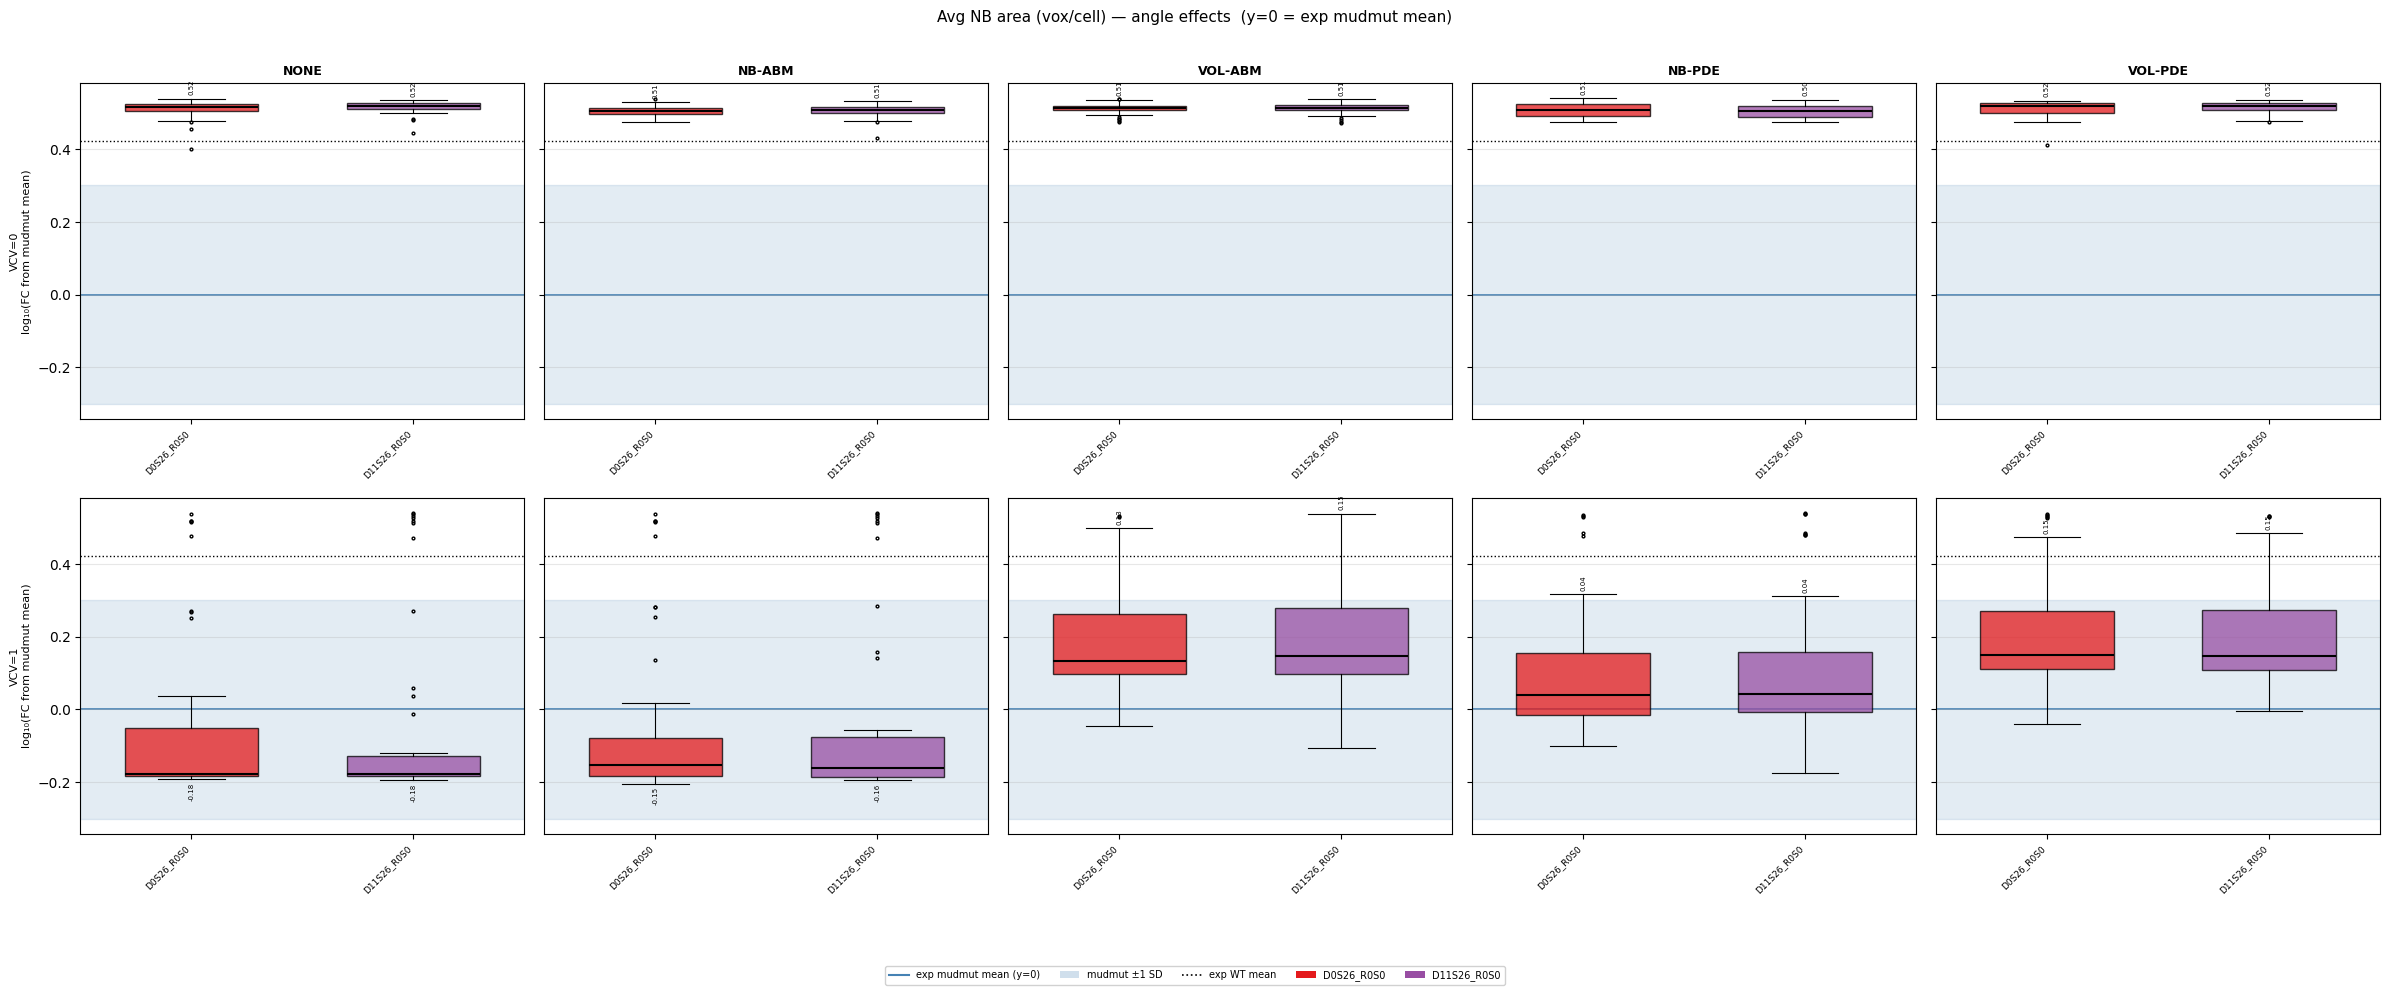

In [24]:
sec4a_tags = [t for t in ['D0S26_R0S0', 'D11S26_R0S0'] if t in accepted_mm_tags]

if len(sec4a_tags) < 2:
    print(f'Section 4a: only {len(sec4a_tags)} of 2 expected tags accepted — '
          'skipping comparison chart.')
    if sec4a_tags:
        print(f'  Present: {sec4a_tags}')
else:
    print(f'4a tags: {sec4a_tags}')
    for metric in METRICS:
        fig = mudmut_angle_chart(metric, sec4a_tags)
        fig.savefig(FIGURES_DIR / f'sec4a_{metric}.png', dpi=120, bbox_inches='tight')
        plt.show()

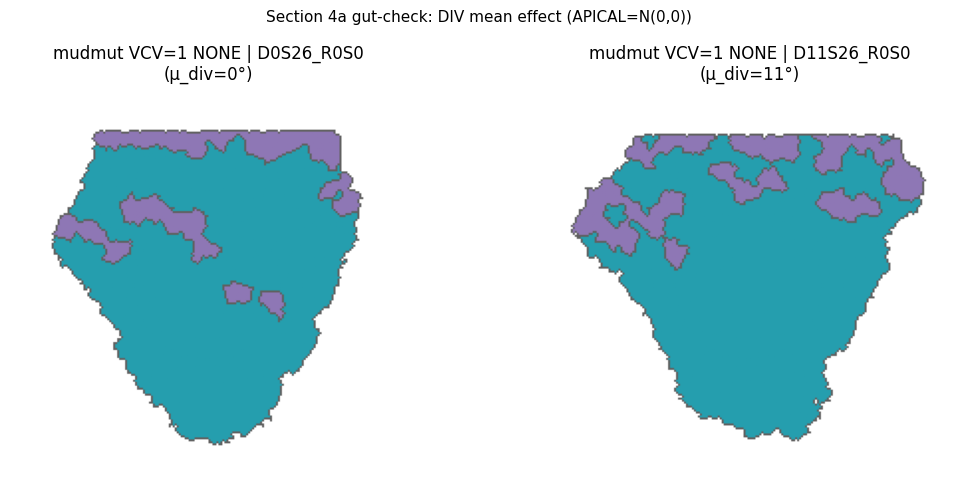

In [25]:
if len(sec4a_tags) >= 1:
    fig, axes = plt.subplots(1, len(sec4a_tags), figsize=(5.5 * len(sec4a_tags), 5))
    if len(sec4a_tags) == 1:
        axes = [axes]
    for ax, tag in zip(axes, sec4a_tags):
        cond = mm_cond_df.loc[tag, 'condition']
        draw_example_lineage(
            cond, 'vcv1_noreg', ax=ax,
            title=f'mudmut VCV=1 NONE | {tag}\n(μ_div={mm_cond_df.loc[tag,"div_mean"]}°)'
        )
    plt.suptitle('Section 4a gut-check: DIV mean effect (APICAL=N(0,0))', fontsize=11)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'sec4a_gutcheck.png', dpi=120, bbox_inches='tight')
    plt.show()

### Section 4b — APICAL sigma effect (DIV mean fixed)

Compare APICAL N(0,0) vs N(0,30) at a fixed DIV baseline (D0S26 preferred;
falls back to D11S26 if D0S26 was eliminated). Isolates the effect of adding
apical-axis rotation spread.

Skipped if neither DIV baseline has both sigma=0 and sigma=30 accepted.

4b baseline: D0S26
4b tags: ['D0S26_R0S0', 'D0S26_R0S30']


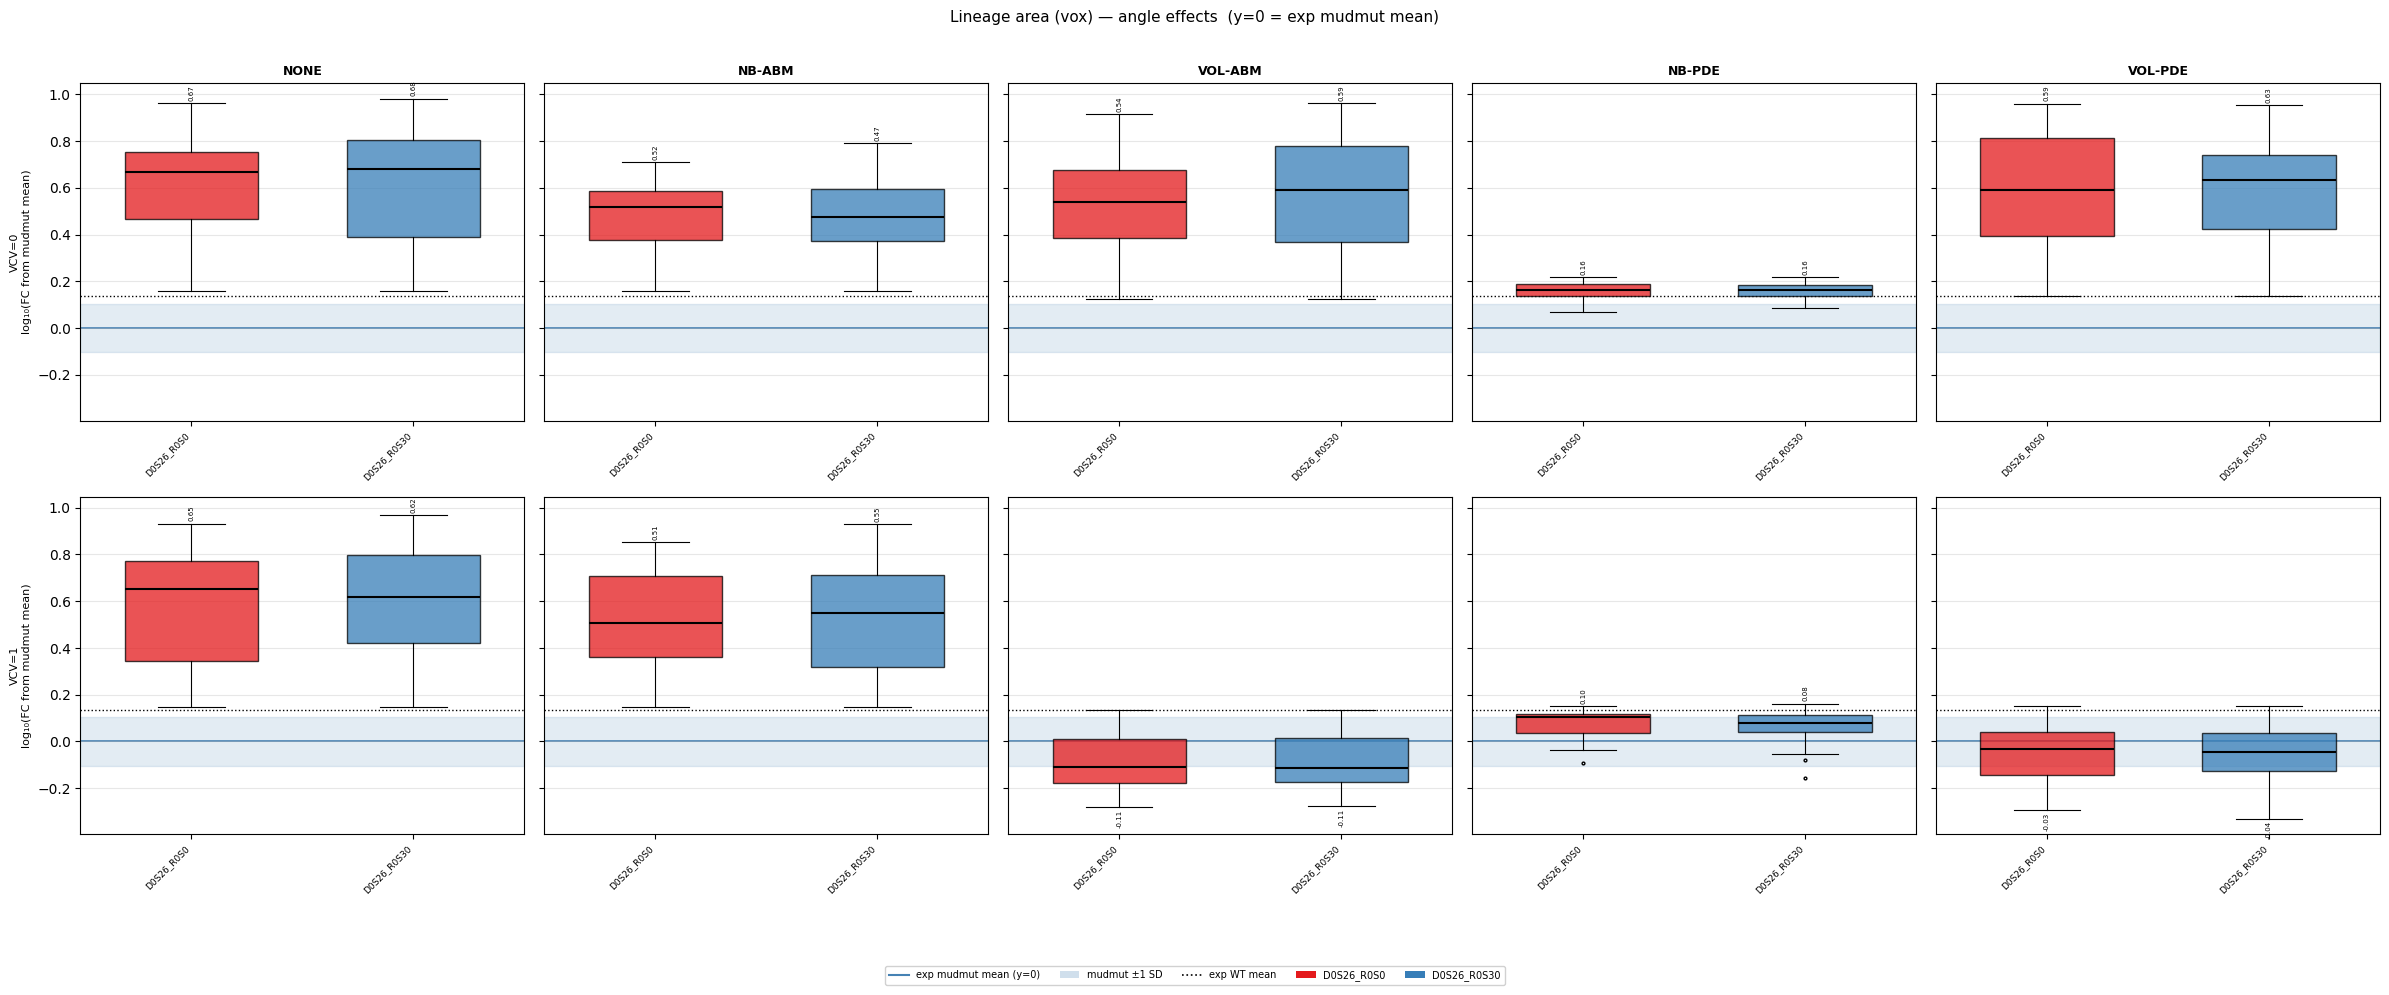

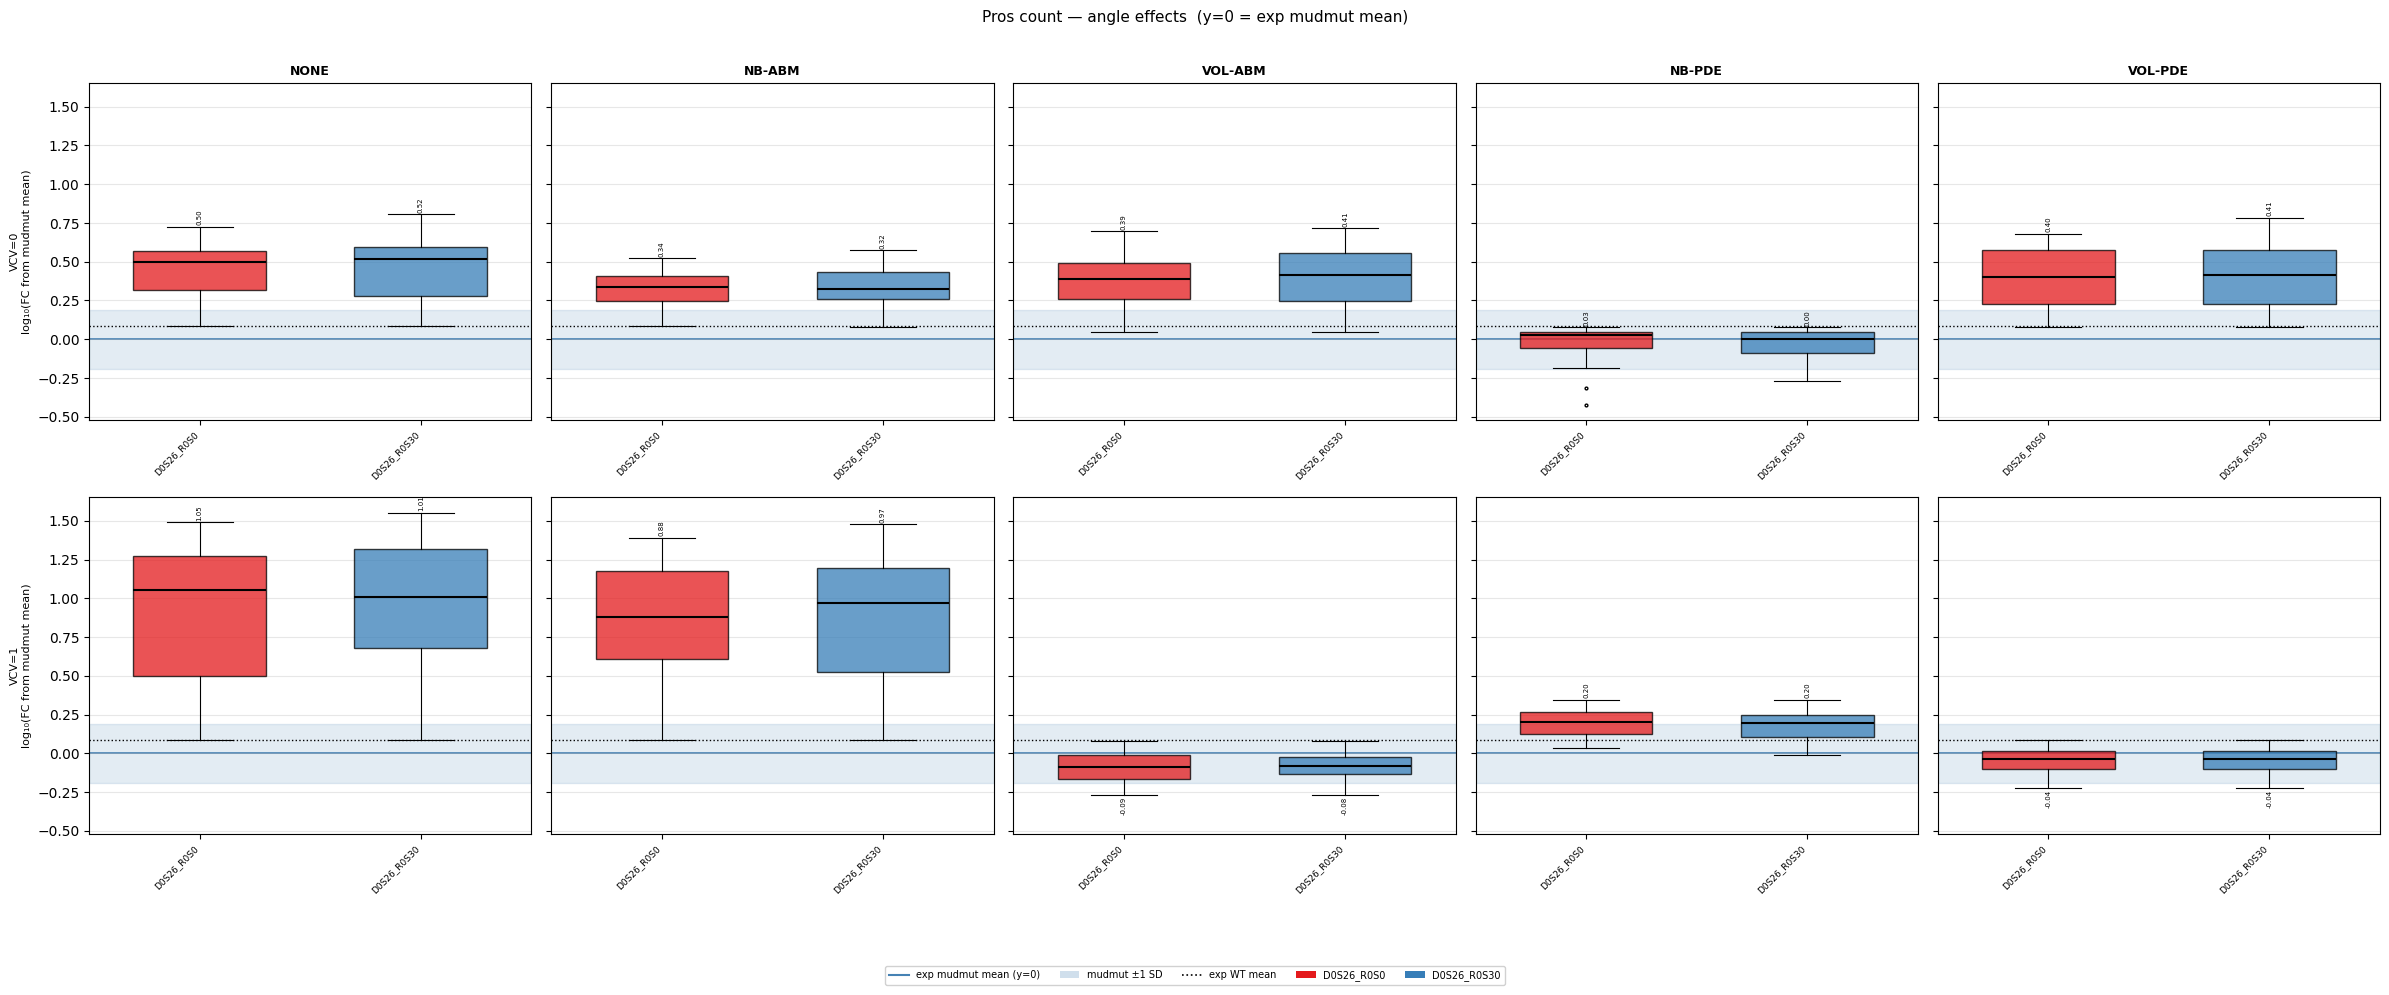

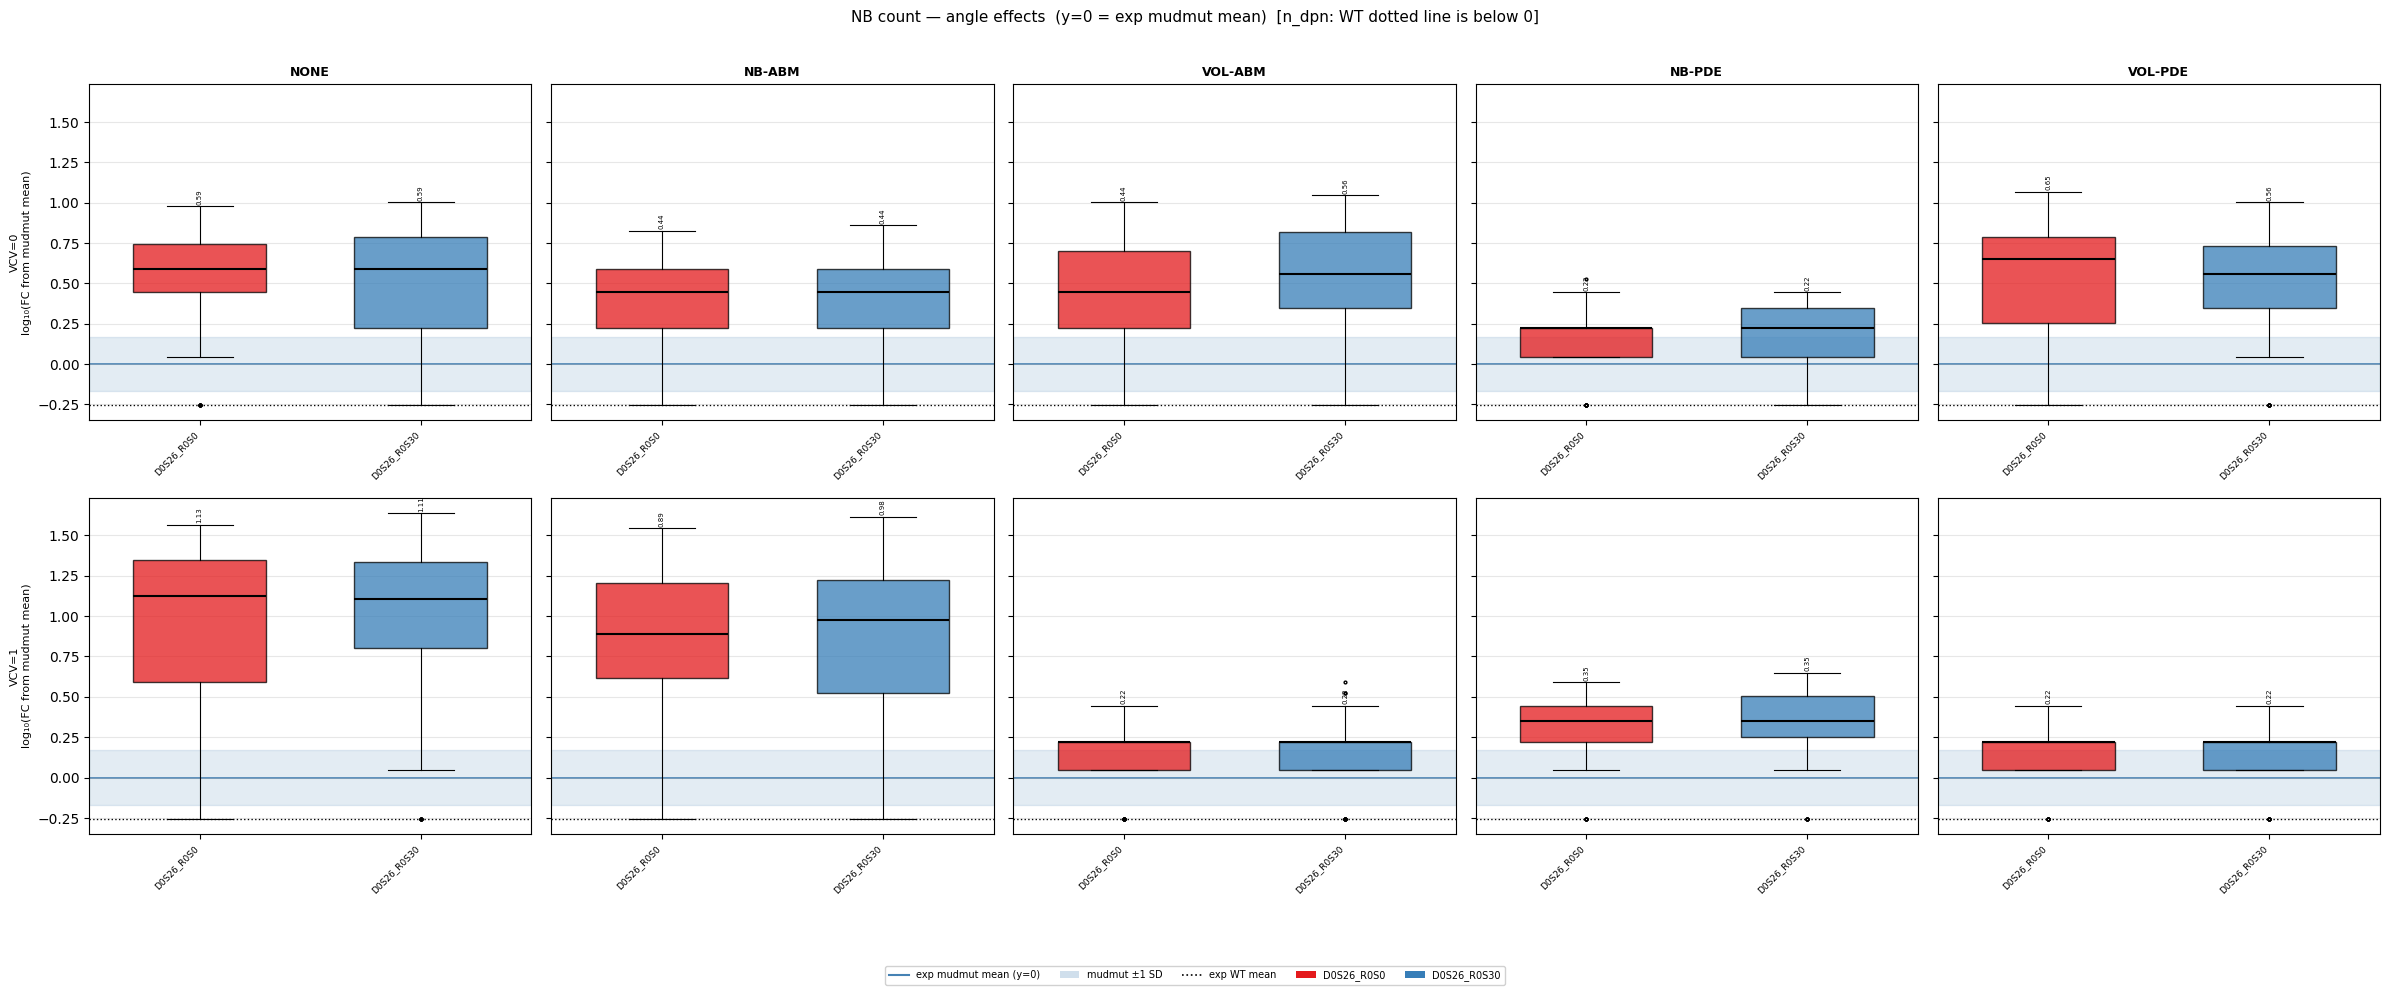

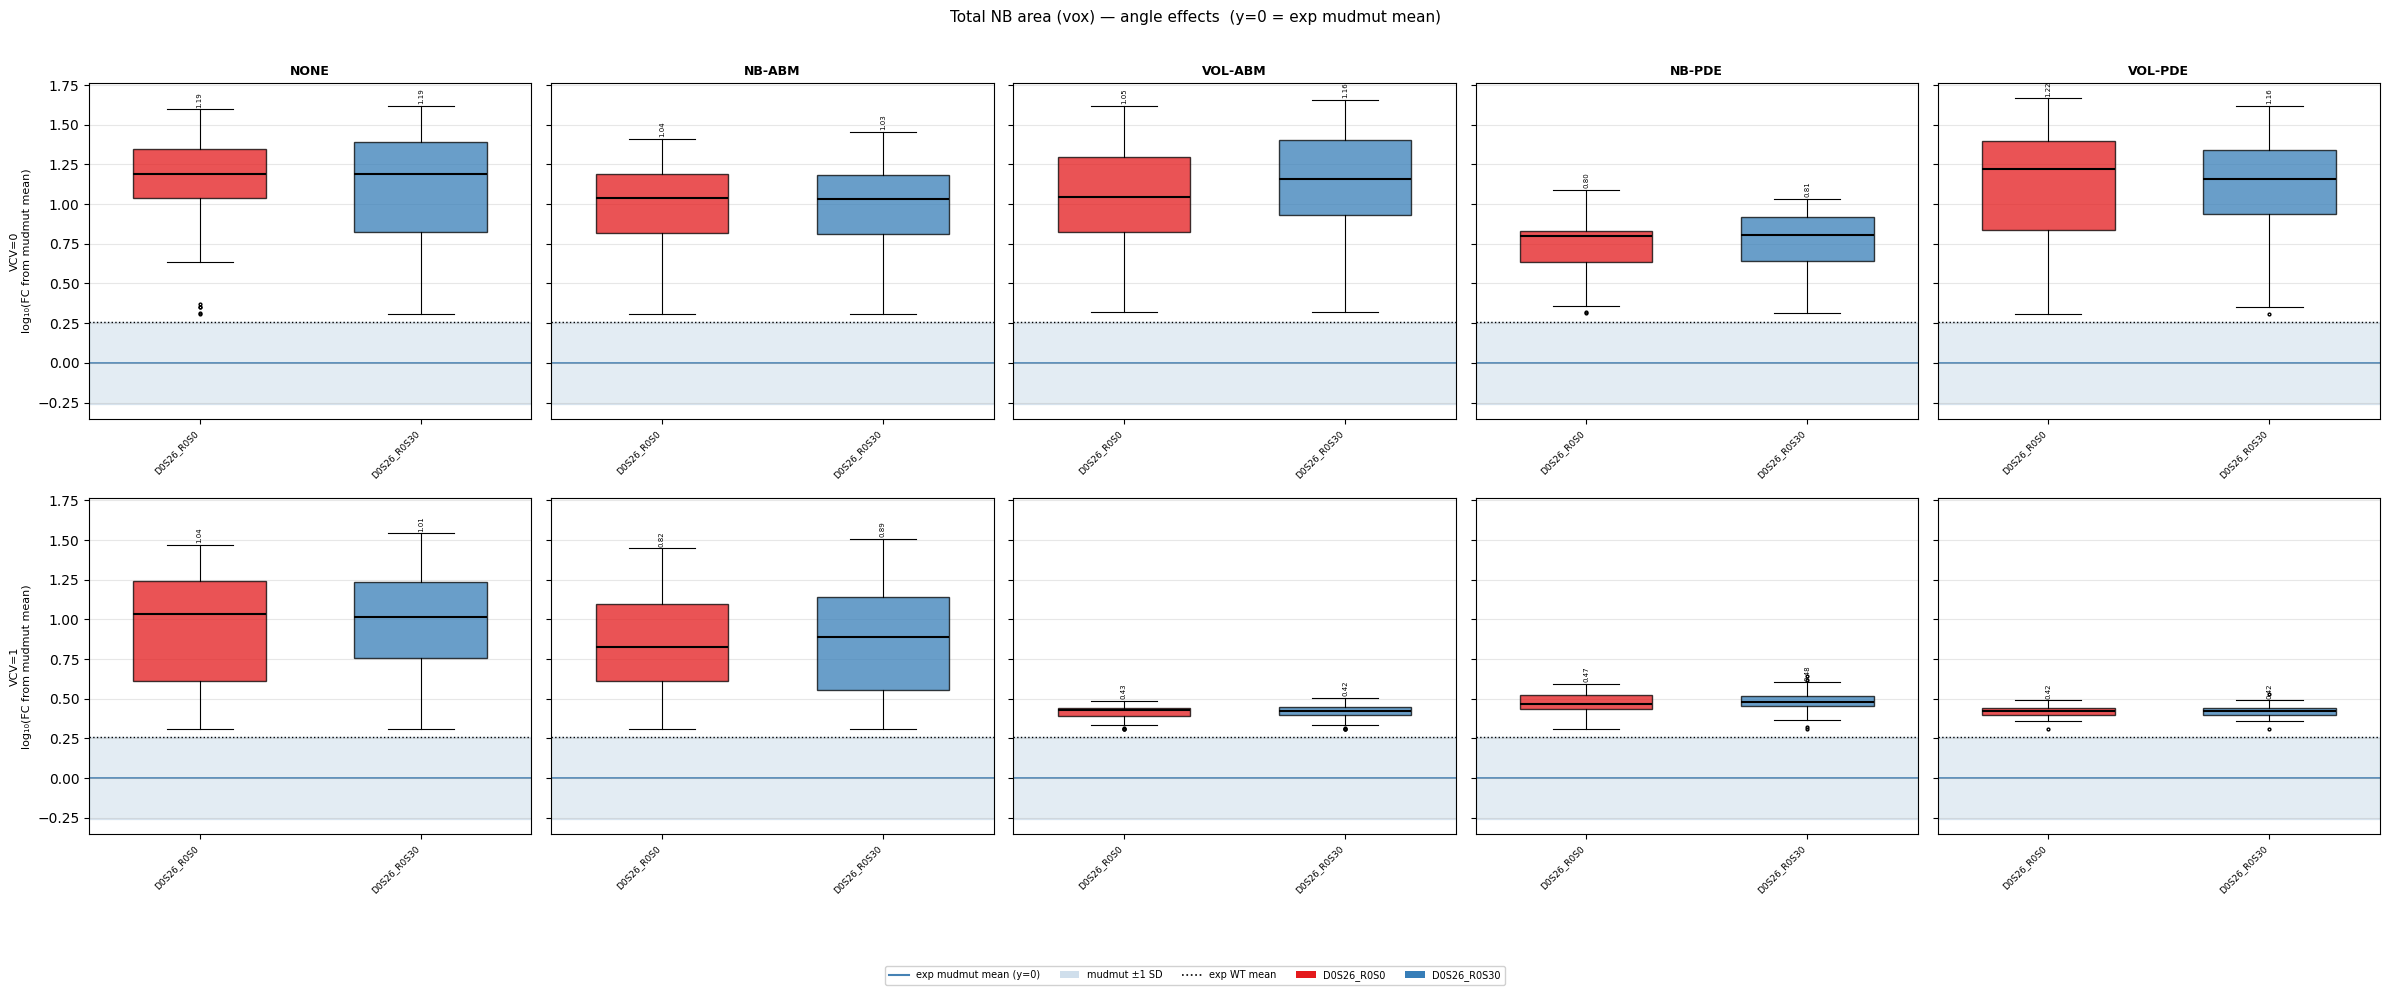

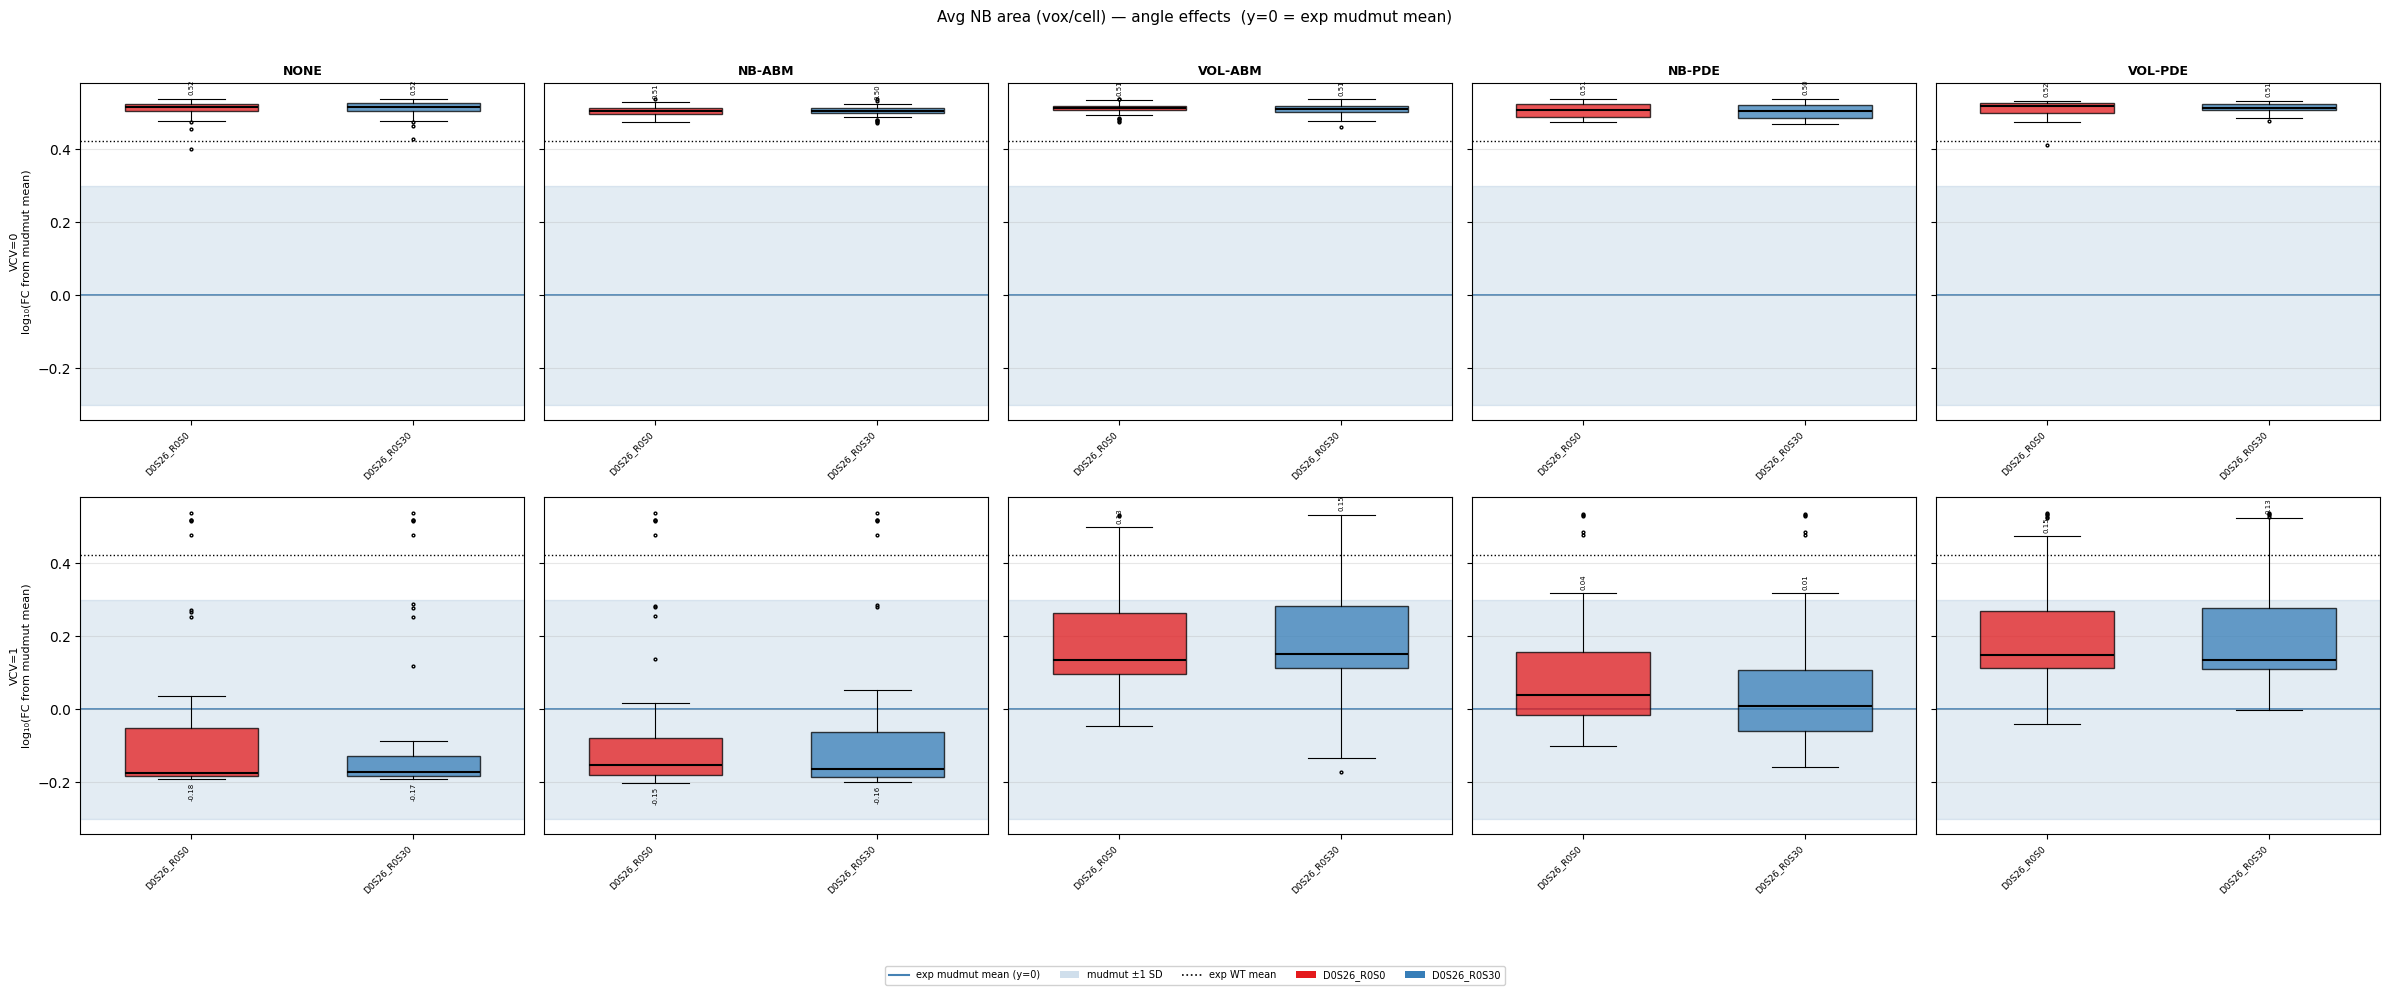

In [26]:
# Select DIV baseline: D0S26 preferred, fall back to D11S26
sec4b_tags = None
for div_prefix in ['D0S26', 'D11S26']:
    t0 = f'{div_prefix}_R0S0'
    t30 = f'{div_prefix}_R0S30'
    if t0 in accepted_mm_tags and t30 in accepted_mm_tags:
        sec4b_tags = [t0, t30]
        print(f'4b baseline: {div_prefix}')
        break

if sec4b_tags is None:
    print('Section 4b SKIPPED — no DIV baseline with both APICAL sigma conditions accepted.')
else:
    print(f'4b tags: {sec4b_tags}')
    for metric in METRICS:
        fig = mudmut_angle_chart(metric, sec4b_tags)
        fig.savefig(FIGURES_DIR / f'sec4b_{metric}.png', dpi=120, bbox_inches='tight')
        plt.show()

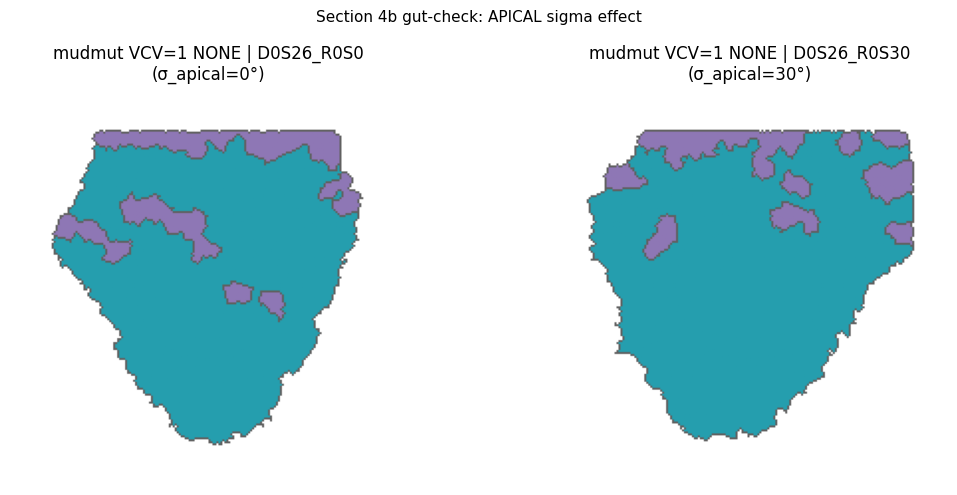

In [27]:
if sec4b_tags:
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, tag in zip(axes, sec4b_tags):
        cond = mm_cond_df.loc[tag, 'condition']
        draw_example_lineage(
            cond, 'vcv1_noreg', ax=ax,
            title=f'mudmut VCV=1 NONE | {tag}\n(σ_apical={mm_cond_df.loc[tag,"rot_stdev"]}°)'
        )
    plt.suptitle('Section 4b gut-check: APICAL sigma effect', fontsize=11)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'sec4b_gutcheck.png', dpi=120, bbox_inches='tight')
    plt.show()

### Section 4c — APICAL mean effect (DIV and APICAL sigma fixed)

Within APICAL sigma=30, compare APICAL mean N(0,30) vs N(11,30) at a fixed DIV
baseline (D0S26 preferred; falls back to D11S26). Isolates the effect of biasing
the apical rotation mean.

Skipped if neither DIV baseline has both APICAL mean conditions accepted.

4c baseline: D0S26
4c tags: ['D0S26_R0S30', 'D0S26_R11S30']


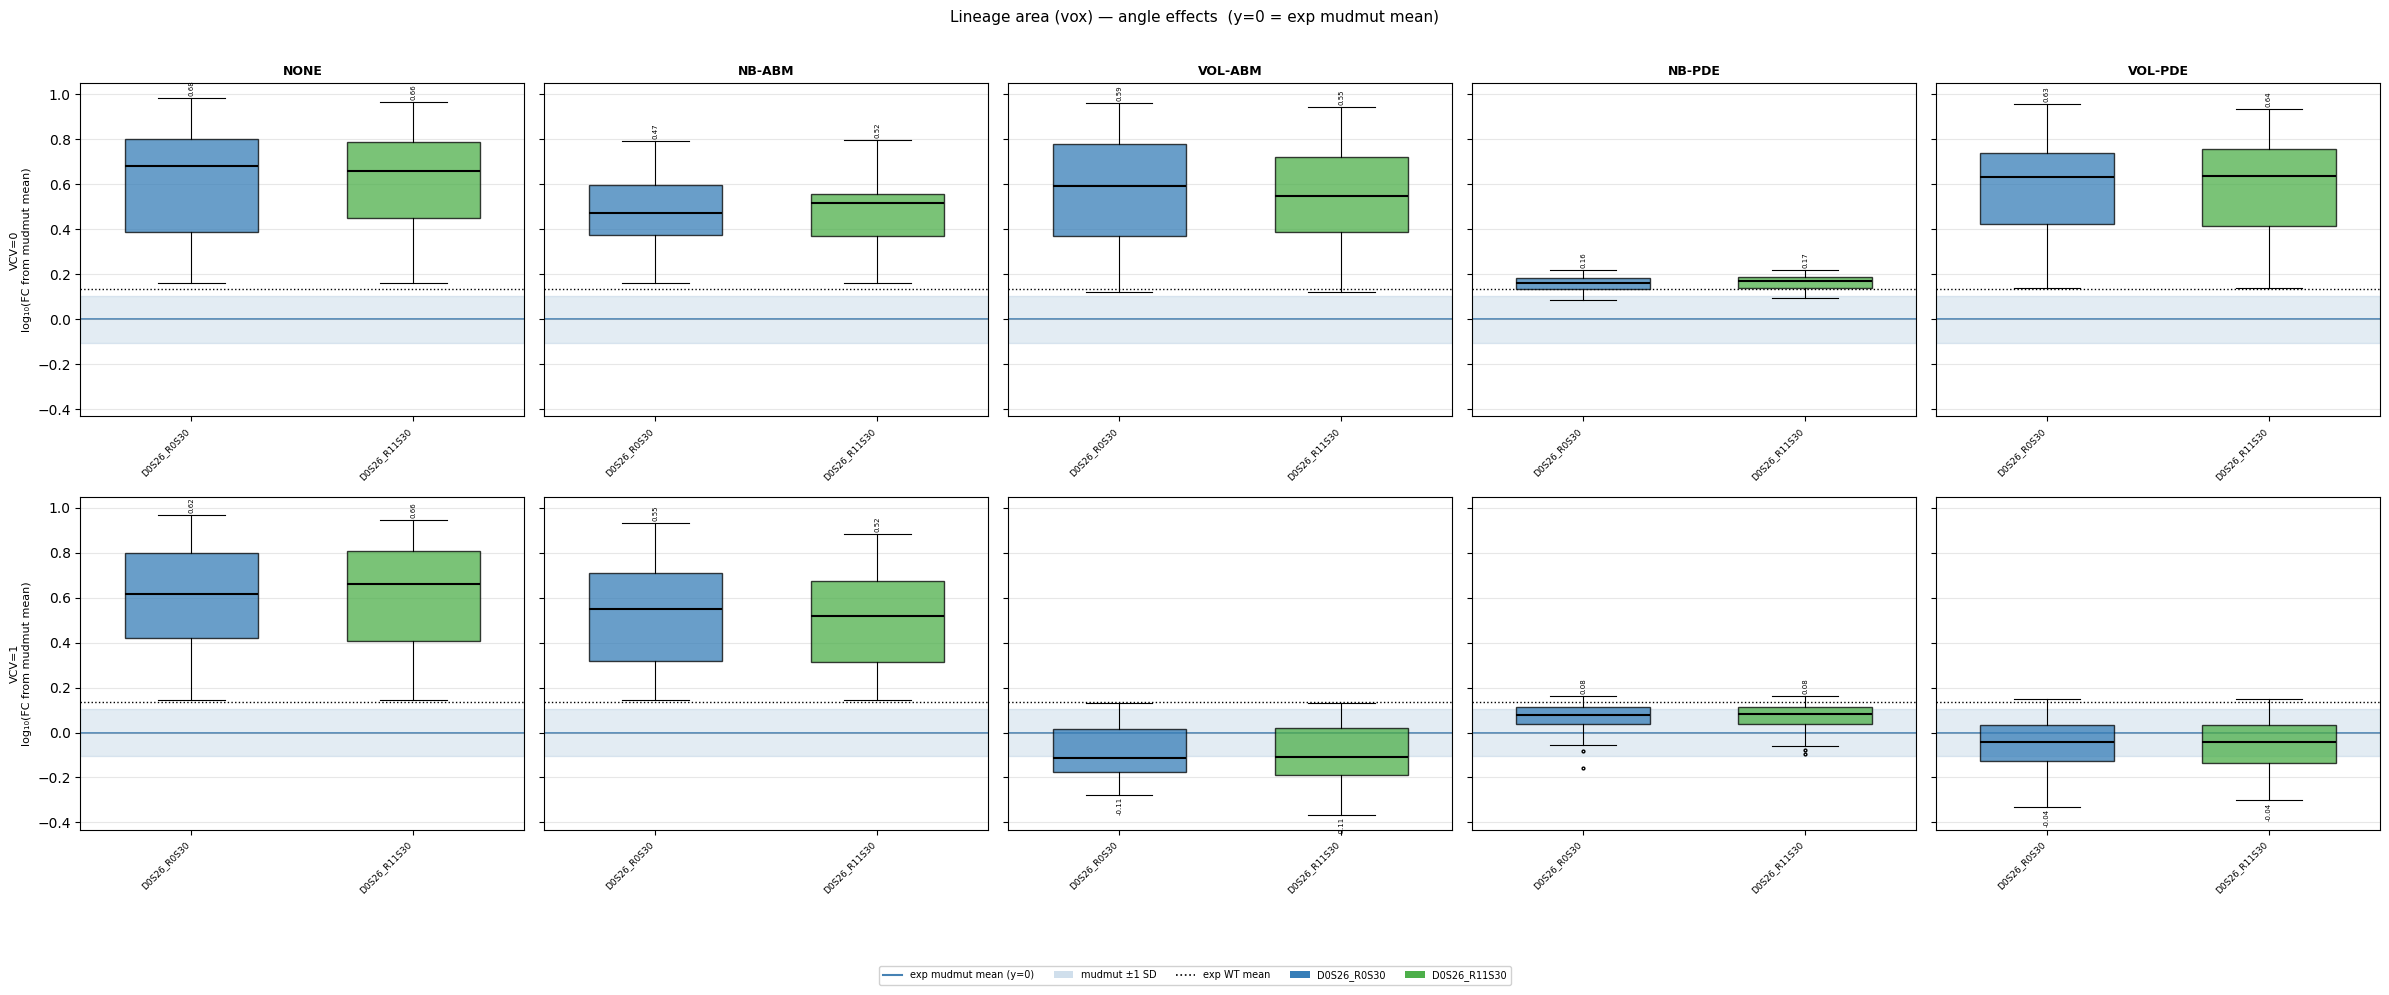

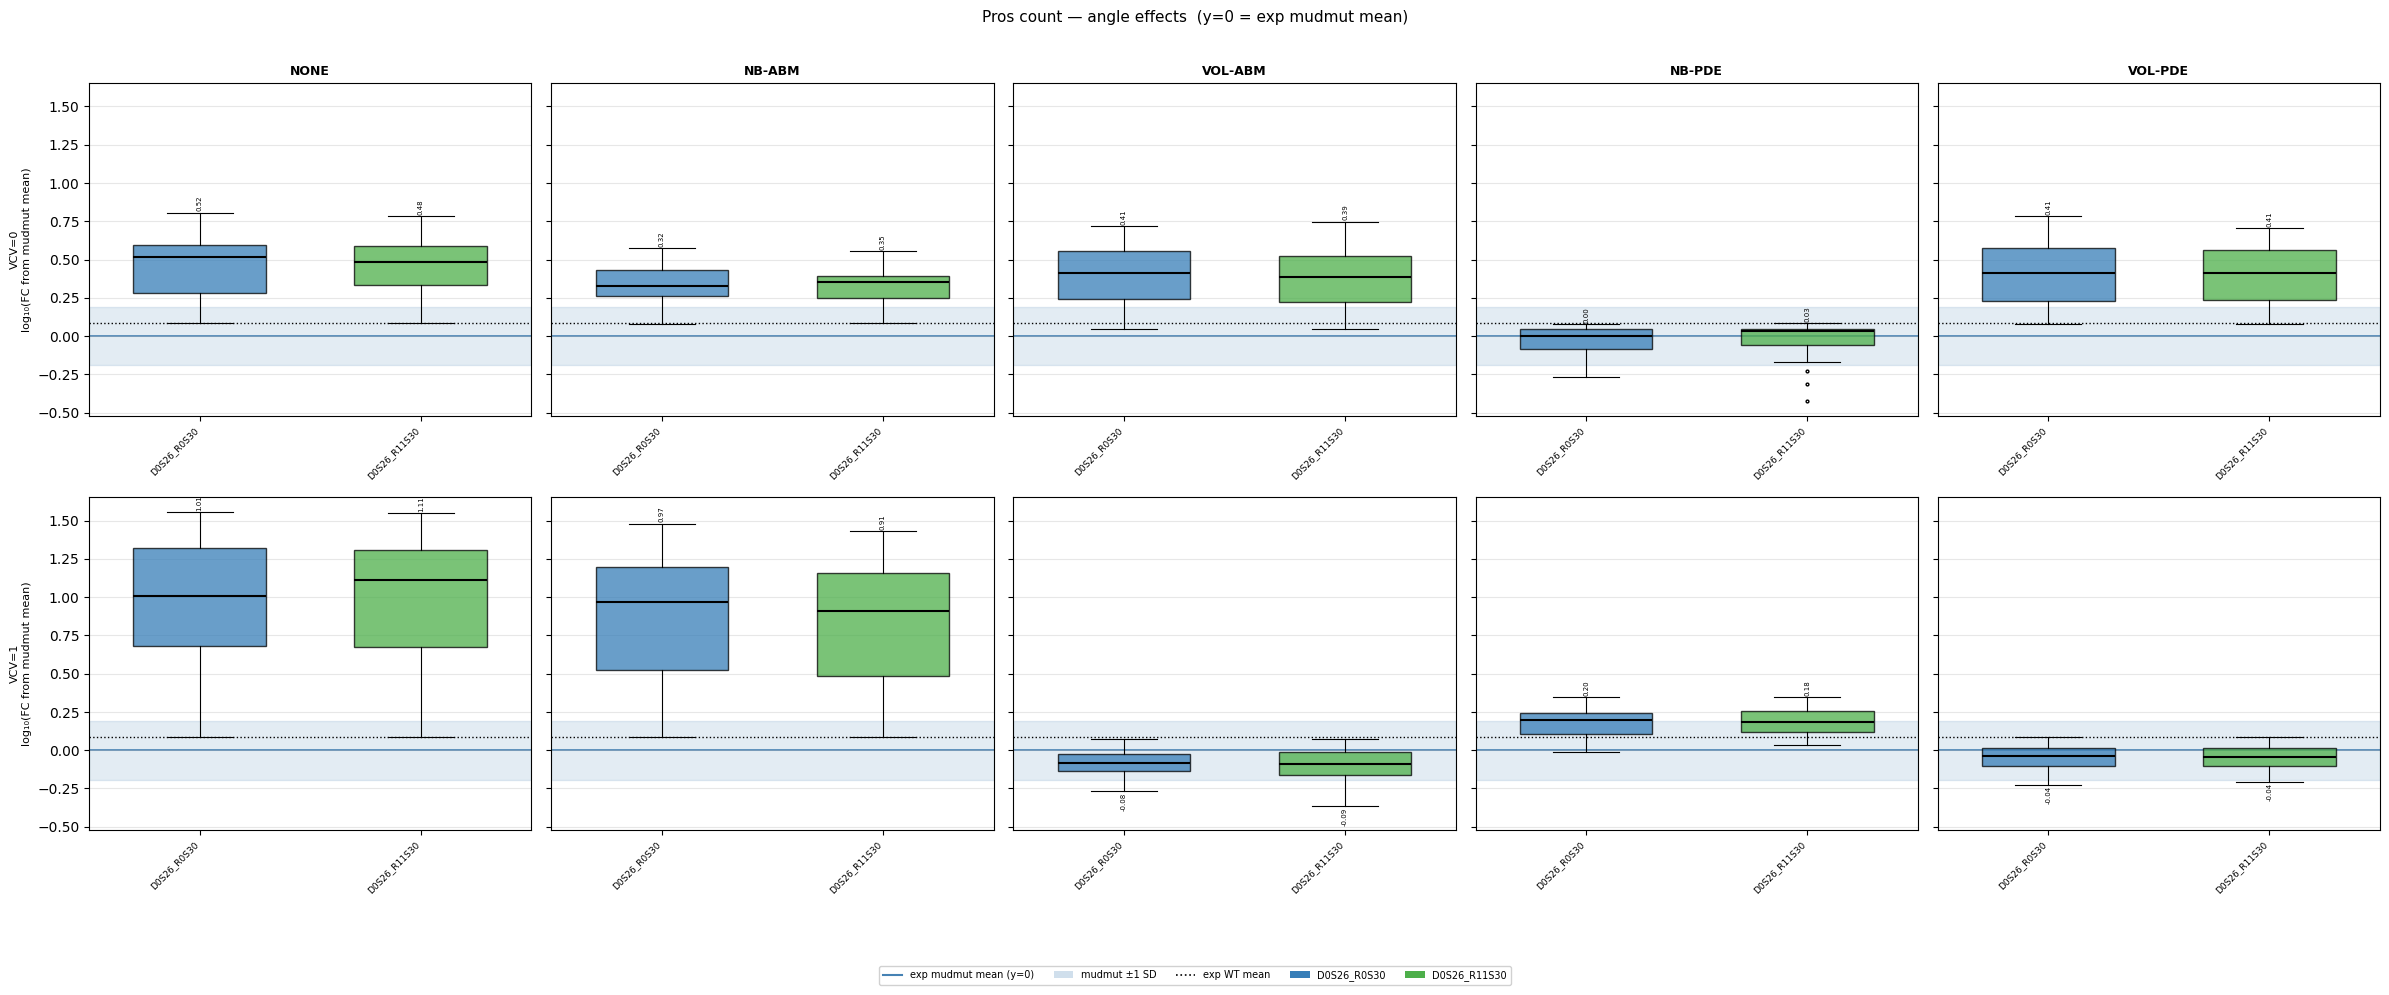

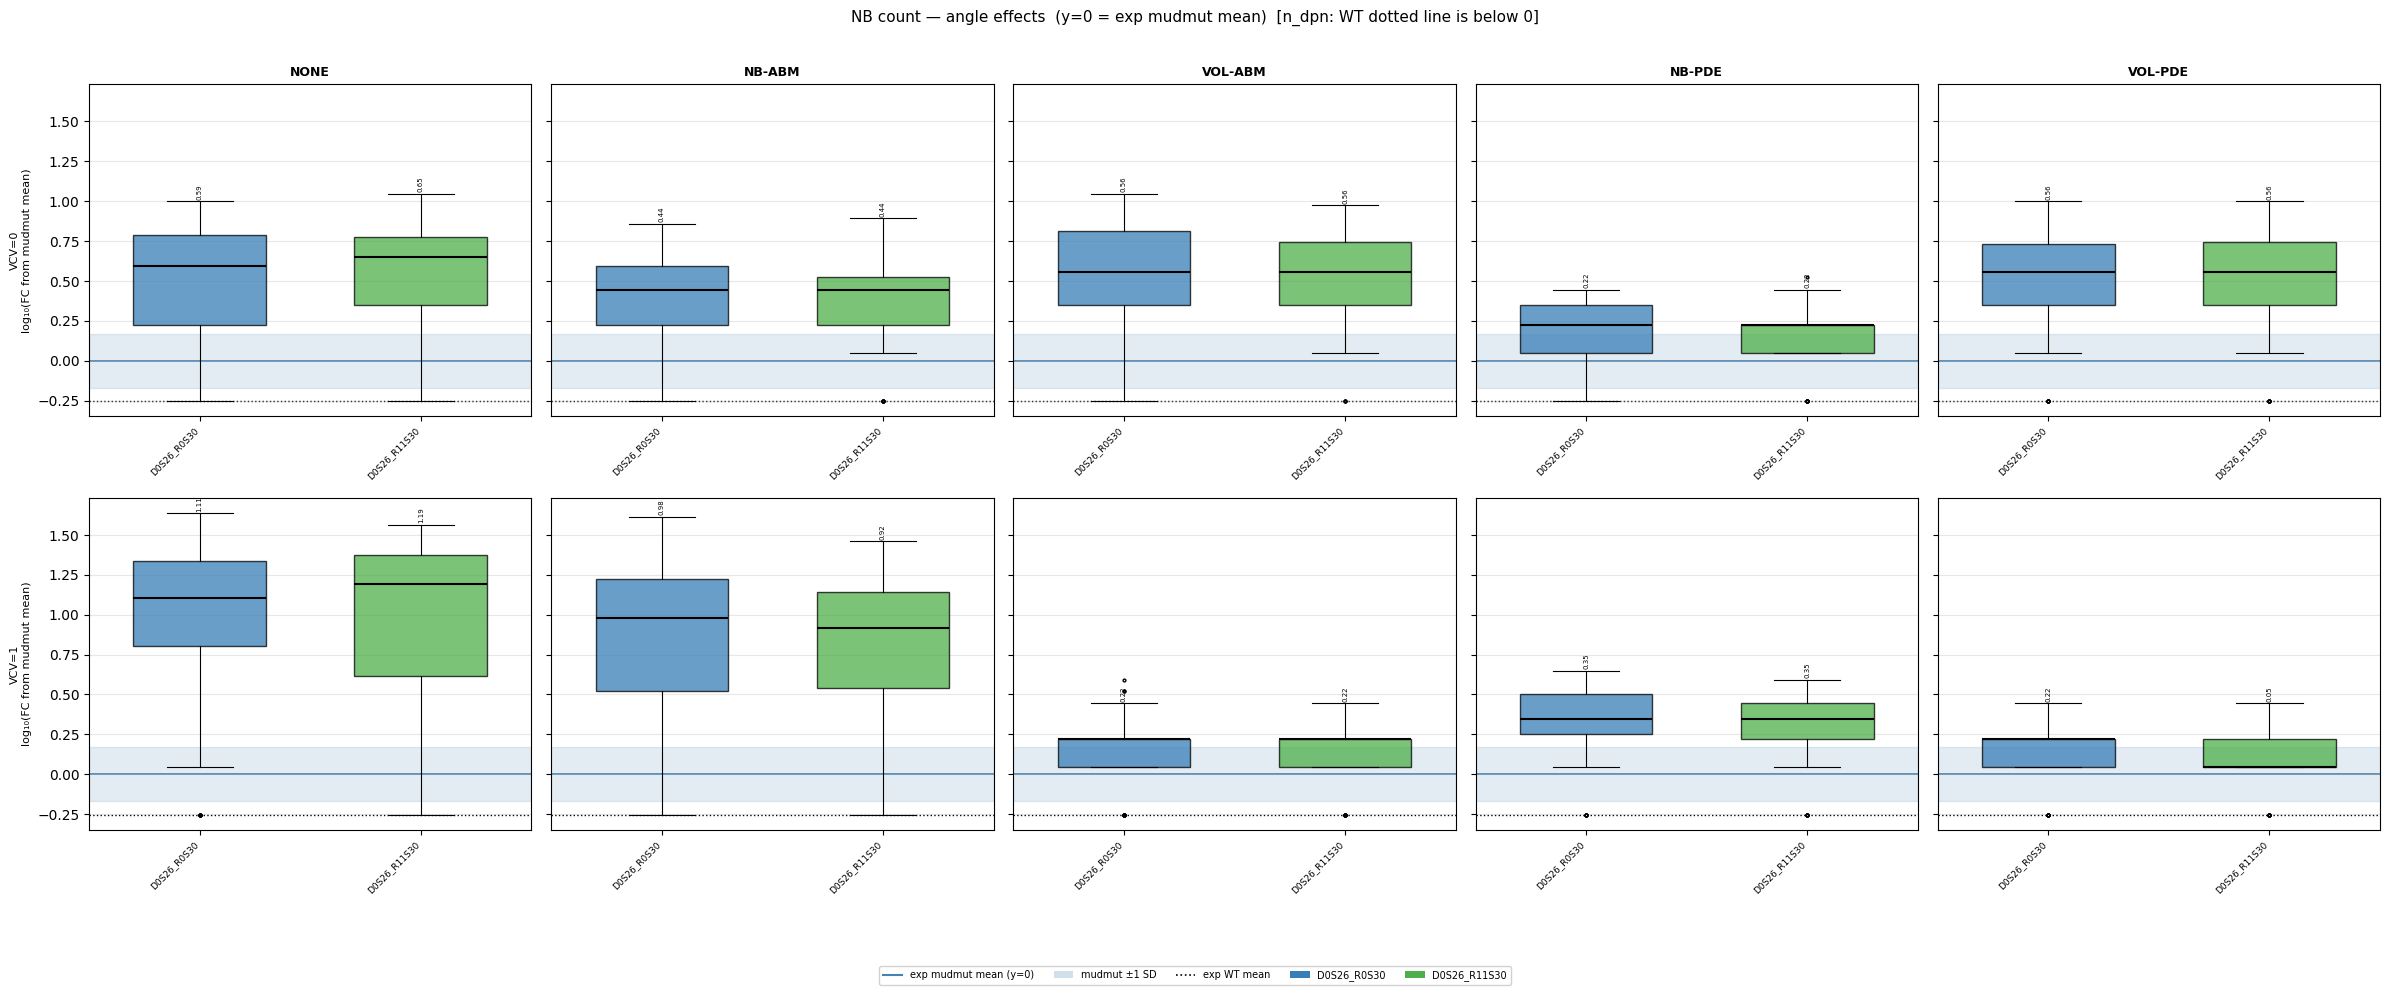

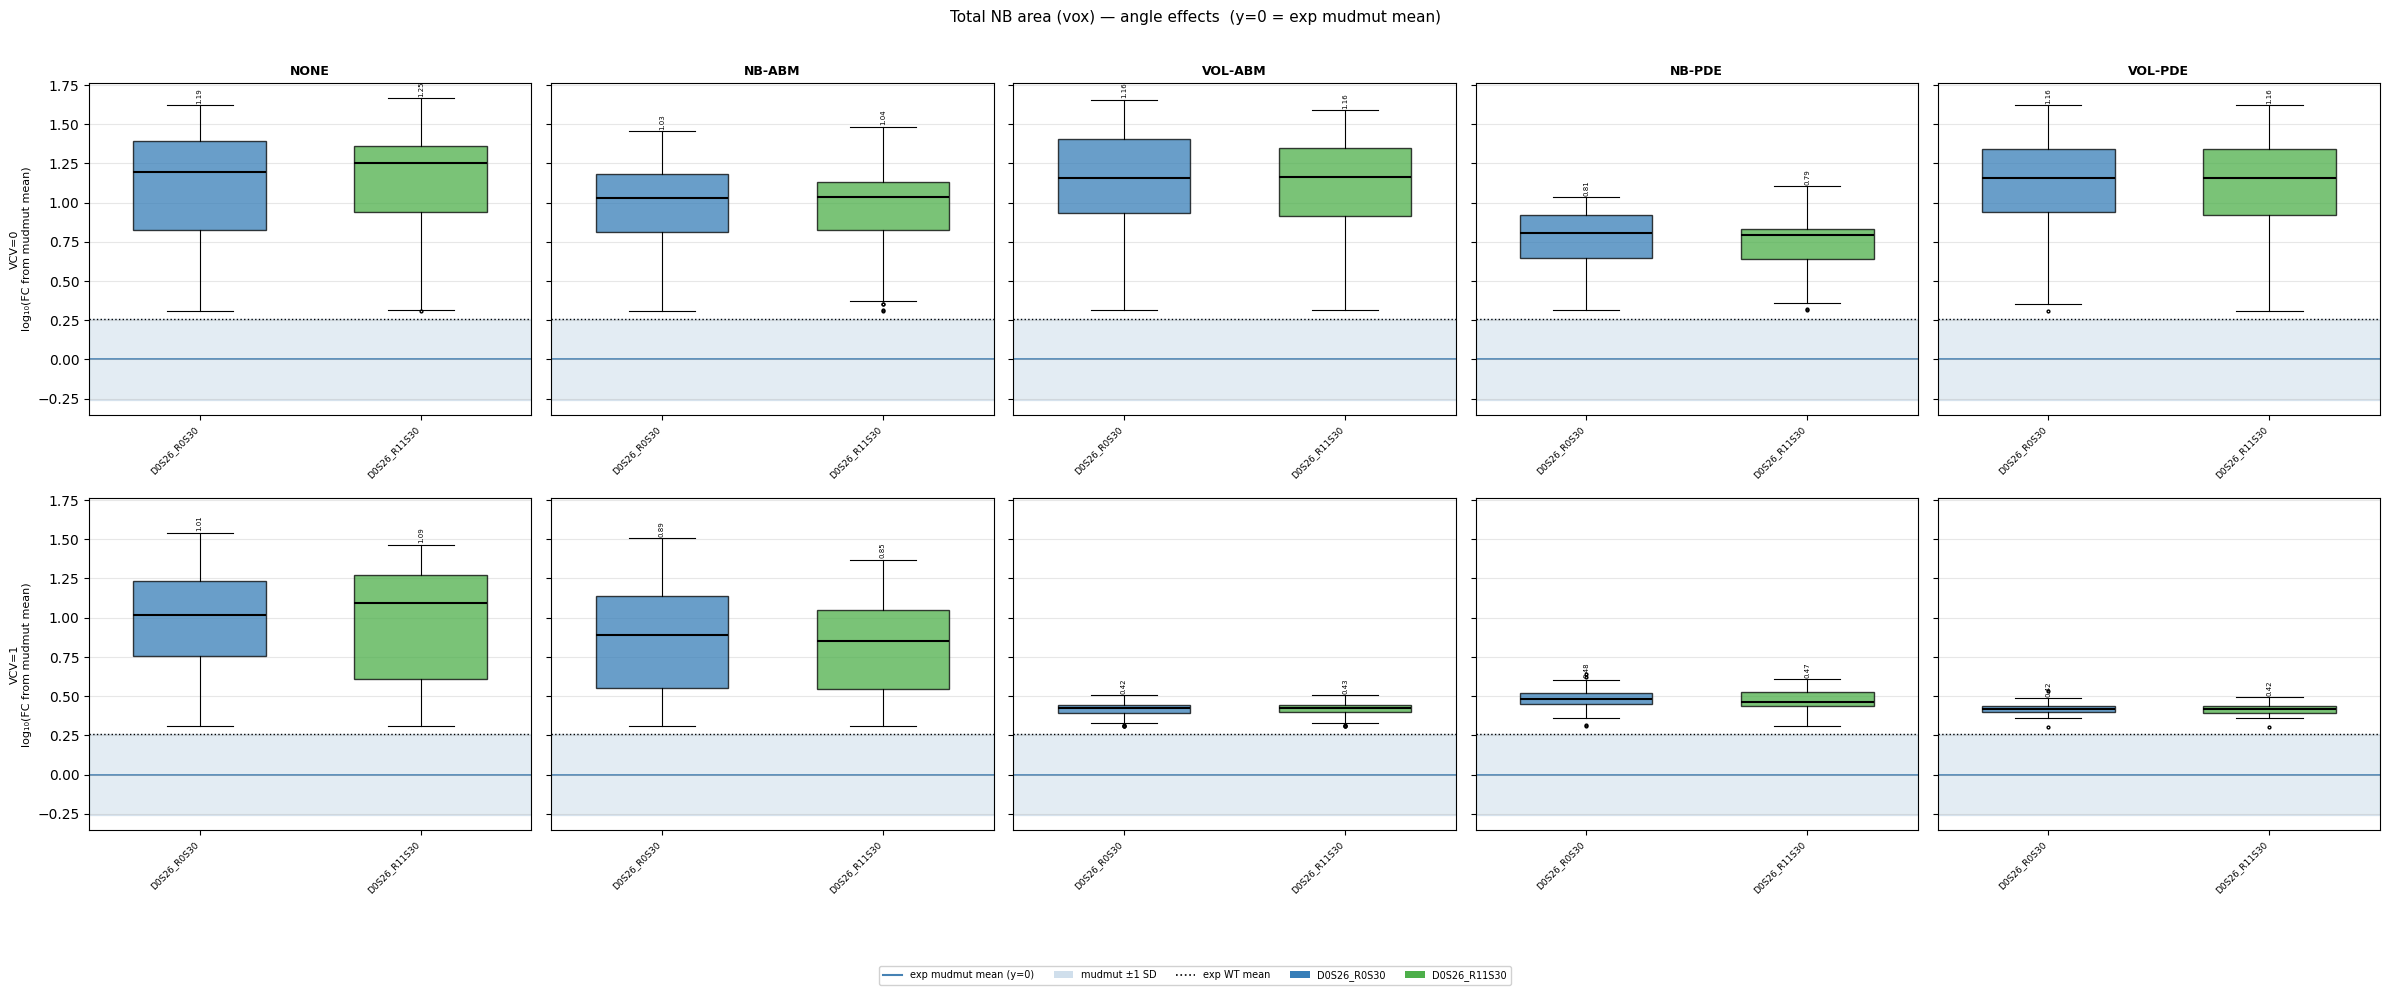

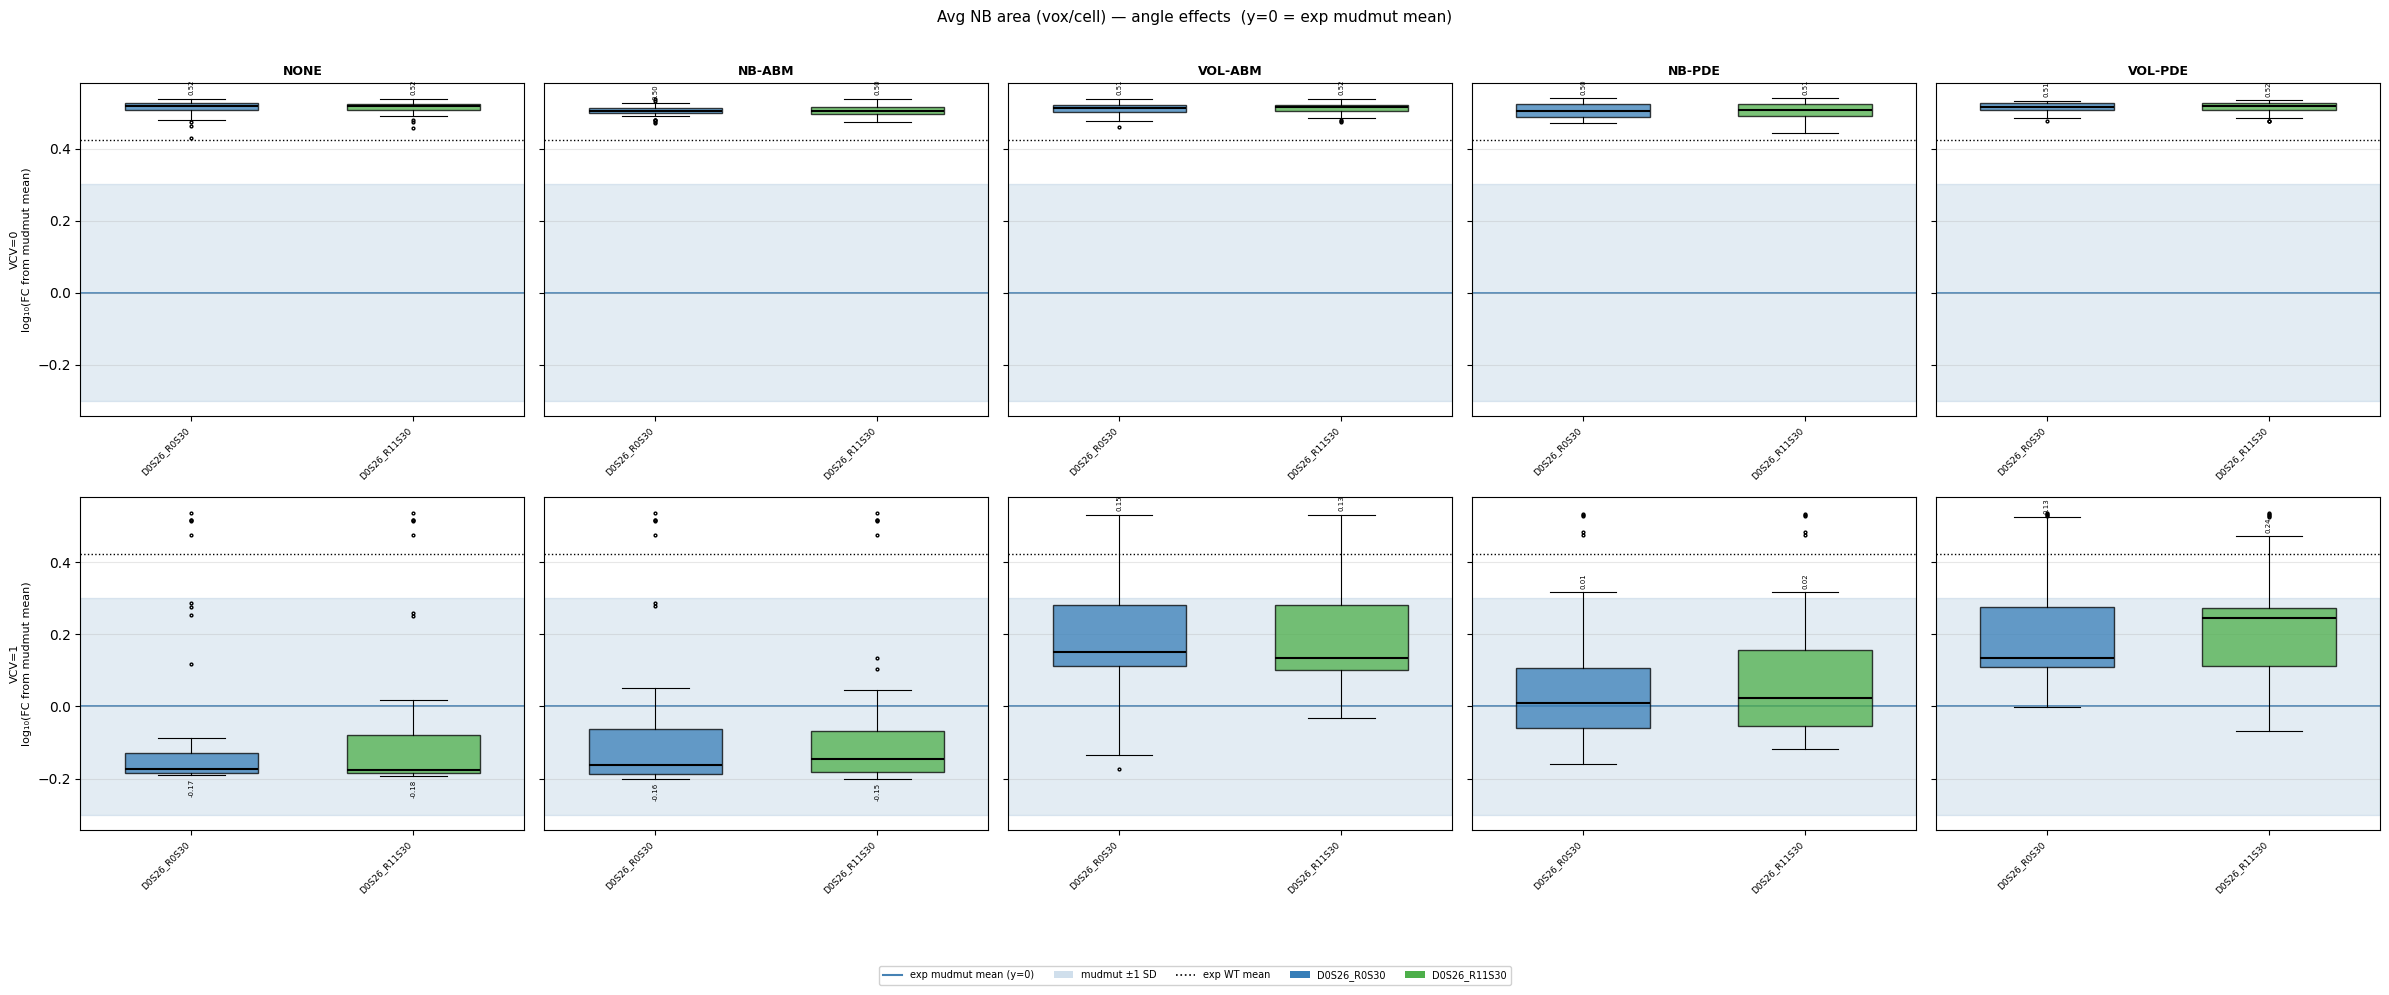

In [28]:
sec4c_tags = None
for div_prefix in ['D0S26', 'D11S26']:
    t0 = f'{div_prefix}_R0S30'
    t11 = f'{div_prefix}_R11S30'
    if t0 in accepted_mm_tags and t11 in accepted_mm_tags:
        sec4c_tags = [t0, t11]
        print(f'4c baseline: {div_prefix}')
        break

if sec4c_tags is None:
    print('Section 4c SKIPPED — no DIV baseline with both APICAL mean conditions accepted.')
else:
    print(f'4c tags: {sec4c_tags}')
    for metric in METRICS:
        fig = mudmut_angle_chart(metric, sec4c_tags)
        fig.savefig(FIGURES_DIR / f'sec4c_{metric}.png', dpi=120, bbox_inches='tight')
        plt.show()

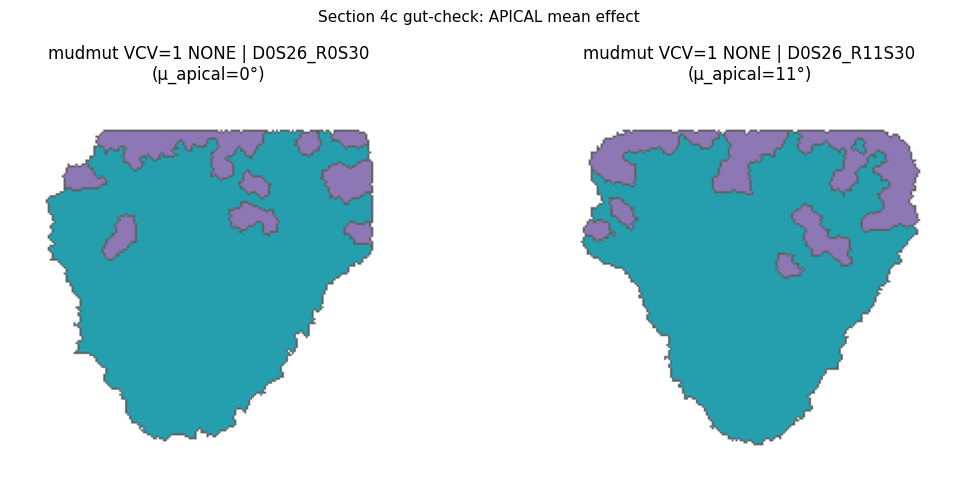

In [29]:
if sec4c_tags:
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, tag in zip(axes, sec4c_tags):
        cond = mm_cond_df.loc[tag, 'condition']
        draw_example_lineage(
            cond, 'vcv1_noreg', ax=ax,
            title=f'mudmut VCV=1 NONE | {tag}\n(μ_apical={mm_cond_df.loc[tag,"rot_mean"]}°)'
        )
    plt.suptitle('Section 4c gut-check: APICAL mean effect', fontsize=11)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'sec4c_gutcheck.png', dpi=120, bbox_inches='tight')
    plt.show()

### Section 4d — Full 2×3 grid (all accepted conditions)

All accepted mudmut conditions side by side in the natural 2×3 order:
D0S26_R0S0, D0S26_R0S30, D0S26_R11S30, D11S26_R0S0, D11S26_R0S30, D11S26_R11S30.
Gives the complete picture after the component effects in 4a–4c.

4d accepted tags (6): ['D0S26_R0S0', 'D0S26_R0S30', 'D0S26_R11S30', 'D11S26_R0S0', 'D11S26_R0S30', 'D11S26_R11S30']


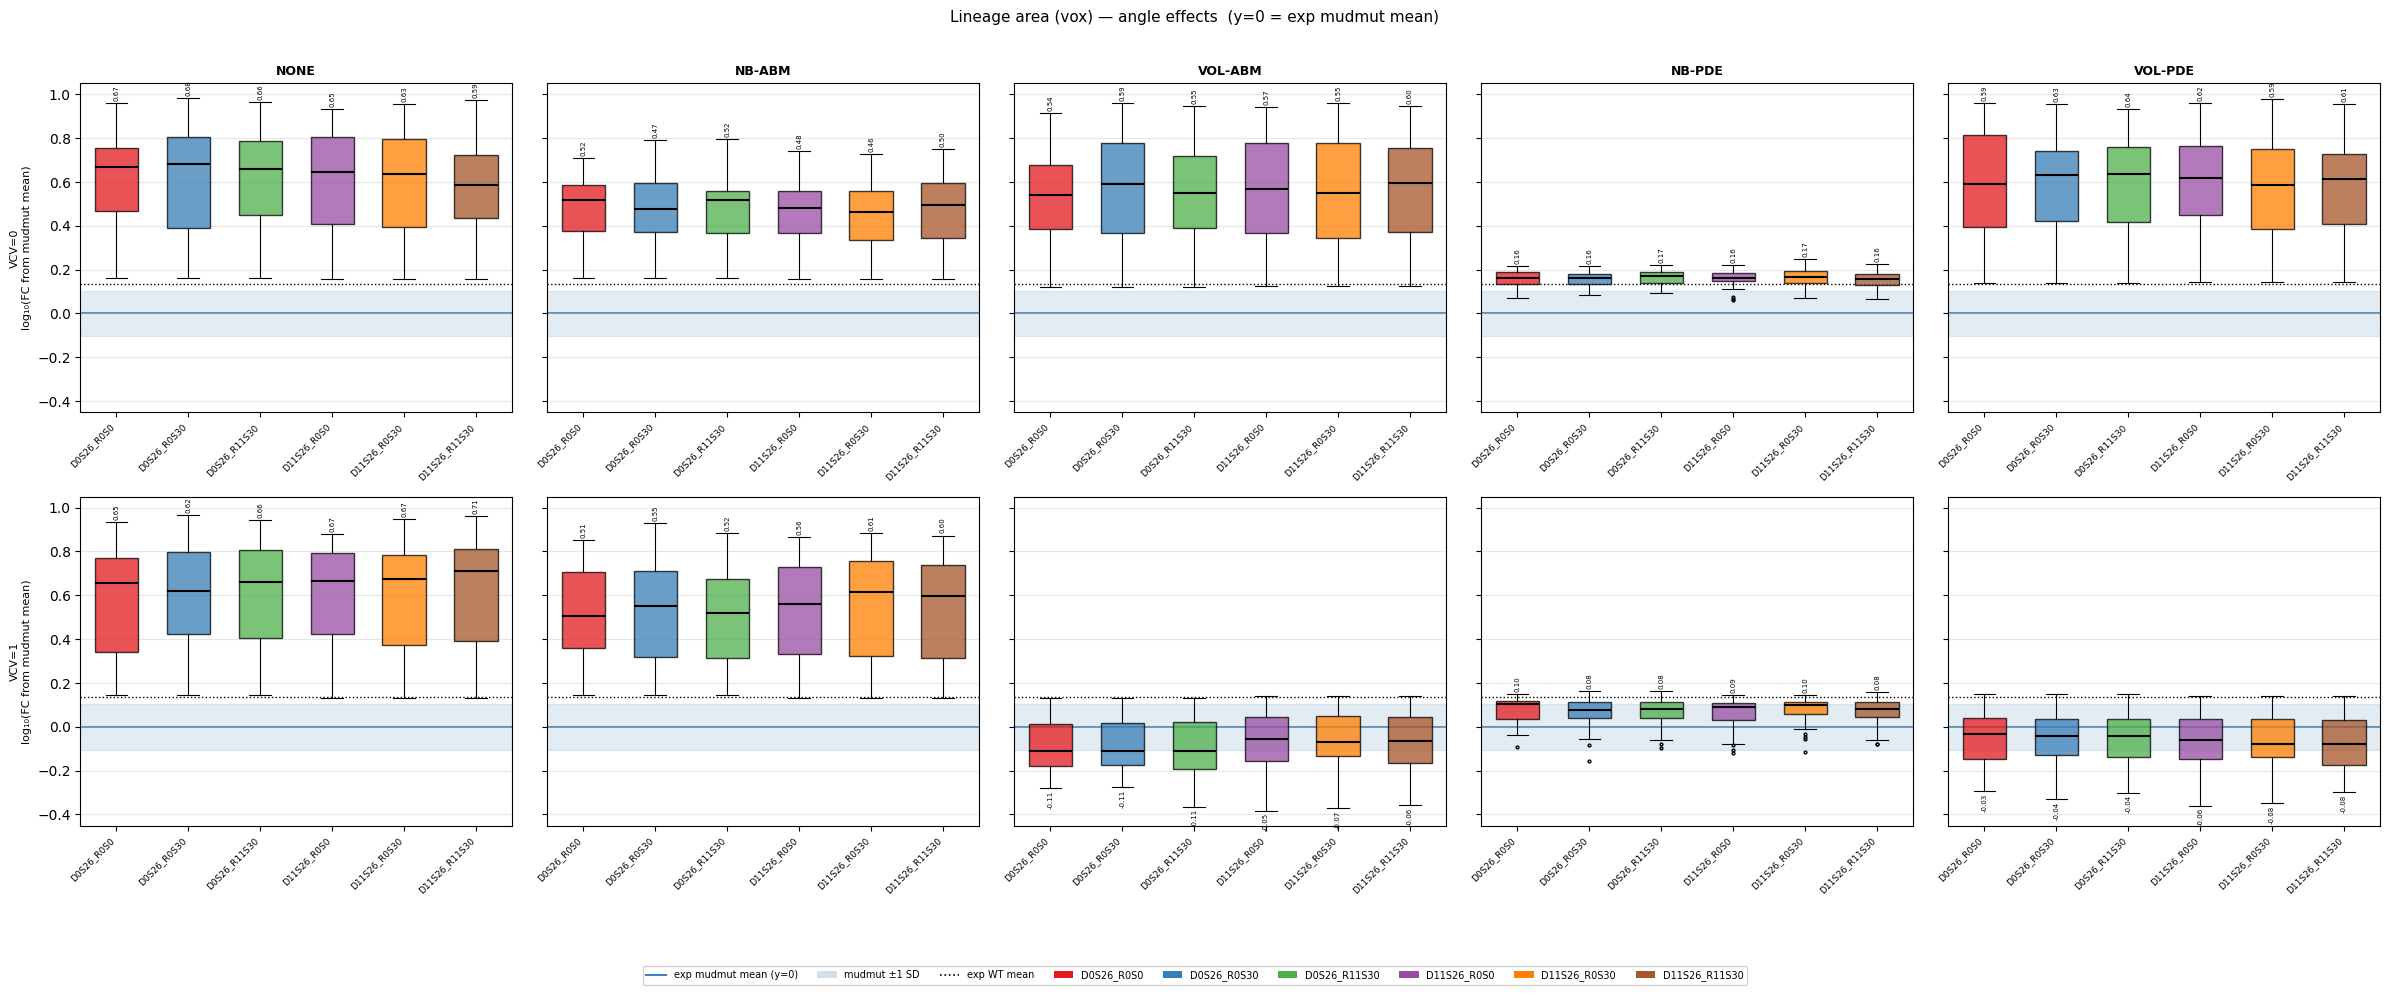

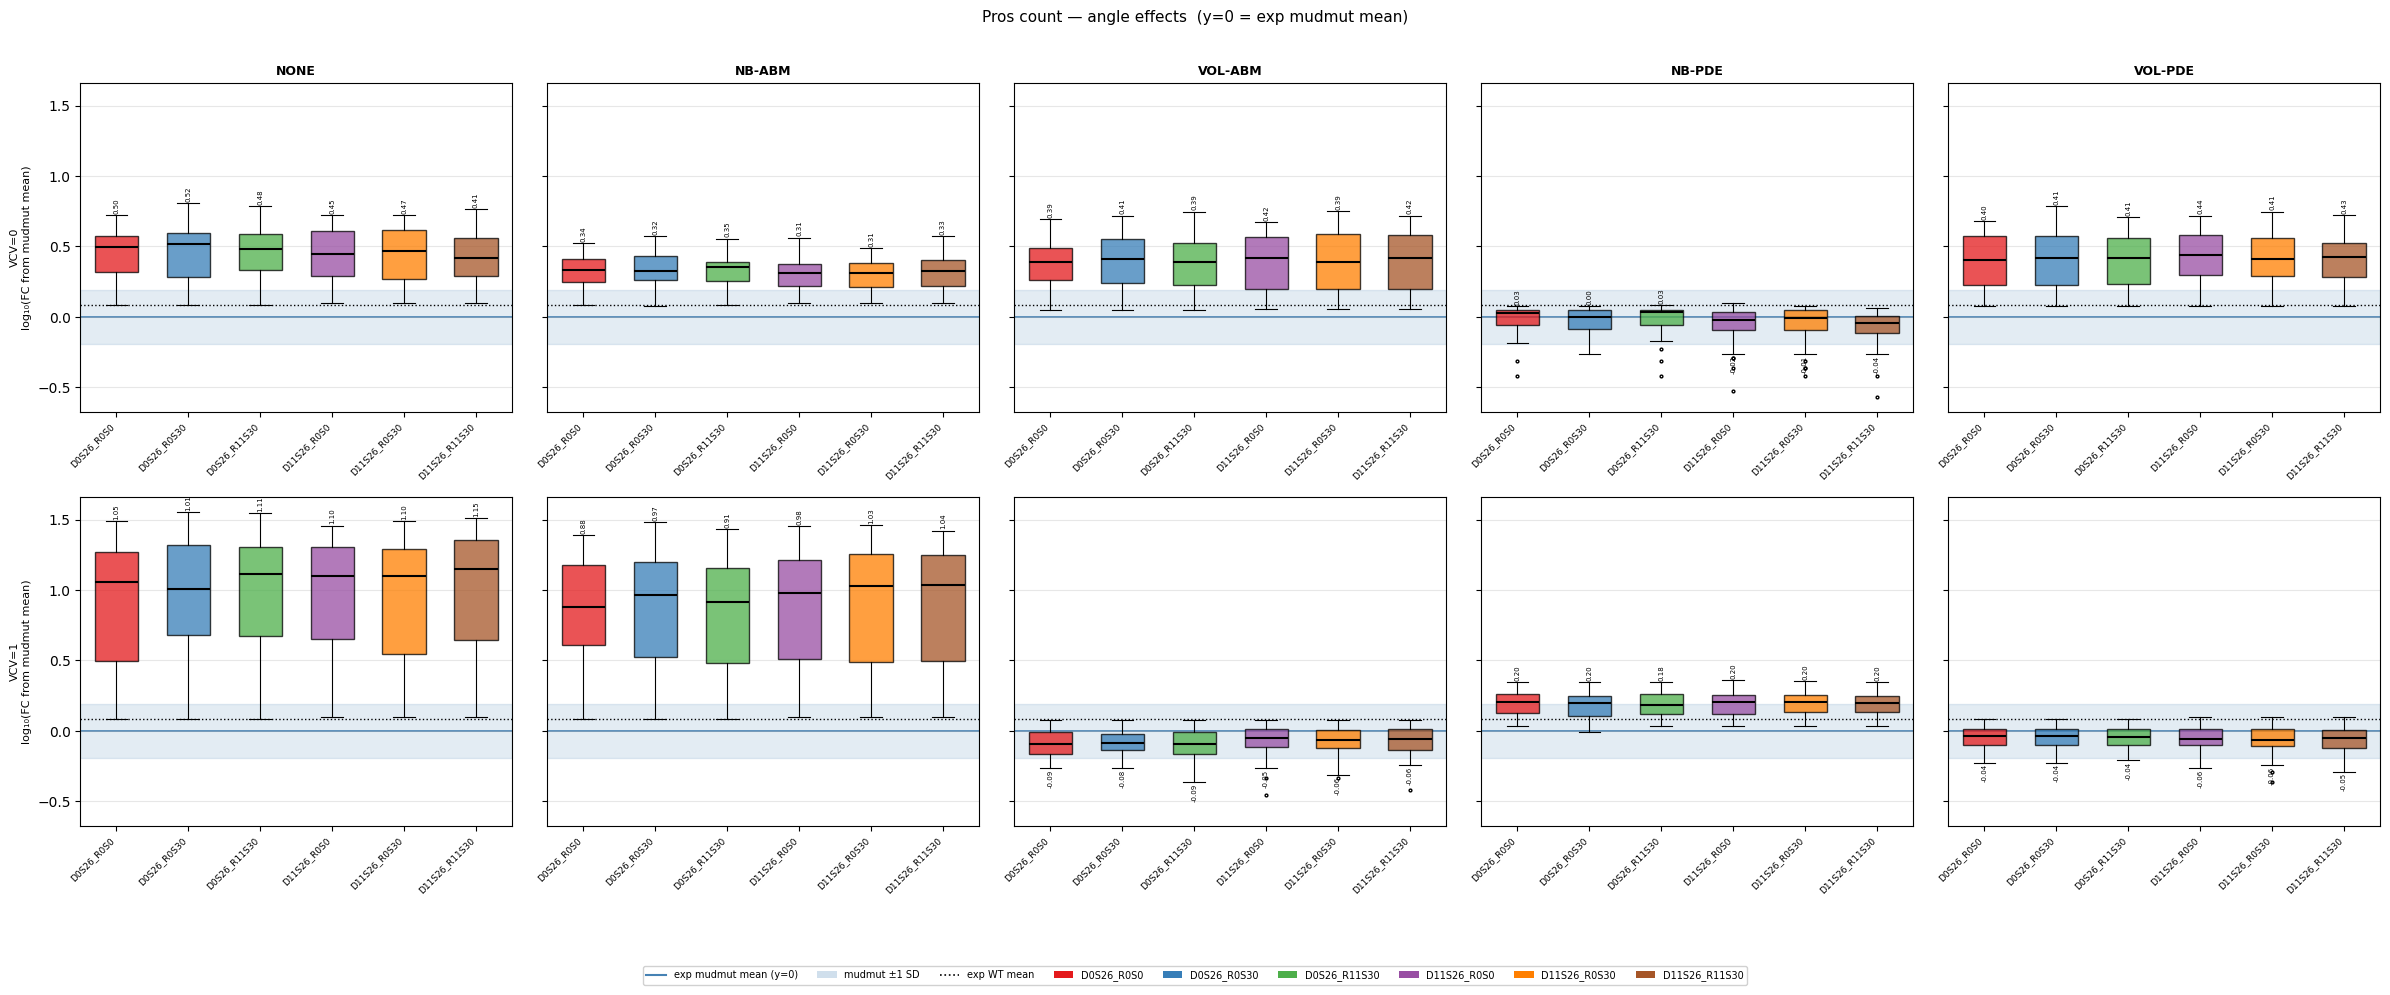

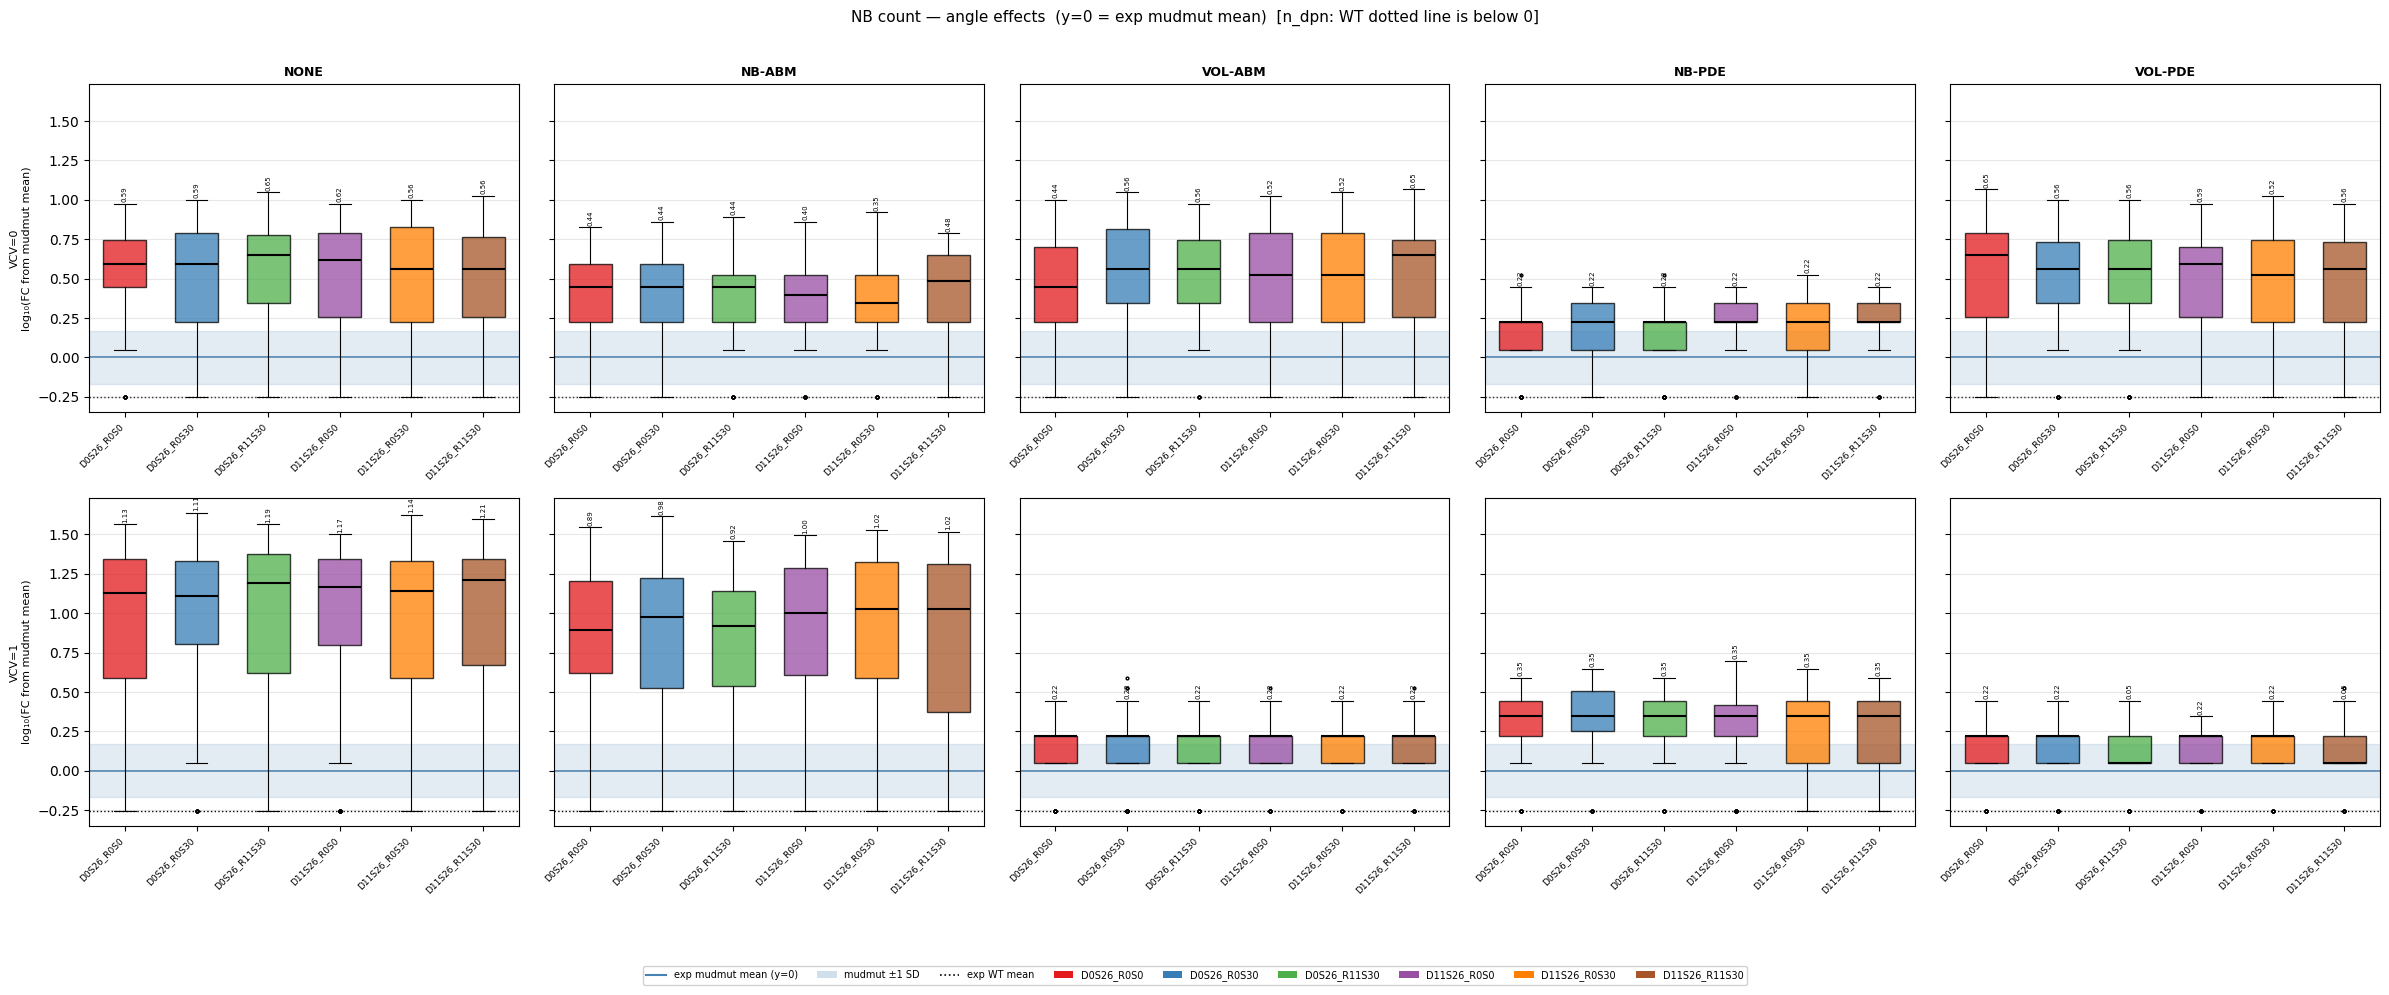

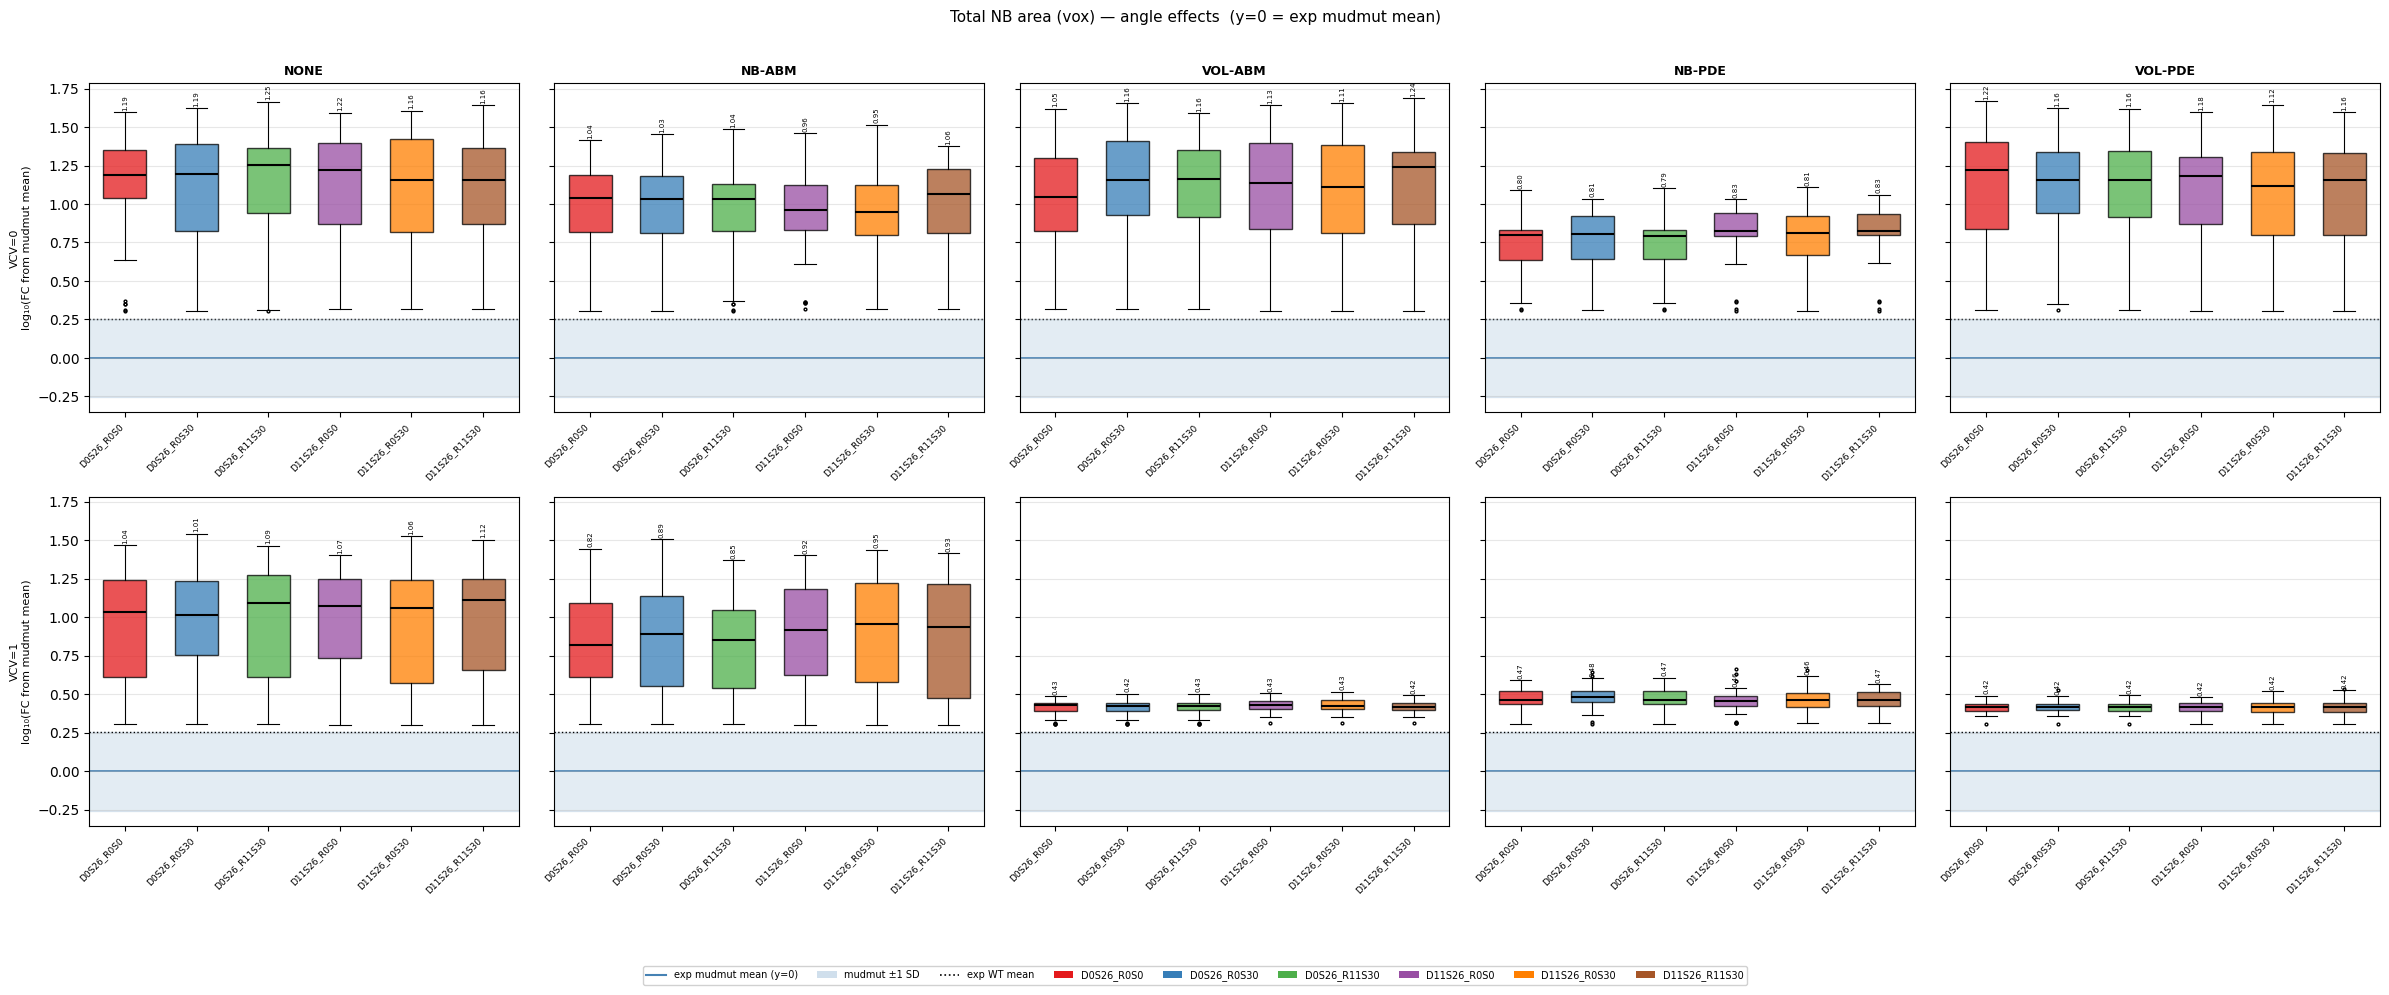

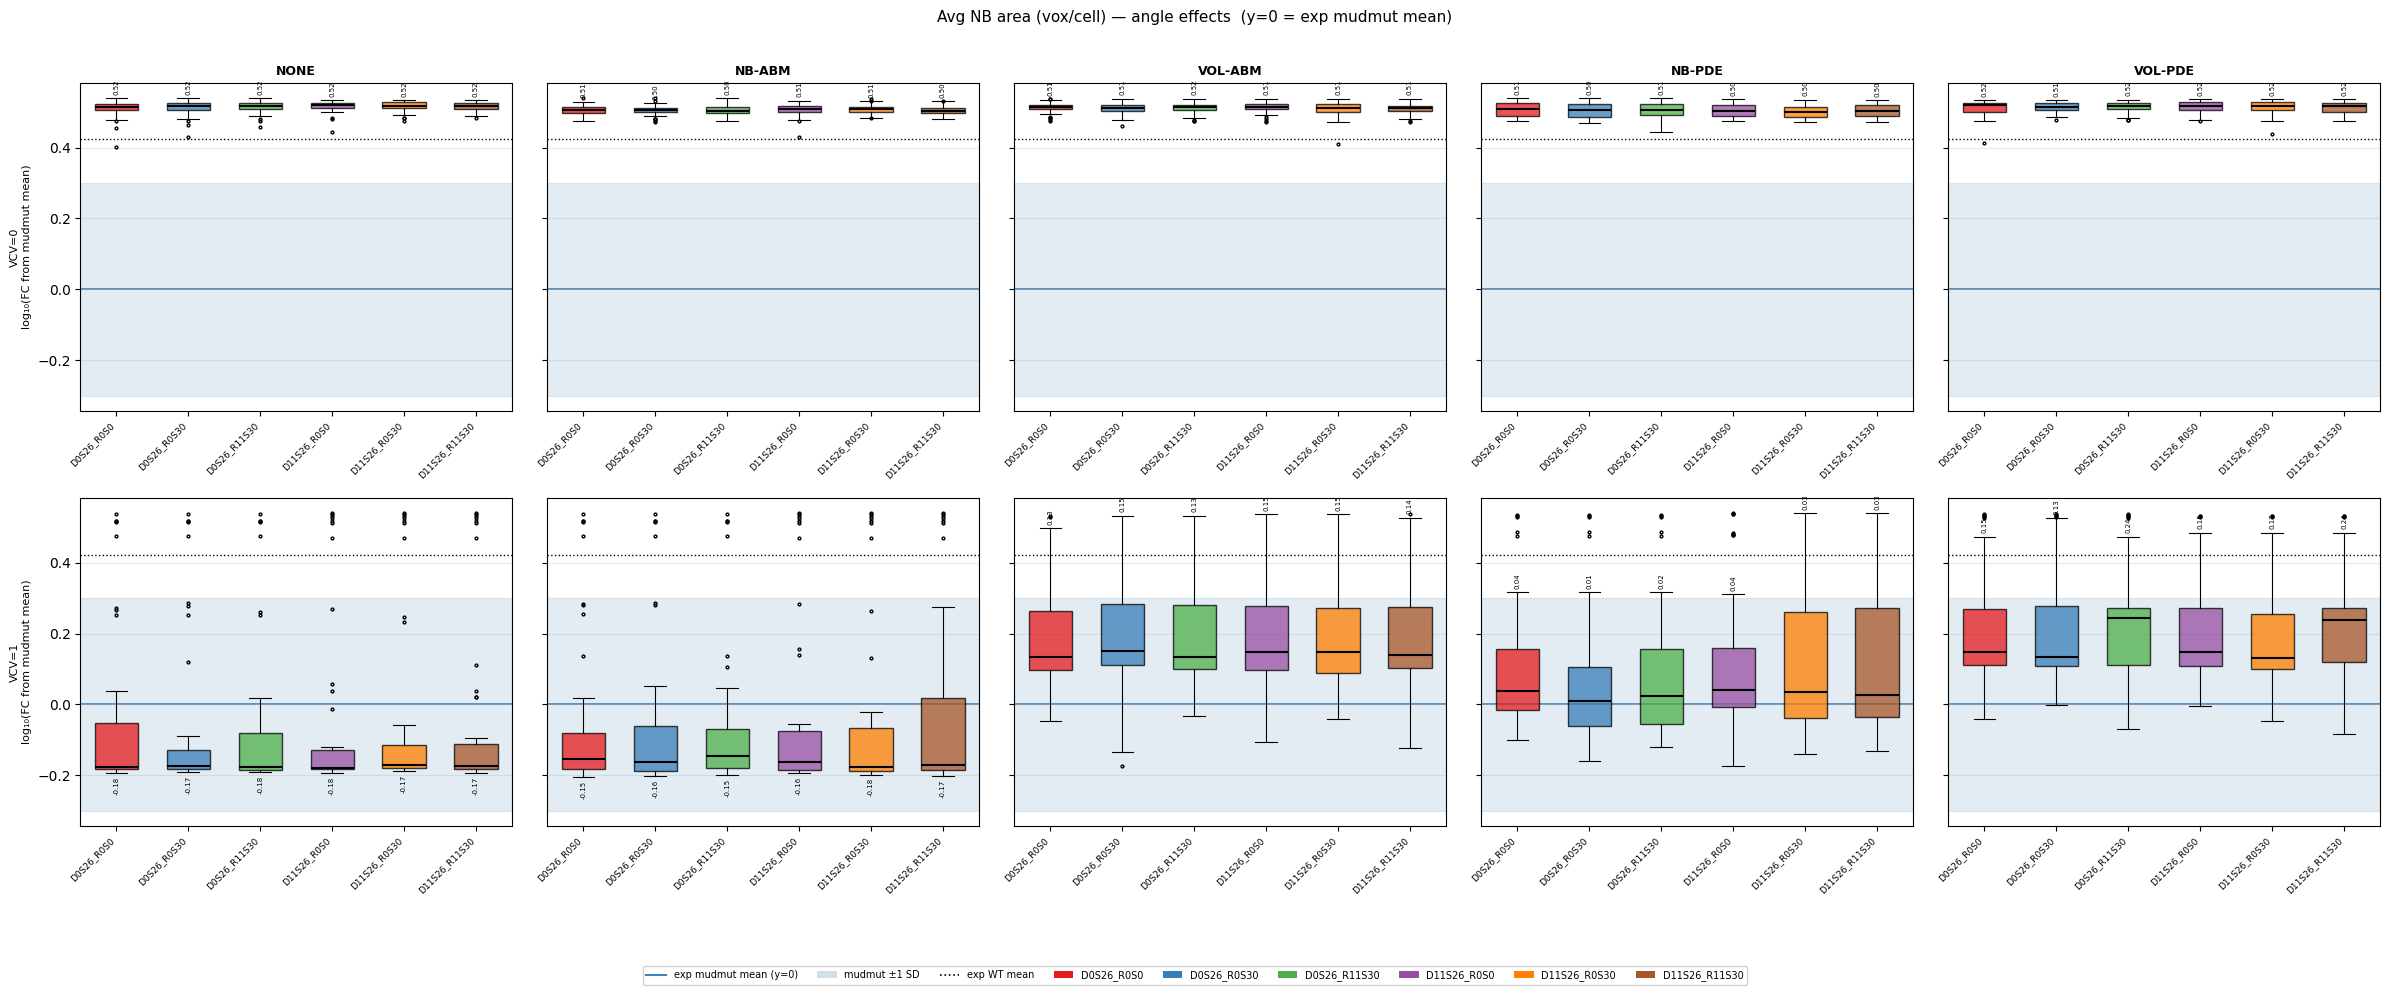

In [30]:
grid_order = [
    'D0S26_R0S0', 'D0S26_R0S30', 'D0S26_R11S30',
    'D11S26_R0S0', 'D11S26_R0S30', 'D11S26_R11S30',
]
sec4d_tags = [t for t in grid_order if t in accepted_mm_tags]

print(f'4d accepted tags ({len(sec4d_tags)}): {sec4d_tags}')
if not sec4d_tags:
    print('Section 4d SKIPPED — no conditions remain.')
else:
    for metric in METRICS:
        fig = mudmut_angle_chart(metric, sec4d_tags)
        fig.savefig(FIGURES_DIR / f'sec4d_{metric}.png', dpi=120, bbox_inches='tight')
        plt.show()

### Section 4 — Interpretation

*Record observations here after running the cells above.*

Key questions to address:
- **4a:** Does shifting DIV mean from 0 to 11 improve or worsen alignment with
  the mudmut target? Is the effect consistent across regulatory dynamics?
- **4b:** Does adding APICAL sigma (0→30) change outcome relative to APICAL=N(0,0)?
  If so, does it help or hurt?
- **4c:** Does biasing the APICAL mean from 0 to 11 further shift the outcomes?
  Does it interact with APICAL sigma?
- **4d:** Taken together, which corner(s) of the 2×3 grid come closest to the
  mudmut target across regulatory dynamics?

---
## Section 5 — Synthesis

**Goal:** rank all accepted (VCV, regulatory dynamic, angle condition) combinations
across the top 3 metrics by the fraction of runs falling within the experimental
mudmut ±1 SD band.

The 2×3 design of mudmut conditions means the rank table naturally reveals whether
DIV-mean or APICAL shifts are associated with higher rank — noted in the
interpretation cell below but not formally computed.

In [31]:
records = []
for metric in TOP3:
    wt_mean             = wt_ref[metric][0]
    mm_mean_val, mm_std = mm_ref[metric]
    mm_lfc              = np.log10(mm_mean_val / wt_mean)
    mm_half             = 0.05 if mm_std == 0 else np.log10(1 + mm_std / mm_mean_val)
    mm_lo, mm_hi        = mm_lfc - mm_half, mm_lfc + mm_half

    for vcv in [0, 1]:
        for reg_dyn in REG_DYN_ORDER:
            for tag in accepted_mm_tags:
                cond = mm_cond_df.loc[tag, 'condition']
                runs = sim_mm[
                    (sim_mm['critical_volume_mode'] == vcv) &
                    (sim_mm['regulatory_dynamic']   == reg_dyn) &
                    (sim_mm['condition']            == cond)
                ][metric]
                if runs.empty:
                    continue
                lfc          = fold_change_log(runs, wt_mean)
                frac_within  = float(np.mean((lfc >= mm_lo) & (lfc <= mm_hi)))
                records.append({
                    'metric':              metric,
                    'vcv':                 vcv,
                    'regulatory_dynamic':  reg_dyn,
                    'condition':           tag,
                    'frac_within_mm_band': round(frac_within, 3),
                    'mean_log_fc_from_mm': round(float(np.mean(lfc)) - mm_lfc, 3),
                })

proximity_df = pd.DataFrame(records)
proximity_df['rank'] = proximity_df.groupby('metric')['frac_within_mm_band'].rank(
    ascending=False, method='min'
).astype(int)

print('=== Per-metric top 10 ===')
for metric in TOP3:
    print(f'\n── {METRIC_LABELS[metric]} ──')
    top10 = (
        proximity_df[proximity_df['metric'] == metric]
        .sort_values(['frac_within_mm_band', 'mean_log_fc_from_mm'],
                     ascending=[False, True])
        .head(10)
        [['rank', 'vcv', 'regulatory_dynamic', 'condition',
          'frac_within_mm_band', 'mean_log_fc_from_mm']]
    )
    print(top10.to_string(index=False))

combo_rank = (
    proximity_df.groupby(['vcv', 'regulatory_dynamic', 'condition'])['rank']
    .sum()
    .reset_index()
    .rename(columns={'rank': 'combined_rank'})
    .sort_values('combined_rank')
    .reset_index(drop=True)
)
combo_rank.index += 1
combo_rank.index.name = 'overall_rank'

print('\n=== Combined rank (sum of per-metric ranks across top-3 metrics) ===')
print(combo_rank.head(20).to_string())

=== Per-metric top 10 ===

── Lineage area (vox) ──
 rank  vcv regulatory_dynamic     condition  frac_within_mm_band  mean_log_fc_from_mm
    1    1             NB-PDE   D11S26_R0S0                 0.66                0.065
    2    1             NB-PDE   D0S26_R0S30                 0.64                0.068
    3    1             NB-PDE D11S26_R11S30                 0.62                0.068
    4    1             NB-PDE  D0S26_R11S30                 0.60                0.066
    5    1            VOL-PDE    D0S26_R0S0                 0.54               -0.048
    6    1            VOL-ABM   D11S26_R0S0                 0.52               -0.065
    6    1            VOL-PDE  D0S26_R11S30                 0.52               -0.048
    6    1             NB-PDE  D11S26_R0S30                 0.52                0.078
    9    1            VOL-ABM  D11S26_R0S30                 0.50               -0.065
    9    1            VOL-PDE   D0S26_R0S30                 0.50               -0.049

─

### Section 5 — Interpretation

*Record conclusions here after reviewing the synthesis tables above.*

Key questions to address:
- Which regulatory mechanisms show the most promise across all three primary metrics?
- Is VCV=1 necessary to approach the mudmut target, or do VCV=0 conditions also rank well?
- Does any corner of the 2×3 grid (DIV mean, APICAL sigma, APICAL mean) consistently
  improve alignment?
- Which single (VCV, regulatory dynamic, angle condition) combination best reproduces
  the experimental mudmut phenotype overall?
- Compare top combinations here to top combinations from the old sweep —
  what does the calibrated σ=26 buy relative to σ=30/43?